# ANSC 4040 Mini Project
## Trajectory-Aware Candidate-Restricted KNN — 16 GB RAM

This notebook is the next optimization step after the previous Candidate-Restricted KNN model.

The previous full validation result was approximately:

- Accuracy: **34.22%**
- Balanced accuracy: **34.28%**
- Weighted F1: **32.33%**
- Prediction coverage: **100%**

That is a large improvement over Global KNN (~4%), which indicates that **candidate restriction works**. The remaining problem is no longer mainly the global search space; it is how plausible candidate cows are ranked.

This version therefore keeps the same chronological train/validation/test strategy and upgrades the local ranking system.

### Main upgrades

1. **Lactation-start candidate generation** remains the first filter.
2. A **structural score** uses lactation-start compatibility more strongly.
3. A **recency score** favors animals observed more recently when appropriate.
4. A **local row-level KNN score** compares nearby historical records.
5. A **lactation prototype score** compares the query with a robust median production profile at a similar DaysInMilk.
6. A **whole-cow phenotype score** compares the query with the animal's long-term production profile.
7. Extra engineered production features are added:
   - Yield per minute
   - First-2-minute yield fraction
   - Flow-shape ratio
8. Hyperparameter optimization is split into:
   - **Stage 1:** structural/candidate optimization
   - **Stage 2:** trajectory/KNN score optimization
9. Balanced accuracy is calculated only over classes that actually occur in `y_true`, avoiding the previous warning about predicted classes not present in the evaluation sample.

> The code is designed to improve the measured accuracy substantially, but it does not fabricate or guarantee a 60% result. The validation/test results printed by the notebook are the values that should be reported.

In [18]:
# ============================================================
# 1. Imports and configuration
# ============================================================

from pathlib import Path
import gc
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
)
from sklearn.model_selection import ParameterSampler
from sklearn.preprocessing import StandardScaler


RANDOM_STATE = 42

MODEL_DATA_PATH = Path(
    r"/Library/ansci-4040-fall-2026/jl4937_6040-project-1/dataset/Dataset_for_model_buliding_2.csv"
)

PREDICTION_DATA_PATH = Path(
    r"/Library/ansci-4040-fall-2026/jl4937_6040-project-1/dataset/records_missing_AnimalId.csv"
)

# ------------------------------------------------------------
# 16 GB RAM settings
# ------------------------------------------------------------

# Reference-set size used during tuning.
MAX_REFERENCE_ROWS_PER_ANIMAL_LACTATION = 250

# Stage 1: candidate / structural search.
STAGE1_VALIDATION_ROWS = 8_000
STAGE1_RANDOM_ITERATIONS = 30

# Stage 2: hybrid trajectory / KNN search.
STAGE2_VALIDATION_ROWS = 10_000
STAGE2_RANDOM_ITERATIONS = 40

# Candidate diagnostic.
CANDIDATE_DIAGNOSTIC_ROWS = 8_000

# Larger final validation and test evaluation.
# Change to None to evaluate all eligible rows.
FINAL_VALIDATION_MAX_ROWS = 75_000
FINAL_TEST_MAX_ROWS = 75_000

# Production model/reference size.
PRODUCTION_REFERENCE_ROWS_PER_ANIMAL_LACTATION = 300

PREDICTION_BATCH_SIZE = 2_000

RUN_FINAL_PREDICTION = False

TARGET_ACCURACY = 0.60

# 2. Robust data import

This version does not use `usecols=` during the first read. It first detects the delimiter, strips column-name spaces, verifies the expected predictors, and only then keeps the required columns.

In [19]:
# ============================================================
# 2. Robust data import
# ============================================================

MODEL_COLUMNS = [
    "AnimalId",
    "LactationNumber",
    "DaysInMilk",
    "ReproductionStatus",
    "EventDate",
    "Avgmilkflow",
    "Flow30_60Session",
    "YieldFirst2Min_Session",
    "YieldSession",
    "DurationSession_sec",
    "milking",
]

# ------------------------------------------------------------
# Check file path
# ------------------------------------------------------------

if not MODEL_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Model data file not found: {MODEL_DATA_PATH}"
    )

print("Loading file:")
print(MODEL_DATA_PATH)

# ------------------------------------------------------------
# First inspect column names
# ------------------------------------------------------------

header_check = pd.read_csv(
    MODEL_DATA_PATH,
    nrows=5
)

header_check.columns = (
    header_check.columns
    .astype(str)
    .str.strip()
)

print("\nDetected columns:")
print(header_check.columns.tolist())

# ------------------------------------------------------------
# Read full dataset
# ------------------------------------------------------------

data = pd.read_csv(
    MODEL_DATA_PATH,
    low_memory=False
)

# Clean column names
data.columns = (
    data.columns
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# Check required columns
# ------------------------------------------------------------

missing_columns = [
    col
    for col in MODEL_COLUMNS
    if col not in data.columns
]

if missing_columns:

    print("\nExpected columns:")
    print(MODEL_COLUMNS)

    print("\nActual columns:")
    print(data.columns.tolist())

    print("\nMissing columns:")
    print(missing_columns)

    raise ValueError(
        "Required columns are missing from the CSV."
    )

# ------------------------------------------------------------
# Keep only model variables
# ------------------------------------------------------------

data = data[
    MODEL_COLUMNS
].copy()

# ------------------------------------------------------------
# Data types
# ------------------------------------------------------------

data["AnimalId"] = (
    data["AnimalId"]
    .astype("string")
)

data["EventDate"] = pd.to_datetime(
    data["EventDate"],
    errors="coerce"
)

integer_candidates = [
    "LactationNumber",
    "DaysInMilk",
    "DurationSession_sec",
]

float_candidates = [
    "Avgmilkflow",
    "Flow30_60Session",
    "YieldFirst2Min_Session",
    "YieldSession",
]

for col in integer_candidates:

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce",
        downcast="integer"
    )

for col in float_candidates:

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce",
        downcast="float"
    )

data["ReproductionStatus"] = (
    data["ReproductionStatus"]
    .astype("category")
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\nData loaded successfully.")

print(
    f"Rows: "
    f"{len(data):,}"
)

print(
    f"Columns: "
    f"{data.shape[1]}"
)

print(
    f"Known AnimalId classes: "
    f"{data['AnimalId'].nunique(dropna=True):,}"
)

print(
    "Approximate memory:",
    f"{data.memory_usage(deep=True).sum()/1024**3:.2f} GB"
)

display(
    data.head()
)

Loading file:
/Library/ansci-4040-fall-2026/jl4937_6040-project-1/dataset/Dataset_for_model_buliding_2.csv

Detected columns:
['AnimalId', 'LactationNumber', 'DaysInMilk', 'ReproductionStatus', 'EventDate', 'Avgmilkflow', 'Flow30_60Session', 'YieldFirst2Min_Session', 'YieldSession', 'DurationSession_sec', 'milking']

Data loaded successfully.
Rows: 6,645,172
Columns: 11
Known AnimalId classes: 9,069
Approximate memory: 0.67 GB


,AnimalId,LactationNumber,DaysInMilk,ReproductionStatus,EventDate,Avgmilkflow,Flow30_60Session,YieldFirst2Min_Session,YieldSession,DurationSession_sec,milking
0,-8.839528597343471e+18,1,365,Pregnant,2019-12-09,2.902991,0.898113,4.975908,11.158372,226,1
1,-5.365332022005619e+18,1,66,Bred,2021-07-12,3.311224,1.401600,5.347854,15.059267,268,2
2,7.750423760892252e+18,1,244,Pregnant,2019-12-04,3.900894,4.100475,8.400531,15.331422,231,3
3,5.803649808625166e+18,1,394,Open,2019-12-14,3.492661,4.399846,8.173735,11.793402,198,1
4,-1.7132150720060357e+18,5,288,Pregnant,2020-05-11,3.311224,4.300056,7.466130,8.572896,153,2


In [20]:
# ============================================================
# 3. Chronological 60/20/20 split
# ============================================================

labelled_data = data.loc[
    data["AnimalId"].notna()
    & data["EventDate"].notna()
].copy()

labelled_data = (
    labelled_data
    .sort_values("EventDate")
    .reset_index(drop=True)
)

n = len(labelled_data)

train_position = int(
    n * 0.60
)

validation_position = int(
    n * 0.80
)

train_cut_date = (
    labelled_data.iloc[
        train_position
    ]["EventDate"]
)

validation_cut_date = (
    labelled_data.iloc[
        validation_position
    ]["EventDate"]
)

data_train = labelled_data.loc[
    labelled_data["EventDate"]
    < train_cut_date
].copy()

data_validation = labelled_data.loc[
    (labelled_data["EventDate"] >= train_cut_date)
    & (labelled_data["EventDate"] < validation_cut_date)
].copy()

data_test = labelled_data.loc[
    labelled_data["EventDate"]
    >= validation_cut_date
].copy()

print(
    f"Training:   {len(data_train):,} "
    f"({len(data_train)/n:.1%})"
)

print(
    f"Validation: {len(data_validation):,} "
    f"({len(data_validation)/n:.1%})"
)

print(
    f"Test:       {len(data_test):,} "
    f"({len(data_test)/n:.1%})"
)

print("\nDate ranges:")

print(
    data_train["EventDate"].min(),
    "to",
    data_train["EventDate"].max()
)

print(
    data_validation["EventDate"].min(),
    "to",
    data_validation["EventDate"].max()
)

print(
    data_test["EventDate"].min(),
    "to",
    data_test["EventDate"].max()
)

Training:   3,985,088 (60.0%)
Validation: 1,327,822 (20.0%)
Test:       1,332,262 (20.0%)

Date ranges:
2019-06-14 00:00:00 to 2020-12-13 00:00:00
2020-12-14 00:00:00 to 2021-05-20 00:00:00
2021-05-21 00:00:00 to 2021-10-24 00:00:00


# 4. Retained feature-importance evidence

The previous Extra Trees feature-importance result is preserved as the basis for feature selection.

Low-importance variables (`EventDay`, `EventDayOfWeek`, `milking`) remain excluded from the KNN distance.

The strongest calendar/lactation information is used structurally rather than duplicated in the Euclidean/Manhattan distance.

,Feature,Importance
0,LactationNumber,0.155389
1,DaysFromStart,0.108062
2,EventYear,0.106878
3,ReproductionStatus_Pregnant,0.085385
4,EventMonth,0.070461
5,YieldFirst2Min_Session,0.070028
6,EventDayOfYear,0.069678
7,DaysInMilk,0.053940
8,ReproductionStatus_Fresh,0.048782
9,DurationSession_sec,0.046513


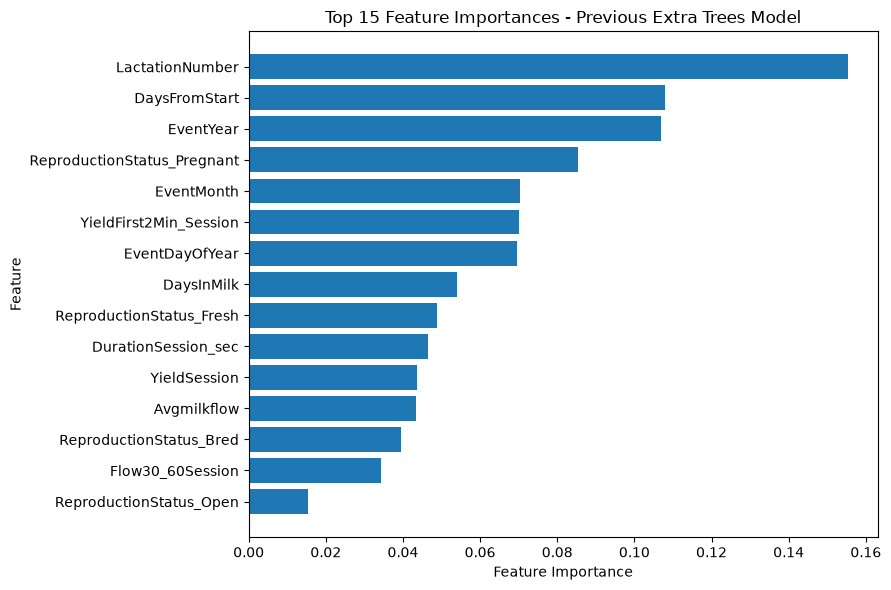

In [21]:
# ============================================================
# 4. Previous Extra Trees feature importance
# ============================================================

previous_feature_importance = pd.DataFrame({
    "Feature": [
        "LactationNumber",
        "DaysFromStart",
        "EventYear",
        "ReproductionStatus_Pregnant",
        "EventMonth",
        "YieldFirst2Min_Session",
        "EventDayOfYear",
        "DaysInMilk",
        "ReproductionStatus_Fresh",
        "DurationSession_sec",
        "YieldSession",
        "Avgmilkflow",
        "ReproductionStatus_Bred",
        "Flow30_60Session",
        "ReproductionStatus_Open",
        "EventDay",
        "EventDayOfWeek",
        "milking_2",
        "milking_1",
        "milking_3",
    ],

    "Importance": [
        0.155389,
        0.108062,
        0.106878,
        0.085385,
        0.070461,
        0.070028,
        0.069678,
        0.053940,
        0.048782,
        0.046513,
        0.043713,
        0.043402,
        0.039394,
        0.034179,
        0.015426,
        0.003800,
        0.001956,
        0.001195,
        0.001005,
        0.000813,
    ],
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(
    previous_feature_importance
)

top_features = (
    previous_feature_importance
    .head(15)
)

plt.figure(
    figsize=(9, 6)
)

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Feature Importances - Previous Extra Trees Model"
)

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# 5. Target encoding and safe balanced-accuracy helper
# ============================================================

train_class_values = pd.Index(
    data_train["AnimalId"]
    .astype(object)
    .unique()
)

train_class_to_number = {
    animal_id: class_number
    for class_number, animal_id
    in enumerate(
        train_class_values
    )
}

train_number_to_class = {
    class_number: animal_id
    for class_number, animal_id
    in enumerate(
        train_class_values
    )
}

validation_encoded = (
    data_validation["AnimalId"]
    .astype(object)
    .map(
        train_class_to_number
    )
)

known_validation_mask = (
    validation_encoded.notna()
)

validation_seen = (
    data_validation.loc[
        known_validation_mask
    ]
    .copy()
)

print(
    f"Training classes: "
    f"{len(train_class_values):,}"
)

print(
    "Validation class coverage:",
    f"{known_validation_mask.mean():.2%}"
)


def balanced_accuracy_present_classes(
    y_true,
    y_pred
):
    present_labels = np.unique(
        y_true
    )

    return recall_score(
        y_true,
        y_pred,
        labels=present_labels,
        average="macro",
        zero_division=0
    )

Training classes: 7,539
Validation class coverage: 91.95%


In [23]:
# ============================================================
# 6. Date/lactation structural utilities
# ============================================================

def event_day_from_origin(
    frame,
    origin_date
):
    return (
        pd.to_datetime(
            frame["EventDate"],
            errors="coerce"
        )
        - origin_date
    ).dt.days.astype(
        "float32"
    )


def lactation_start_day(
    frame,
    origin_date
):
    event_date = pd.to_datetime(
        frame["EventDate"],
        errors="coerce"
    )

    lactation_start = (
        event_date
        - pd.to_timedelta(
            frame["DaysInMilk"],
            unit="D"
        )
    )

    return (
        lactation_start
        - origin_date
    ).dt.days.astype(
        "float32"
    )


origin_date = (
    data_train[
        "EventDate"
    ].min()
)

# 7. Build richer animal/lactation profiles

Each candidate profile now contains:

- estimated lactation start day;
- last known event day;
- last known DaysInMilk;
- whether the profile is observed or projected;
- one-lactation-ahead projection when the next lactation was not yet observed in training.

This gives the candidate ranker additional longitudinal information without using future labels.

In [24]:
# ============================================================
# 7. Build observed + projected structural profiles
# ============================================================

def build_structural_profiles(
    labelled_frame,
    class_to_number,
    origin_date,
    include_projection=True
):
    temp = labelled_frame[
        [
            "AnimalId",
            "LactationNumber",
            "EventDate",
            "DaysInMilk",
        ]
    ].copy()

    temp["EventDay"] = (
        event_day_from_origin(
            temp,
            origin_date
        )
    )

    temp["LactationStartDay"] = (
        lactation_start_day(
            temp,
            origin_date
        )
    )

    temp = temp.dropna(
        subset=[
            "AnimalId",
            "LactationNumber",
            "DaysInMilk",
            "EventDay",
            "LactationStartDay",
        ]
    )

    observed = (
        temp
        .groupby(
            [
                "AnimalId",
                "LactationNumber",
            ],
            observed=True
        )
        .agg(
            LactationStartDay=(
                "LactationStartDay",
                "median"
            ),
            LastEventDay=(
                "EventDay",
                "max"
            ),
            LastDaysInMilk=(
                "DaysInMilk",
                "max"
            ),
        )
        .reset_index()
    )

    observed["ClassId"] = (
        observed["AnimalId"]
        .astype(object)
        .map(
            class_to_number
        )
    )

    observed = observed.loc[
        observed["ClassId"].notna()
    ].copy()

    observed["ClassId"] = (
        observed["ClassId"]
        .astype(np.int32)
    )

    observed["LactationNumber"] = (
        observed["LactationNumber"]
        .round()
        .astype(np.int16)
    )

    for col in [
        "LactationStartDay",
        "LastEventDay",
        "LastDaysInMilk",
    ]:
        observed[col] = (
            observed[col]
            .round()
            .astype(np.int32)
        )

    observed["IsProjected"] = False

    # Consecutive-lactation interval estimation.
    interval_rows = []

    for class_id, group in observed.groupby(
        "ClassId",
        sort=False
    ):
        group = group.sort_values(
            "LactationNumber"
        )

        lactations = (
            group[
                "LactationNumber"
            ]
            .to_numpy()
        )

        starts = (
            group[
                "LactationStartDay"
            ]
            .to_numpy()
        )

        for i in range(
            1,
            len(group)
        ):
            if (
                lactations[i]
                - lactations[i - 1]
                == 1
            ):
                interval = (
                    starts[i]
                    - starts[i - 1]
                )

                if (
                    250
                    <= interval
                    <= 550
                ):
                    interval_rows.append({
                        "ClassId":
                            int(class_id),

                        "IntervalDays":
                            int(interval),
                    })

    if interval_rows:
        interval_df = pd.DataFrame(
            interval_rows
        )

        global_interval = int(
            round(
                interval_df[
                    "IntervalDays"
                ].median()
            )
        )

        animal_interval = (
            interval_df
            .groupby(
                "ClassId"
            )[
                "IntervalDays"
            ]
            .median()
            .to_dict()
        )

    else:
        global_interval = 365
        animal_interval = {}

    if not include_projection:
        return (
            observed,
            global_interval
        )

    projected_rows = []

    for class_id, group in observed.groupby(
        "ClassId",
        sort=False
    ):
        last = (
            group
            .sort_values(
                "LactationNumber"
            )
            .iloc[-1]
        )

        last_lactation = int(
            last[
                "LactationNumber"
            ]
        )

        if (
            last_lactation
            >= 10
        ):
            continue

        interval = int(
            round(
                animal_interval.get(
                    int(class_id),
                    global_interval
                )
            )
        )

        projected_start = int(
            last[
                "LactationStartDay"
            ]
            + interval
        )

        projected_rows.append({
            "AnimalId":
                last["AnimalId"],

            "LactationNumber":
                last_lactation + 1,

            "LactationStartDay":
                projected_start,

            "LastEventDay":
                int(
                    last[
                        "LastEventDay"
                    ]
                ),

            "LastDaysInMilk":
                int(
                    last[
                        "LastDaysInMilk"
                    ]
                ),

            "ClassId":
                int(class_id),

            "IsProjected":
                True,
        })

    if projected_rows:
        projected = pd.DataFrame(
            projected_rows
        )

        profiles = pd.concat(
            [
                observed,
                projected,
            ],
            ignore_index=True
        )

    else:
        profiles = observed.copy()

    return (
        profiles,
        global_interval
    )


train_profiles, global_lactation_interval = (
    build_structural_profiles(
        data_train,
        train_class_to_number,
        origin_date,
        include_projection=True
    )
)

print(
    f"Structural profile rows: "
    f"{len(train_profiles):,}"
)

print(
    f"Median consecutive-lactation interval: "
    f"{global_lactation_interval} days"
)

display(
    train_profiles.head()
)

Structural profile rows: 19,733
Median consecutive-lactation interval: 360 days


,AnimalId,LactationNumber,LactationStartDay,LastEventDay,LastDaysInMilk,ClassId,IsProjected
0,-1.0070488357751972e+18,1,-68,221,289,2466,False
1,-1.0070488357751972e+18,2,287,548,261,2466,False
2,-1.0074682684645778e+18,2,-178,102,280,1871,False
3,-1.0074682684645778e+18,3,154,548,394,1871,False
4,-1.0166670011419512e+17,1,483,548,65,7240,False


In [25]:
# ============================================================
# 8. Fast structural-profile lookup
# ============================================================

def make_profile_lookup(
    profiles
):
    lookup = {}

    for lactation, group in profiles.groupby(
        "LactationNumber",
        sort=False
    ):
        lookup[
            int(lactation)
        ] = {
            "class_ids":
                group[
                    "ClassId"
                ]
                .to_numpy(
                    dtype=np.int32
                ),

            "start_days":
                group[
                    "LactationStartDay"
                ]
                .to_numpy(
                    dtype=np.float32
                ),

            "last_event_days":
                group[
                    "LastEventDay"
                ]
                .to_numpy(
                    dtype=np.float32
                ),

            "last_dim":
                group[
                    "LastDaysInMilk"
                ]
                .to_numpy(
                    dtype=np.float32
                ),

            "projected":
                group[
                    "IsProjected"
                ]
                .to_numpy(
                    dtype=bool
                ),
        }

    return lookup


profile_lookup_train = (
    make_profile_lookup(
        train_profiles
    )
)


def get_candidate_profiles(
    profile_lookup,
    lactation_number,
    query_start_day,
    start_tolerance_days,
    max_candidates,
    projected_rank_penalty_days
):
    if (
        pd.isna(
            lactation_number
        )
        or pd.isna(
            query_start_day
        )
    ):
        return None

    lactation_number = int(
        round(
            float(
                lactation_number
            )
        )
    )

    profile = (
        profile_lookup.get(
            lactation_number
        )
    )

    if profile is None:
        return None

    start_difference = np.abs(
        profile[
            "start_days"
        ]
        - float(
            query_start_day
        )
    )

    rank_difference = (
        start_difference
        + profile[
            "projected"
        ].astype(
            np.float32
        )
        * projected_rank_penalty_days
    )

    inside = (
        start_difference
        <= start_tolerance_days
    )

    if inside.any():
        positions = np.flatnonzero(
            inside
        )
    else:
        positions = np.arange(
            len(
                profile[
                    "class_ids"
                ]
            )
        )

    positions = (
        positions[
            np.argsort(
                rank_difference[
                    positions
                ]
            )
        ][
            :max_candidates
        ]
    )

    return {
        key:
            value[
                positions
            ]

        for key, value
        in profile.items()
    } | {
        "start_difference":
            start_difference[
                positions
            ]
    }

# 9. Candidate diagnostic

This now reports two useful upper bounds:

- **candidate coverage**: true AnimalId appears somewhere in the candidate list;
- **nearest-start accuracy**: simply choosing the candidate with the closest estimated lactation start date.

If nearest-start accuracy is already strong, the structural variables should receive much more weight than milk-production distance.

In [26]:
# ============================================================
# 9. Candidate diagnostic
# ============================================================

diagnostic_raw = (
    validation_seen.sample(
        n=min(
            CANDIDATE_DIAGNOSTIC_ROWS,
            len(
                validation_seen
            )
        ),
        random_state=RANDOM_STATE
    )
)

diagnostic_true = (
    diagnostic_raw[
        "AnimalId"
    ]
    .astype(object)
    .map(
        train_class_to_number
    )
    .astype(np.int32)
    .to_numpy()
)

diagnostic_lactation = (
    diagnostic_raw[
        "LactationNumber"
    ]
    .to_numpy()
)

diagnostic_start = (
    lactation_start_day(
        diagnostic_raw,
        origin_date
    )
    .to_numpy()
)

candidate_rows = []

for tolerance in [
    3, 7, 14, 21, 30, 45, 60
]:
    for max_candidates in [
        3, 5, 10, 20, 40
    ]:
        covered = 0
        nearest_correct = 0
        counts = []

        for i in range(
            len(
                diagnostic_raw
            )
        ):
            candidate = (
                get_candidate_profiles(
                    profile_lookup_train,
                    diagnostic_lactation[
                        i
                    ],
                    diagnostic_start[
                        i
                    ],
                    start_tolerance_days=
                        tolerance,
                    max_candidates=
                        max_candidates,
                    projected_rank_penalty_days=
                        7,
                )
            )

            if candidate is None:
                counts.append(0)
                continue

            class_ids = (
                candidate[
                    "class_ids"
                ]
            )

            counts.append(
                len(
                    class_ids
                )
            )

            if (
                diagnostic_true[
                    i
                ]
                in class_ids
            ):
                covered += 1

            nearest_class = int(
                class_ids[
                    np.argmin(
                        candidate[
                            "start_difference"
                        ]
                    )
                ]
            )

            if (
                nearest_class
                == diagnostic_true[
                    i
                ]
            ):
                nearest_correct += 1

        candidate_rows.append({
            "start_tolerance_days":
                tolerance,

            "max_candidates":
                max_candidates,

            "candidate_coverage":
                covered
                / len(
                    diagnostic_raw
                ),

            "nearest_start_accuracy":
                nearest_correct
                / len(
                    diagnostic_raw
                ),

            "mean_candidate_count":
                float(
                    np.mean(
                        counts
                    )
                ),
        })


candidate_diagnostic_df = (
    pd.DataFrame(
        candidate_rows
    )
    .sort_values(
        [
            "candidate_coverage",
            "nearest_start_accuracy",
        ],
        ascending=[
            False,
            False,
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    candidate_diagnostic_df.head(
        25
    )
)

print(
    "Best candidate coverage:",
    f"{candidate_diagnostic_df['candidate_coverage'].max():.2%}"
)

print(
    "Best nearest-start accuracy:",
    f"{candidate_diagnostic_df['nearest_start_accuracy'].max():.2%}"
)

,start_tolerance_days,max_candidates,candidate_coverage,nearest_start_accuracy,mean_candidate_count
0,60,40,0.835500,0.198500,39.925125
1,45,40,0.835000,0.195500,39.865125
2,30,40,0.834250,0.199625,39.762500
3,21,40,0.833625,0.204250,39.580375
4,14,40,0.833125,0.196875,39.229250
5,7,40,0.831000,0.200125,37.331500
6,3,40,0.827000,0.201000,30.289000
7,60,20,0.822250,0.199125,19.981000
8,14,20,0.822125,0.197875,19.863375
9,45,20,0.821875,0.195750,19.975250


Best candidate coverage: 83.55%
Best nearest-start accuracy: 20.76%


In [27]:
# ============================================================
# Fixed candidate-generation parameters for reranker
# ============================================================

RERANKER_CANDIDATE_PARAMS = {
    "start_tolerance_days": 21,
    "max_candidates": 120,
    "projected_rank_penalty_days": 7,
    "dim_tolerance_days": 30,
}

print("Candidate-generation parameters fixed for reranker:")

for key, value in RERANKER_CANDIDATE_PARAMS.items():
    print(f"{key}: {value}")

Candidate-generation parameters fixed for reranker:
start_tolerance_days: 21
max_candidates: 120
projected_rank_penalty_days: 7
dim_tolerance_days: 30


In [28]:
# ============================================================
# Internal chronological split for reranker development
# ============================================================

# Sort the original training period chronologically.
reranker_base = (
    data_train
    .sort_values("EventDate")
    .reset_index(drop=True)
)

n_reranker = len(
    reranker_base
)

# ------------------------------------------------------------
# Approximate 70% / 15% / 15% positions
# ------------------------------------------------------------

history_position = int(
    n_reranker * 0.70
)

train_query_position = int(
    n_reranker * 0.85
)

# ------------------------------------------------------------
# Move boundaries to whole EventDate values
# so the same date is not split across datasets
# ------------------------------------------------------------

history_cut_date = (
    reranker_base.iloc[
        history_position
    ]["EventDate"]
)

dev_cut_date = (
    reranker_base.iloc[
        train_query_position
    ]["EventDate"]
)

# ------------------------------------------------------------
# 1. History
# Used to construct candidate profiles / KNN reference
# ------------------------------------------------------------

reranker_history = (
    reranker_base.loc[
        reranker_base["EventDate"]
        < history_cut_date
    ]
    .copy()
)

# ------------------------------------------------------------
# 2. Reranker training queries
# These records will later generate candidate training pairs
# ------------------------------------------------------------

reranker_train_queries = (
    reranker_base.loc[
        (
            reranker_base["EventDate"]
            >= history_cut_date
        )
        &
        (
            reranker_base["EventDate"]
            < dev_cut_date
        )
    ]
    .copy()
)

# ------------------------------------------------------------
# 3. Reranker development queries
# Used for reranker hyperparameter selection
# ------------------------------------------------------------

reranker_dev_queries = (
    reranker_base.loc[
        reranker_base["EventDate"]
        >= dev_cut_date
    ]
    .copy()
)

# ============================================================
# Basic checks
# ============================================================

print("Internal reranker chronological split")
print("=" * 55)

print(
    f"History: "
    f"{len(reranker_history):,} "
    f"({len(reranker_history)/n_reranker:.2%})"
)

print(
    f"Reranker training queries: "
    f"{len(reranker_train_queries):,} "
    f"({len(reranker_train_queries)/n_reranker:.2%})"
)

print(
    f"Reranker development queries: "
    f"{len(reranker_dev_queries):,} "
    f"({len(reranker_dev_queries)/n_reranker:.2%})"
)

print("\nDate ranges:")

print(
    "History:",
    reranker_history["EventDate"].min(),
    "to",
    reranker_history["EventDate"].max()
)

print(
    "Reranker train:",
    reranker_train_queries["EventDate"].min(),
    "to",
    reranker_train_queries["EventDate"].max()
)

print(
    "Reranker dev:",
    reranker_dev_queries["EventDate"].min(),
    "to",
    reranker_dev_queries["EventDate"].max()
)

Internal reranker chronological split
History: 2,787,167 (69.94%)
Reranker training queries: 592,716 (14.87%)
Reranker development queries: 605,205 (15.19%)

Date ranges:
History: 2019-06-14 00:00:00 to 2020-07-05 00:00:00
Reranker train: 2020-07-06 00:00:00 to 2020-09-20 00:00:00
Reranker dev: 2020-09-21 00:00:00 to 2020-12-13 00:00:00


In [29]:
# ============================================================
# Check whether query AnimalIds already exist in history
# ============================================================

history_animal_ids = set(
    reranker_history[
        "AnimalId"
    ]
    .astype(object)
    .unique()
)

train_seen_mask = (
    reranker_train_queries[
        "AnimalId"
    ]
    .astype(object)
    .isin(
        history_animal_ids
    )
)

dev_seen_mask = (
    reranker_dev_queries[
        "AnimalId"
    ]
    .astype(object)
    .isin(
        history_animal_ids
    )
)

print("\nAnimalId coverage from history")
print("=" * 55)

print(
    "Reranker training query coverage:",
    f"{train_seen_mask.mean():.2%}"
)

print(
    "Reranker development query coverage:",
    f"{dev_seen_mask.mean():.2%}"
)


AnimalId coverage from history
Reranker training query coverage: 95.38%
Reranker development query coverage: 84.43%


In [35]:
# ============================================================
# Step 3
# Build Candidate/KNN reference system from reranker_history
# ============================================================

# ------------------------------------------------------------
# 1. Encode AnimalId using HISTORY ONLY
# ------------------------------------------------------------

reranker_class_values = pd.Index(
    reranker_history[
        "AnimalId"
    ]
    .astype(object)
    .unique()
)

reranker_class_to_number = {
    animal_id: class_number
    for class_number, animal_id
    in enumerate(
        reranker_class_values
    )
}

reranker_number_to_class = {
    class_number: animal_id
    for class_number, animal_id
    in enumerate(
        reranker_class_values
    )
}

print(
    "AnimalId classes in reranker history:",
    f"{len(reranker_class_values):,}"
)


# ------------------------------------------------------------
# 2. Define history time origin
# ------------------------------------------------------------

reranker_origin_date = (
    reranker_history[
        "EventDate"
    ].min()
)

print(
    "Reranker origin date:",
    reranker_origin_date
)


# ------------------------------------------------------------
# 3. Build structural lactation profiles
#    IMPORTANT: history only
# ------------------------------------------------------------

(
    reranker_profiles,
    reranker_global_lactation_interval
) = build_structural_profiles(
    reranker_history,
    reranker_class_to_number,
    reranker_origin_date,
    include_projection=True
)

reranker_profile_lookup = (
    make_profile_lookup(
        reranker_profiles
    )
)

print(
    "Structural profile rows:",
    f"{len(reranker_profiles):,}"
)

print(
    "Estimated global lactation interval:",
    reranker_global_lactation_interval
)


# ------------------------------------------------------------
# 4. Sample historical reference records
# ------------------------------------------------------------

RERANKER_REFERENCE_ROWS_PER_GROUP = 250

reranker_reference_indices = (
    sample_reference_rows(
        reranker_history,
        max_rows_per_group=
            RERANKER_REFERENCE_ROWS_PER_GROUP,
        recent_fraction=0.80,
        random_state=RANDOM_STATE
    )
)

reranker_reference_raw = (
    reranker_history.loc[
        reranker_reference_indices
    ]
    .copy()
)

print(
    "Reference rows:",
    f"{len(reranker_reference_raw):,}"
)


# ------------------------------------------------------------
# 5. Fit distance preprocessing
#    AGAIN: history only
# ------------------------------------------------------------

(
    X_reranker_reference,
    reranker_numeric_columns,
    reranker_numeric_fill,
    reranker_scaler,
    reranker_reproduction_columns,
    reranker_feature_names
) = fit_distance_preprocessor(
    reranker_reference_raw
)

print(
    "Number of distance features:",
    len(reranker_feature_names)
)

print(
    "Distance features:"
)

print(
    reranker_feature_names
)


# ------------------------------------------------------------
# 6. Reference AnimalId encoding
# ------------------------------------------------------------

reranker_reference_class_ids = (
    reranker_reference_raw[
        "AnimalId"
    ]
    .astype(object)
    .map(
        reranker_class_to_number
    )
    .astype(np.int32)
    .to_numpy()
)


# ------------------------------------------------------------
# 7. Reference lactation / DIM / date arrays
# ------------------------------------------------------------

reranker_reference_lactations = (
    reranker_reference_raw[
        "LactationNumber"
    ]
    .round()
    .astype(np.int16)
    .to_numpy()
)

reranker_reference_dim = (
    reranker_reference_raw[
        "DaysInMilk"
    ]
    .astype(np.float32)
    .to_numpy()
)

reranker_reference_event_day = (
    event_day_from_origin(
        reranker_reference_raw,
        reranker_origin_date
    )
    .to_numpy()
)


# ------------------------------------------------------------
# 8. Build fast lookup:
#    (AnimalId, LactationNumber) -> historical rows
# ------------------------------------------------------------

(
    reranker_reference_exact_index,
    reranker_reference_class_lactations
) = build_reference_index(
    reranker_reference_class_ids,
    reranker_reference_lactations
)


# ------------------------------------------------------------
# 9. Sanity checks
# ------------------------------------------------------------

print("\n" + "=" * 60)

print(
    "History rows:",
    f"{len(reranker_history):,}"
)

print(
    "History AnimalId classes:",
    f"{len(reranker_class_values):,}"
)

print(
    "Profile rows:",
    f"{len(reranker_profiles):,}"
)

print(
    "Reference rows:",
    f"{len(reranker_reference_raw):,}"
)

print(
    "Reference matrix shape:",
    X_reranker_reference.shape
)

print(
    "Exact AnimalId-lactation groups:",
    f"{len(reranker_reference_exact_index):,}"
)

AnimalId classes in reranker history: 6,667
Reranker origin date: 2019-06-14 00:00:00
Structural profile rows: 16,396
Estimated global lactation interval: 359
Reference rows: 1,783,366


NameError: name 'fit_distance_preprocessor' is not defined

In [ ]:
# ============================================================
# Step 4
# Build cow-level and lactation/DIM trajectory prototypes
# ============================================================

# IMPORTANT:
# Keep the DIM_BIN_WIDTH value that you selected earlier.
#
# Example:
# DIM_BIN_WIDTH = 14
#
# Do NOT redefine it here if it has already been defined.

print(
    "Using DIM_BIN_WIDTH:",
    DIM_BIN_WIDTH
)


# ============================================================
# 1. Whole-cow prototype
# ============================================================
#
# Each AnimalId gets one median feature vector based on
# all of its sampled historical reference records.
#
# Example:
#
# Cow 123
#     -> median DaysInMilk-related standardized value
#     -> median milk-flow pattern
#     -> median yield pattern
#     -> median duration pattern
#     -> ...
#
# This represents the cow's overall phenotype.
# ============================================================

reranker_cow_prototype = {}

unique_reranker_classes = np.unique(
    reranker_reference_class_ids
)

for class_id in unique_reranker_classes:

    positions = np.flatnonzero(
        reranker_reference_class_ids
        == class_id
    )

    prototype = np.median(
        X_reranker_reference[
            positions
        ],
        axis=0
    )

    reranker_cow_prototype[
        int(class_id)
    ] = prototype.astype(
        np.float32
    )


print(
    "Whole-cow prototypes:",
    f"{len(reranker_cow_prototype):,}"
)


# ============================================================
# 2. Assign each reference record to a DIM bin
# ============================================================
#
# Example with DIM_BIN_WIDTH = 14:
#
# DIM 0-13   -> bin 0
# DIM 14-27  -> bin 1
# DIM 28-41  -> bin 2
# ...
# ============================================================

reranker_reference_dim_bin = (
    np.floor(
        reranker_reference_dim
        / DIM_BIN_WIDTH
    )
    .astype(np.int16)
)

print(
    "Number of DIM bins:",
    len(
        np.unique(
            reranker_reference_dim_bin
        )
    )
)

print(
    "DIM bin range:",
    reranker_reference_dim_bin.min(),
    "to",
    reranker_reference_dim_bin.max()
)


# ============================================================
# 3. Build AnimalId × Lactation × DIM-bin prototypes
# ============================================================
#
# Dictionary structure:
#
# reranker_lactation_prototype[
#     (class_id, lactation_number)
# ][
#     dim_bin
# ]
#
# returns a 13-feature median vector.
# ============================================================

reranker_lactation_prototype = {}

for (
    key,
    positions
) in reranker_reference_exact_index.items():

    class_id, lactation_number = key

    bins_here = (
        reranker_reference_dim_bin[
            positions
        ]
    )

    prototype_by_bin = {}

    unique_bins_here = np.unique(
        bins_here
    )

    for dim_bin in unique_bins_here:

        bin_positions = (
            positions[
                bins_here
                == dim_bin
            ]
        )

        prototype = np.median(
            X_reranker_reference[
                bin_positions
            ],
            axis=0
        )

        prototype_by_bin[
            int(dim_bin)
        ] = prototype.astype(
            np.float32
        )

    reranker_lactation_prototype[
        (
            int(class_id),
            int(lactation_number)
        )
    ] = prototype_by_bin


# ============================================================
# 4. Sanity checks
# ============================================================

print("\n" + "=" * 60)

print(
    "Whole-cow prototype count:",
    f"{len(reranker_cow_prototype):,}"
)

print(
    "Lactation prototype groups:",
    f"{len(reranker_lactation_prototype):,}"
)

total_lactation_dim_prototypes = sum(
    len(
        prototype_dict
    )
    for prototype_dict
    in reranker_lactation_prototype.values()
)

print(
    "Total AnimalId-Lactation-DIM prototypes:",
    f"{total_lactation_dim_prototypes:,}"
)


# ============================================================
# 5. Check prototype dimensions
# ============================================================

example_cow_class = next(
    iter(
        reranker_cow_prototype
    )
)

example_cow_vector = (
    reranker_cow_prototype[
        example_cow_class
    ]
)

print(
    "\nExample cow prototype shape:",
    example_cow_vector.shape
)


example_lactation_key = next(
    iter(
        reranker_lactation_prototype
    )
)

example_bin_dictionary = (
    reranker_lactation_prototype[
        example_lactation_key
    ]
)

example_dim_bin = next(
    iter(
        example_bin_dictionary
    )
)

example_lactation_vector = (
    example_bin_dictionary[
        example_dim_bin
    ]
)

print(
    "Example lactation prototype key:",
    example_lactation_key
)

print(
    "Example DIM bin:",
    example_dim_bin
)

print(
    "Example lactation prototype shape:",
    example_lactation_vector.shape
)

Using DIM_BIN_WIDTH: 7
Whole-cow prototypes: 6,667
Number of DIM bins: 72
DIM bin range: 0 to 71

Whole-cow prototype count: 6,667
Lactation prototype groups: 9,731
Total AnimalId-Lactation-DIM prototypes: 202,065

Example cow prototype shape: (13,)
Example lactation prototype key: (0, 1)
Example DIM bin: 37
Example lactation prototype shape: (13,)


In [ ]:
# ============================================================
# Step 5
# Convert ONE query record into candidate-level feature rows
# ============================================================

def get_nearest_lactation_prototype(
    prototype_table,
    class_id,
    lactation_number,
    query_dim
):
    """
    Return the prototype from the nearest available DIM bin
    for one AnimalId x Lactation combination.
    """

    key = (
        int(class_id),
        int(lactation_number)
    )

    prototype_dict = (
        prototype_table.get(key)
    )

    if not prototype_dict:
        return None

    query_bin = int(
        np.floor(
            float(query_dim)
            / DIM_BIN_WIDTH
        )
    )

    available_bins = np.asarray(
        list(
            prototype_dict.keys()
        ),
        dtype=np.int16
    )

    nearest_bin = int(
        available_bins[
            np.argmin(
                np.abs(
                    available_bins
                    - query_bin
                )
            )
        ]
    )

    return prototype_dict[
        nearest_bin
    ]


def build_candidate_features_for_one_query(
    query_frame,
    query_id="query_0"
):
    """
    query_frame must contain exactly ONE row.

    Output:
        one row per candidate AnimalId
    """

    if len(query_frame) != 1:
        raise ValueError(
            "query_frame must contain exactly one row."
        )

    # --------------------------------------------------------
    # 1. Transform query into same 13-feature space
    # --------------------------------------------------------

    X_query = transform_distance_features(
        query_frame,
        reranker_numeric_columns,
        reranker_numeric_fill,
        reranker_scaler,
        reranker_reproduction_columns
    )

    query_vector = (
        X_query[0]
    )

    # --------------------------------------------------------
    # 2. Query structural information
    # --------------------------------------------------------

    query_event_day = float(
        event_day_from_origin(
            query_frame,
            reranker_origin_date
        ).iloc[0]
    )

    query_start_day = float(
        lactation_start_day(
            query_frame,
            reranker_origin_date
        ).iloc[0]
    )

    query_dim = float(
        query_frame[
            "DaysInMilk"
        ].iloc[0]
    )

    query_lactation = int(
        round(
            float(
                query_frame[
                    "LactationNumber"
                ].iloc[0]
            )
        )
    )

    true_animal_id = (
        query_frame[
            "AnimalId"
        ]
        .astype(object)
        .iloc[0]
    )

    true_class_id = (
        reranker_class_to_number.get(
            true_animal_id,
            np.nan
        )
    )

    # --------------------------------------------------------
    # 3. Generate candidate AnimalIds
    # --------------------------------------------------------

    candidate = get_candidate_profiles(
        reranker_profile_lookup,
        query_lactation,
        query_start_day,

        start_tolerance_days=
            RERANKER_CANDIDATE_PARAMS[
                "start_tolerance_days"
            ],

        max_candidates=
            RERANKER_CANDIDATE_PARAMS[
                "max_candidates"
            ],

        projected_rank_penalty_days=
            RERANKER_CANDIDATE_PARAMS[
                "projected_rank_penalty_days"
            ],
    )

    if candidate is None:
        return pd.DataFrame()

    candidate_count = len(
        candidate[
            "class_ids"
        ]
    )

    rows = []

    # --------------------------------------------------------
    # Numeric-feature positions
    # --------------------------------------------------------

    numeric_feature_positions = {
        feature_name: position
        for position, feature_name
        in enumerate(
            reranker_feature_names
        )
        if not feature_name.startswith(
            "ReproductionStatus_"
        )
    }

    reproduction_positions = [
        position
        for position, feature_name
        in enumerate(
            reranker_feature_names
        )
        if feature_name.startswith(
            "ReproductionStatus_"
        )
    ]

    # --------------------------------------------------------
    # 4. Candidate by candidate
    # --------------------------------------------------------

    for candidate_position in range(
        candidate_count
    ):

        class_id = int(
            candidate[
                "class_ids"
            ][candidate_position]
        )

        start_difference = float(
            candidate[
                "start_difference"
            ][candidate_position]
        )

        is_projected = int(
            candidate[
                "projected"
            ][candidate_position]
        )

        last_event_day = float(
            candidate[
                "last_event_days"
            ][candidate_position]
        )

        # ----------------------------------------------------
        # Find appropriate historical lactation
        # ----------------------------------------------------

        (
            selected_lactation,
            lactation_gap
        ) = choose_reference_lactation(
            class_id,
            query_lactation,
            reranker_reference_class_lactations
        )

        if selected_lactation is None:
            continue

        reference_positions = (
            reranker_reference_exact_index.get(
                (
                    class_id,
                    selected_lactation
                )
            )
        )

        if (
            reference_positions is None
            or len(reference_positions) == 0
        ):
            continue

        # ----------------------------------------------------
        # 5. DaysInMilk compatibility
        # ----------------------------------------------------

        dim_difference = np.abs(
            reranker_reference_dim[
                reference_positions
            ]
            - query_dim
        )

        closest_dim_difference = float(
            np.min(
                dim_difference
            )
        )

        dim_tolerance = (
            RERANKER_CANDIDATE_PARAMS[
                "dim_tolerance_days"
            ]
        )

        inside_dim = (
            dim_difference
            <= dim_tolerance
        )

        if inside_dim.any():

            usable_positions = (
                reference_positions[
                    inside_dim
                ]
            )

        else:

            nearest_dim_order = (
                np.argsort(
                    dim_difference
                )
            )

            usable_positions = (
                reference_positions[
                    nearest_dim_order[
                        :min(
                            10,
                            len(nearest_dim_order)
                        )
                    ]
                ]
            )

        # ----------------------------------------------------
        # 6. Local KNN distances
        # ----------------------------------------------------

        differences = (
            X_reranker_reference[
                usable_positions
            ]
            - query_vector
        )

        manhattan_distances = (
            np.sum(
                np.abs(
                    differences
                ),
                axis=1
            )
        )

        euclidean_distances = (
            np.sqrt(
                np.sum(
                    differences ** 2,
                    axis=1
                )
            )
        )

        def nearest_mean(
            distances,
            k
        ):
            k = min(
                k,
                len(distances)
            )

            nearest_values = (
                np.partition(
                    distances,
                    k - 1
                )[:k]
            )

            return float(
                np.mean(
                    nearest_values
                )
            )

        local_min_manhattan = float(
            np.min(
                manhattan_distances
            )
        )

        local_mean3_manhattan = (
            nearest_mean(
                manhattan_distances,
                3
            )
        )

        local_mean5_manhattan = (
            nearest_mean(
                manhattan_distances,
                5
            )
        )

        local_min_euclidean = float(
            np.min(
                euclidean_distances
            )
        )

        local_mean3_euclidean = (
            nearest_mean(
                euclidean_distances,
                3
            )
        )

        # ----------------------------------------------------
        # 7. Lactation/DIM prototype distance
        # ----------------------------------------------------

        lactation_prototype = (
            get_nearest_lactation_prototype(
                reranker_lactation_prototype,
                class_id,
                selected_lactation,
                query_dim
            )
        )

        residual_features = {}

        if lactation_prototype is not None:

            prototype_difference = (
                query_vector
                - lactation_prototype
            )

            lactation_manhattan = float(
                np.sum(
                    np.abs(
                        prototype_difference
                    )
                )
            )

            lactation_euclidean = float(
                np.sqrt(
                    np.sum(
                        prototype_difference ** 2
                    )
                )
            )

            # Individual standardized residuals
            for (
                feature_name,
                position
            ) in numeric_feature_positions.items():

                residual_features[
                    f"Residual_{feature_name}"
                ] = float(
                    abs(
                        prototype_difference[
                            position
                        ]
                    )
                )

            if reproduction_positions:

                reproduction_distance = float(
                    np.sum(
                        np.abs(
                            prototype_difference[
                                reproduction_positions
                            ]
                        )
                    )
                )

            else:
                reproduction_distance = 0.0

        else:

            lactation_manhattan = np.nan
            lactation_euclidean = np.nan
            reproduction_distance = np.nan

            for feature_name in (
                numeric_feature_positions
            ):

                residual_features[
                    f"Residual_{feature_name}"
                ] = np.nan

        # ----------------------------------------------------
        # 8. Whole-cow phenotype distance
        # ----------------------------------------------------

        cow_prototype = (
            reranker_cow_prototype.get(
                class_id
            )
        )

        if cow_prototype is not None:

            cow_difference = (
                query_vector
                - cow_prototype
            )

            cow_manhattan = float(
                np.sum(
                    np.abs(
                        cow_difference
                    )
                )
            )

            cow_euclidean = float(
                np.sqrt(
                    np.sum(
                        cow_difference ** 2
                    )
                )
            )

        else:

            cow_manhattan = np.nan
            cow_euclidean = np.nan

        # ----------------------------------------------------
        # 9. Temporal information
        # ----------------------------------------------------

        recency_days = max(
            0.0,
            query_event_day
            - last_event_day
        )

        # ----------------------------------------------------
        # 10. One candidate-level row
        # ----------------------------------------------------

        row = {

            "QueryId":
                query_id,

            "CandidateClassId":
                class_id,

            "TrueClassId":
                true_class_id,

            "IsCorrectCandidate":
                int(
                    class_id
                    == true_class_id
                )
                if not pd.isna(
                    true_class_id
                )
                else 0,

            "CandidateCount":
                candidate_count,

            "CandidateStartRank":
                candidate_position + 1,

            "StartDifference":
                start_difference,

            "IsProjected":
                is_projected,

            "RecencyDays":
                recency_days,

            "LogRecencyDays":
                np.log1p(
                    recency_days
                ),

            "LactationGap":
                lactation_gap,

            "QueryDaysInMilk":
                query_dim,

            "QueryLactationNumber":
                query_lactation,

            "ClosestDIMDifference":
                closest_dim_difference,

            "ReferenceRowCount":
                len(
                    reference_positions
                ),

            "LocalMinManhattan":
                local_min_manhattan,

            "LocalMean3Manhattan":
                local_mean3_manhattan,

            "LocalMean5Manhattan":
                local_mean5_manhattan,

            "LocalMinEuclidean":
                local_min_euclidean,

            "LocalMean3Euclidean":
                local_mean3_euclidean,

            "LactationPrototypeManhattan":
                lactation_manhattan,

            "LactationPrototypeEuclidean":
                lactation_euclidean,

            "CowPrototypeManhattan":
                cow_manhattan,

            "CowPrototypeEuclidean":
                cow_euclidean,

            "ReproductionDistance":
                reproduction_distance,
        }

        row.update(
            residual_features
        )

        rows.append(
            row
        )

    return pd.DataFrame(
        rows
    )

In [ ]:
# ============================================================
# Test Step 5 using ONE known query
# ============================================================

seen_train_queries = (
    reranker_train_queries.loc[
        reranker_train_queries[
            "AnimalId"
        ]
        .astype(object)
        .isin(
            reranker_class_values
        )
    ]
)

one_query = (
    seen_train_queries
    .iloc[[0]]
    .copy()
)

print(
    "True AnimalId:",
    one_query[
        "AnimalId"
    ].iloc[0]
)

print(
    "EventDate:",
    one_query[
        "EventDate"
    ].iloc[0]
)

print(
    "LactationNumber:",
    one_query[
        "LactationNumber"
    ].iloc[0]
)

print(
    "DaysInMilk:",
    one_query[
        "DaysInMilk"
    ].iloc[0]
)


one_query_candidates = (
    build_candidate_features_for_one_query(
        one_query,
        query_id="test_query_1"
    )
)

print("\nCandidate rows:")
print(
    len(
        one_query_candidates
    )
)

print(
    "Correct candidate present:",
    bool(
        one_query_candidates[
            "IsCorrectCandidate"
        ].max()
    )
)

print(
    "Number of correct candidate rows:",
    int(
        one_query_candidates[
            "IsCorrectCandidate"
        ].sum()
    )
)

print(
    "\nCandidate feature columns:"
)

print(
    one_query_candidates.columns.tolist()
)

display(
    one_query_candidates.head(
        10
    )
)

True AnimalId: 2.912573457058957e+18
EventDate: 2020-07-06 00:00:00
LactationNumber: 3
DaysInMilk: 280

Candidate rows:
40
Correct candidate present: True
Number of correct candidate rows: 1

Candidate feature columns:
['QueryId', 'CandidateClassId', 'TrueClassId', 'IsCorrectCandidate', 'CandidateCount', 'CandidateStartRank', 'StartDifference', 'IsProjected', 'RecencyDays', 'LogRecencyDays', 'LactationGap', 'QueryDaysInMilk', 'QueryLactationNumber', 'ClosestDIMDifference', 'ReferenceRowCount', 'LocalMinManhattan', 'LocalMean3Manhattan', 'LocalMean5Manhattan', 'LocalMinEuclidean', 'LocalMean3Euclidean', 'LactationPrototypeManhattan', 'LactationPrototypeEuclidean', 'CowPrototypeManhattan', 'CowPrototypeEuclidean', 'ReproductionDistance', 'Residual_DaysInMilk', 'Residual_Avgmilkflow', 'Residual_Flow30_60Session', 'Residual_YieldFirst2Min_Session', 'Residual_YieldSession', 'Residual_DurationSession_sec', 'Residual_YieldPerMinute', 'Residual_First2MinFraction', 'Residual_FlowShapeRatio']


,QueryId,CandidateClassId,TrueClassId,IsCorrectCandidate,CandidateCount,CandidateStartRank,StartDifference,IsProjected,RecencyDays,LogRecencyDays,...,ReproductionDistance,Residual_DaysInMilk,Residual_Avgmilkflow,Residual_Flow30_60Session,Residual_YieldFirst2Min_Session,Residual_YieldSession,Residual_DurationSession_sec,Residual_YieldPerMinute,Residual_First2MinFraction,Residual_FlowShapeRatio
0,test_query_1,2017,2017,1,40,1,0.0,0,1.0,0.693147,...,0.0,0.037824,0.000000,0.064396,0.005566,0.285276,0.487547,0.047773,0.176782,0.084534
1,test_query_1,2749,2017,0,40,2,0.0,0,123.0,4.820282,...,2.0,1.172556,2.635685,0.518096,1.607488,1.257805,1.150611,2.716401,0.509067,0.618676
2,test_query_1,3121,2017,0,40,3,1.0,0,1.0,0.693147,...,0.0,0.037824,0.564790,0.679086,0.742517,0.512199,1.638158,0.570521,1.365518,0.653655
3,test_query_1,1569,2017,0,40,4,1.0,0,1.0,0.693147,...,0.0,0.000000,1.004071,1.355246,1.104313,1.089233,2.496240,1.071769,2.468109,1.061672
4,test_query_1,3447,2017,0,40,5,1.0,0,1.0,0.693147,...,0.0,0.000000,1.976764,1.481111,1.894698,0.739123,1.257871,2.013034,1.090711,0.577638
5,test_query_1,3620,2017,0,40,6,1.0,0,1.0,0.693147,...,2.0,0.037824,1.694369,1.033265,1.667602,0.363078,2.086701,1.685921,2.073493,0.391347
6,test_query_1,966,2017,0,40,7,1.0,0,1.0,0.693147,...,0.0,0.000000,1.725746,1.194256,1.772244,0.648353,1.150611,1.775761,1.063887,0.357219
7,test_query_1,2714,2017,0,40,8,1.0,0,1.0,0.693147,...,0.0,0.028368,2.761194,2.452907,2.660593,0.246374,2.671757,2.792850,3.014005,1.103889
8,test_query_1,597,2017,0,40,9,1.0,0,24.0,3.218876,...,0.0,0.245859,0.188263,1.097661,0.061227,2.022862,3.013040,0.146059,3.271051,2.162823
9,test_query_1,2698,2017,0,40,10,2.0,0,75.0,4.330733,...,2.0,0.728119,0.502035,0.193188,0.293890,1.828356,2.203712,0.497777,1.614241,0.019117


In [ ]:
# ============================================================
# Step 6
# Build a SMALL pilot candidate-pair training dataset
# ============================================================

PILOT_QUERY_ROWS = 500

# ------------------------------------------------------------
# 1. Keep only AnimalIds that exist in reranker history
# ------------------------------------------------------------

reranker_train_seen = (
    reranker_train_queries.loc[
        reranker_train_queries[
            "AnimalId"
        ]
        .astype(object)
        .isin(
            reranker_class_values
        )
    ]
    .copy()
)

print(
    "Seen reranker training queries:",
    f"{len(reranker_train_seen):,}"
)


# ------------------------------------------------------------
# 2. Take a small pilot sample
# ------------------------------------------------------------

pilot_queries = (
    reranker_train_seen.sample(
        n=min(
            PILOT_QUERY_ROWS,
            len(reranker_train_seen)
        ),
        random_state=RANDOM_STATE
    )
    .copy()
)

print(
    "Pilot query rows:",
    len(pilot_queries)
)


# ------------------------------------------------------------
# 3. Convert each query into candidate-level rows
# ------------------------------------------------------------

pilot_candidate_tables = []

for counter, query_index in enumerate(
    pilot_queries.index,
    start=1
):

    one_query = (
        pilot_queries.loc[
            [query_index]
        ]
        .copy()
    )

    candidate_table = (
        build_candidate_features_for_one_query(
            one_query,
            query_id=
                f"train_query_{query_index}"
        )
    )

    if len(candidate_table) > 0:

        pilot_candidate_tables.append(
            candidate_table
        )

    if (
        counter % 50 == 0
        or counter == len(pilot_queries)
    ):

        print(
            f"Processed "
            f"{counter} / "
            f"{len(pilot_queries)} queries"
        )


# ------------------------------------------------------------
# 4. Combine all candidate rows
# ------------------------------------------------------------

pilot_candidate_pairs = (
    pd.concat(
        pilot_candidate_tables,
        ignore_index=True
    )
)

print("\n" + "=" * 60)

print(
    "Pilot candidate-pair rows:",
    f"{len(pilot_candidate_pairs):,}"
)

print(
    "Unique QueryIds:",
    f"{pilot_candidate_pairs['QueryId'].nunique():,}"
)

print(
    "Average candidate rows per query:",
    f"{len(pilot_candidate_pairs) / pilot_candidate_pairs['QueryId'].nunique():.2f}"
)

# ============================================================
# 5. Candidate coverage diagnostic for pilot queries
# ============================================================

pilot_query_correct_presence = (
    pilot_candidate_pairs
    .groupby(
        "QueryId"
    )[
        "IsCorrectCandidate"
    ]
    .max()
)

pilot_candidate_coverage = (
    pilot_query_correct_presence.mean()
)

print(
    "\nCandidate coverage:",
    f"{pilot_candidate_coverage:.2%}"
)


# ------------------------------------------------------------
# Check how many positive candidate rows exist
# ------------------------------------------------------------

positive_candidate_rows = int(
    pilot_candidate_pairs[
        "IsCorrectCandidate"
    ].sum()
)

print(
    "Positive candidate rows:",
    positive_candidate_rows
)

print(
    "Negative candidate rows:",
    len(pilot_candidate_pairs)
    - positive_candidate_rows
)

print(
    "Positive candidate percentage:",
    f"{pilot_candidate_pairs['IsCorrectCandidate'].mean():.4%}"
)


# ------------------------------------------------------------
# Check whether any query has multiple correct candidates
# ------------------------------------------------------------

positive_per_query = (
    pilot_candidate_pairs
    .groupby(
        "QueryId"
    )[
        "IsCorrectCandidate"
    ]
    .sum()
)

print(
    "\nQueries with exactly 1 correct candidate:",
    int(
        (
            positive_per_query == 1
        ).sum()
    )
)

print(
    "Queries with 0 correct candidates:",
    int(
        (
            positive_per_query == 0
        ).sum()
    )
)

print(
    "Queries with >1 correct candidate:",
    int(
        (
            positive_per_query > 1
        ).sum()
    )
)

# ============================================================
# 6. Inspect candidate feature table
# ============================================================

display(
    pilot_candidate_pairs.head(10)
)

print(
    "\nShape:",
    pilot_candidate_pairs.shape
)

print(
    "\nApproximate memory:",
    f"{pilot_candidate_pairs.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
)

Seen reranker training queries: 565,349
Pilot query rows: 500
Processed 50 / 500 queries
Processed 100 / 500 queries
Processed 150 / 500 queries
Processed 200 / 500 queries
Processed 250 / 500 queries
Processed 300 / 500 queries
Processed 350 / 500 queries
Processed 400 / 500 queries
Processed 450 / 500 queries
Processed 500 / 500 queries

Pilot candidate-pair rows: 19,009
Unique QueryIds: 500
Average candidate rows per query: 38.02

Candidate coverage: 91.40%
Positive candidate rows: 457
Negative candidate rows: 18552
Positive candidate percentage: 2.4041%

Queries with exactly 1 correct candidate: 457
Queries with 0 correct candidates: 43
Queries with >1 correct candidate: 0


,QueryId,CandidateClassId,TrueClassId,IsCorrectCandidate,CandidateCount,CandidateStartRank,StartDifference,IsProjected,RecencyDays,LogRecencyDays,...,ReproductionDistance,Residual_DaysInMilk,Residual_Avgmilkflow,Residual_Flow30_60Session,Residual_YieldFirst2Min_Session,Residual_YieldSession,Residual_DurationSession_sec,Residual_YieldPerMinute,Residual_First2MinFraction,Residual_FlowShapeRatio
0,train_query_2880652,2577,2669,0,40,1,0.0,0,12.0,2.564949,...,0.0,0.113473,0.125509,0.321981,0.222644,0.557584,0.897086,0.139939,0.267212,0.508505
1,train_query_2880652,3123,2669,0,40,2,0.0,0,13.0,2.639057,...,0.0,0.113473,2.635685,1.419642,1.985982,2.022862,0.195019,2.538547,0.105190,0.113499
2,train_query_2880652,2669,2669,1,40,3,0.0,0,12.0,2.564949,...,0.0,0.113473,0.000000,0.289782,0.381834,0.596485,0.702068,0.001449,0.642591,0.382056
3,train_query_2880652,5194,2669,0,40,4,1.0,0,56.0,4.043051,...,2.0,0.529541,2.196405,1.419642,1.888019,0.752090,2.203712,2.180489,2.449347,0.215320
4,train_query_2880652,5251,2669,0,40,5,1.0,0,58.0,4.077537,...,2.0,0.548454,0.564790,1.290850,0.819329,1.504179,2.320723,0.517053,2.535421,0.774471
5,train_query_2880652,694,2669,0,40,6,1.0,0,12.0,2.564949,...,0.0,0.104017,1.945387,0.840077,1.213409,1.491212,0.195019,1.921985,0.065233,0.289758
6,train_query_2880652,2047,2669,0,40,7,2.0,0,12.0,2.564949,...,0.0,0.151298,1.506106,0.807879,1.152181,0.330660,1.550399,1.450791,1.237116,0.136134
7,train_query_2880652,2503,2669,0,40,8,2.0,0,12.0,2.564949,...,1.0,0.165482,0.439281,0.450773,0.497609,2.146049,1.852678,0.384639,1.261821,0.843048
8,train_query_2880652,3168,2669,0,40,9,2.0,0,12.0,2.564949,...,0.0,0.160754,1.129579,0.193189,0.489816,0.531650,0.429041,1.104520,0.080428,0.468243
9,train_query_2880652,2110,2669,0,40,10,3.0,0,12.0,2.564949,...,2.0,0.160754,1.255088,0.386377,0.647893,0.103737,0.994596,1.121904,0.513920,0.333173



Shape: (19009, 34)

Approximate memory: 6.02 MB


In [ ]:
# ============================================================
# Step 7
# Add within-query relative ranking features
# ============================================================

def add_candidate_rank_features(
    candidate_pairs
):
    """
    Add within-query percentile ranks.

    Smaller distance / residual values are considered better,
    so ascending=True.

    Rank interpretation:
        value close to 0 -> one of the best candidates
        value close to 1 -> one of the worst candidates
    """

    result = (
        candidate_pairs
        .copy()
    )

    # --------------------------------------------------------
    # Features where SMALLER values indicate a better match
    # --------------------------------------------------------

    ranking_columns = [
        "StartDifference",

        "RecencyDays",

        "ClosestDIMDifference",

        "LocalMinManhattan",
        "LocalMean3Manhattan",
        "LocalMean5Manhattan",

        "LocalMinEuclidean",
        "LocalMean3Euclidean",

        "LactationPrototypeManhattan",
        "LactationPrototypeEuclidean",

        "CowPrototypeManhattan",
        "CowPrototypeEuclidean",

        "ReproductionDistance",

        "Residual_DaysInMilk",
        "Residual_Avgmilkflow",
        "Residual_Flow30_60Session",
        "Residual_YieldFirst2Min_Session",
        "Residual_YieldSession",
        "Residual_DurationSession_sec",
        "Residual_YieldPerMinute",
        "Residual_First2MinFraction",
        "Residual_FlowShapeRatio",
    ]

    # Keep only columns that actually exist.
    ranking_columns = [
        column
        for column in ranking_columns
        if column in result.columns
    ]

    # --------------------------------------------------------
    # Percentile rank within each query
    # --------------------------------------------------------

    for column in ranking_columns:

        result[
            f"{column}_Rank"
        ] = (
            result
            .groupby(
                "QueryId"
            )[
                column
            ]
            .rank(
                method="average",
                ascending=True,
                pct=True,
                na_option="bottom"
            )
            .astype(
                np.float32
            )
        )

    return result

# ============================================================
# Apply ranking features to pilot data
# ============================================================

pilot_candidate_pairs_ranked = (
    add_candidate_rank_features(
        pilot_candidate_pairs
    )
)

print(
    "Original shape:",
    pilot_candidate_pairs.shape
)

print(
    "Ranked shape:",
    pilot_candidate_pairs_ranked.shape
)

new_rank_columns = [
    column
    for column in (
        pilot_candidate_pairs_ranked.columns
    )
    if column.endswith(
        "_Rank"
    )
]

print(
    "Number of new rank features:",
    len(
        new_rank_columns
    )
)

print(
    "\nNew rank features:"
)

print(
    new_rank_columns
)

# ============================================================
# Diagnostic:
# compare correct vs incorrect candidate ranks
# ============================================================

rank_diagnostic = (
    pilot_candidate_pairs_ranked
    .groupby(
        "IsCorrectCandidate"
    )[
        new_rank_columns
    ]
    .mean()
    .T
)

rank_diagnostic.columns = [
    "IncorrectCandidateMean",
    "CorrectCandidateMean",
]

rank_diagnostic[
    "Difference"
] = (
    rank_diagnostic[
        "IncorrectCandidateMean"
    ]
    - rank_diagnostic[
        "CorrectCandidateMean"
    ]
)

rank_diagnostic = (
    rank_diagnostic
    .sort_values(
        "Difference",
        ascending=False
    )
)

display(
    rank_diagnostic
)

Original shape: (19009, 34)
Ranked shape: (19009, 56)
Number of new rank features: 22

New rank features:
['StartDifference_Rank', 'RecencyDays_Rank', 'ClosestDIMDifference_Rank', 'LocalMinManhattan_Rank', 'LocalMean3Manhattan_Rank', 'LocalMean5Manhattan_Rank', 'LocalMinEuclidean_Rank', 'LocalMean3Euclidean_Rank', 'LactationPrototypeManhattan_Rank', 'LactationPrototypeEuclidean_Rank', 'CowPrototypeManhattan_Rank', 'CowPrototypeEuclidean_Rank', 'ReproductionDistance_Rank', 'Residual_DaysInMilk_Rank', 'Residual_Avgmilkflow_Rank', 'Residual_Flow30_60Session_Rank', 'Residual_YieldFirst2Min_Session_Rank', 'Residual_YieldSession_Rank', 'Residual_DurationSession_sec_Rank', 'Residual_YieldPerMinute_Rank', 'Residual_First2MinFraction_Rank', 'Residual_FlowShapeRatio_Rank']


,IncorrectCandidateMean,CorrectCandidateMean,Difference
StartDifference_Rank,0.523117,0.108595,0.414522
LocalMinManhattan_Rank,0.522081,0.150684,0.371396
LocalMinEuclidean_Rank,0.522052,0.151844,0.370208
LocalMean3Euclidean_Rank,0.522005,0.153731,0.368274
LocalMean3Manhattan_Rank,0.522001,0.153920,0.368080
LocalMean5Manhattan_Rank,0.521891,0.158358,0.363533
LactationPrototypeManhattan_Rank,0.521677,0.167045,0.354632
LactationPrototypeEuclidean_Rank,0.521663,0.167651,0.354012
CowPrototypeEuclidean_Rank,0.520061,0.232658,0.287403
CowPrototypeManhattan_Rank,0.519959,0.236808,0.283151


In [ ]:
# ============================================================
# Step 8
# Build a SMALL independent development candidate dataset
# ============================================================

PILOT_DEV_QUERY_ROWS = 500

# ------------------------------------------------------------
# Random development sample
#
# IMPORTANT:
# Keep ALL development queries here.
# Do not remove unseen AnimalIds yet.
# This allows us to evaluate realistic overall performance later.
# ------------------------------------------------------------

pilot_dev_queries = (
    reranker_dev_queries.sample(
        n=min(
            PILOT_DEV_QUERY_ROWS,
            len(reranker_dev_queries)
        ),
        random_state=123
    )
    .copy()
)

print(
    "Pilot development queries:",
    len(pilot_dev_queries)
)


# ------------------------------------------------------------
# Build candidate-level rows
# ------------------------------------------------------------

pilot_dev_candidate_tables = []

for counter, query_index in enumerate(
    pilot_dev_queries.index,
    start=1
):

    one_query = (
        pilot_dev_queries.loc[
            [query_index]
        ]
        .copy()
    )

    candidate_table = (
        build_candidate_features_for_one_query(
            one_query,
            query_id=
                f"dev_query_{query_index}"
        )
    )

    if len(candidate_table) > 0:

        pilot_dev_candidate_tables.append(
            candidate_table
        )

    if (
        counter % 50 == 0
        or counter == len(pilot_dev_queries)
    ):

        print(
            f"Processed "
            f"{counter} / "
            f"{len(pilot_dev_queries)} queries"
        )


# ------------------------------------------------------------
# Combine
# ------------------------------------------------------------

pilot_dev_candidate_pairs = (
    pd.concat(
        pilot_dev_candidate_tables,
        ignore_index=True
    )
)


# ------------------------------------------------------------
# Add the SAME rank features
# ------------------------------------------------------------

pilot_dev_candidate_pairs_ranked = (
    add_candidate_rank_features(
        pilot_dev_candidate_pairs
    )
)


# ============================================================
# Diagnostics
# ============================================================

print("\n" + "=" * 60)

print(
    "Development candidate rows:",
    f"{len(pilot_dev_candidate_pairs_ranked):,}"
)

print(
    "Unique development QueryIds:",
    pilot_dev_candidate_pairs_ranked[
        "QueryId"
    ].nunique()
)

print(
    "Average candidates/query:",
    f"{len(pilot_dev_candidate_pairs_ranked) / pilot_dev_candidate_pairs_ranked['QueryId'].nunique():.2f}"
)


# ------------------------------------------------------------
# Seen AnimalId rate
# ------------------------------------------------------------

dev_seen_rate = (
    pilot_dev_queries[
        "AnimalId"
    ]
    .astype(object)
    .isin(
        reranker_class_values
    )
    .mean()
)

print(
    "\nAnimalId seen in history:",
    f"{dev_seen_rate:.2%}"
)


# ------------------------------------------------------------
# Overall candidate coverage
# ------------------------------------------------------------

dev_positive_per_query = (
    pilot_dev_candidate_pairs_ranked
    .groupby(
        "QueryId"
    )[
        "IsCorrectCandidate"
    ]
    .sum()
)

overall_candidate_coverage = (
    (
        dev_positive_per_query
        > 0
    )
    .mean()
)

print(
    "Overall candidate coverage:",
    f"{overall_candidate_coverage:.2%}"
)


print(
    "Queries with correct candidate:",
    int(
        (
            dev_positive_per_query
            == 1
        ).sum()
    )
)

print(
    "Queries without correct candidate:",
    int(
        (
            dev_positive_per_query
            == 0
        ).sum()
    )
)


print(
    "\nDevelopment shape:",
    pilot_dev_candidate_pairs_ranked.shape
)

print(
    "Approximate memory:",
    f"{pilot_dev_candidate_pairs_ranked.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
)

Pilot development queries: 500
Processed 50 / 500 queries
Processed 100 / 500 queries
Processed 150 / 500 queries
Processed 200 / 500 queries
Processed 250 / 500 queries
Processed 300 / 500 queries
Processed 350 / 500 queries
Processed 400 / 500 queries
Processed 450 / 500 queries
Processed 500 / 500 queries

Development candidate rows: 18,734
Unique development QueryIds: 500
Average candidates/query: 37.47

AnimalId seen in history: 86.60%
Overall candidate coverage: 61.40%
Queries with correct candidate: 307
Queries without correct candidate: 193

Development shape: (18734, 56)
Approximate memory: 7.47 MB


In [ ]:
# ============================================================
# Step 9
# Separate unseen-AnimalId failures from candidate-generation
# failures
# ============================================================

# ------------------------------------------------------------
# Build QueryId for every development query
# ------------------------------------------------------------

pilot_dev_query_info = (
    pilot_dev_queries[
        [
            "AnimalId",
            "EventDate",
            "LactationNumber",
            "DaysInMilk",
        ]
    ]
    .copy()
)

pilot_dev_query_info[
    "QueryId"
] = [
    f"dev_query_{idx}"
    for idx in pilot_dev_query_info.index
]


# ------------------------------------------------------------
# Was this AnimalId already present in history?
# ------------------------------------------------------------

pilot_dev_query_info[
    "AnimalSeenInHistory"
] = (
    pilot_dev_query_info[
        "AnimalId"
    ]
    .astype(object)
    .isin(
        reranker_class_values
    )
)


# ------------------------------------------------------------
# Did candidate generation contain the correct AnimalId?
# ------------------------------------------------------------

correct_candidate_by_query = (
    pilot_dev_candidate_pairs_ranked
    .groupby(
        "QueryId"
    )[
        "IsCorrectCandidate"
    ]
    .max()
)

pilot_dev_query_info[
    "CorrectCandidatePresent"
] = (
    pilot_dev_query_info[
        "QueryId"
    ]
    .map(
        correct_candidate_by_query
    )
    .fillna(0)
    .astype(bool)
)


# ============================================================
# Diagnostics
# ============================================================

seen_queries = (
    pilot_dev_query_info.loc[
        pilot_dev_query_info[
            "AnimalSeenInHistory"
        ]
    ]
)

unseen_queries = (
    pilot_dev_query_info.loc[
        ~pilot_dev_query_info[
            "AnimalSeenInHistory"
        ]
    ]
)

seen_candidate_coverage = (
    seen_queries[
        "CorrectCandidatePresent"
    ]
    .mean()
)

print(
    "Total development queries:",
    len(
        pilot_dev_query_info
    )
)

print(
    "Seen AnimalId queries:",
    len(
        seen_queries
    )
)

print(
    "Unseen AnimalId queries:",
    len(
        unseen_queries
    )
)

print(
    "\nCandidate coverage among SEEN AnimalIds:",
    f"{seen_candidate_coverage:.2%}"
)

print(
    "Seen queries with correct candidate:",
    int(
        seen_queries[
            "CorrectCandidatePresent"
        ].sum()
    )
)

print(
    "Seen queries missing correct candidate:",
    int(
        (
            ~seen_queries[
                "CorrectCandidatePresent"
            ]
        ).sum()
    )
)

Total development queries: 500
Seen AnimalId queries: 433
Unseen AnimalId queries: 67

Candidate coverage among SEEN AnimalIds: 70.90%
Seen queries with correct candidate: 307
Seen queries missing correct candidate: 126


In [ ]:
# ============================================================
# Step 10
# Test start_tolerance_days on development queries
# ============================================================

START_TOLERANCE_TEST_VALUES = [
    7,
    14,
    21,
    30,
    45,
    60,
    90,
    120,
]

tolerance_results = []


# ------------------------------------------------------------
# Only evaluate AnimalIds that actually exist in history
# ------------------------------------------------------------

pilot_dev_seen_queries = (
    pilot_dev_queries.loc[
        pilot_dev_queries[
            "AnimalId"
        ]
        .astype(object)
        .isin(
            reranker_class_values
        )
    ]
    .copy()
)

print(
    "Seen development queries:",
    len(pilot_dev_seen_queries)
)


# ------------------------------------------------------------
# Test each start tolerance
# ------------------------------------------------------------

for tolerance in START_TOLERANCE_TEST_VALUES:

    correct_candidate_count = 0
    candidate_counts = []
    no_candidate_count = 0

    for query_index, query_row in (
        pilot_dev_seen_queries.iterrows()
    ):

        # ----------------------------------------------
        # Query information
        # ----------------------------------------------

        query_frame = (
            query_row
            .to_frame()
            .T
        )

        query_lactation = int(
            round(
                float(
                    query_row[
                        "LactationNumber"
                    ]
                )
            )
        )

        query_start_day = float(
            lactation_start_day(
                query_frame,
                reranker_origin_date
            ).iloc[0]
        )

        true_animal_id = (
            query_row[
                "AnimalId"
            ]
        )

        true_class_id = (
            reranker_class_to_number[
                true_animal_id
            ]
        )


        # ----------------------------------------------
        # Candidate generation
        # ----------------------------------------------

        candidate = (
            get_candidate_profiles(
                reranker_profile_lookup,
                query_lactation,
                query_start_day,

                start_tolerance_days=
                    tolerance,

                max_candidates=
                    40,

                projected_rank_penalty_days=
                    7,
            )
        )


        # ----------------------------------------------
        # No candidate case
        # ----------------------------------------------

        if candidate is None:

            no_candidate_count += 1
            candidate_counts.append(0)

            continue


        candidate_class_ids = np.asarray(
            candidate[
                "class_ids"
            ]
        )

        candidate_counts.append(
            len(
                candidate_class_ids
            )
        )


        # ----------------------------------------------
        # Was true AnimalId retrieved?
        # ----------------------------------------------

        if true_class_id in candidate_class_ids:

            correct_candidate_count += 1


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    candidate_coverage = (
        correct_candidate_count
        / len(
            pilot_dev_seen_queries
        )
    )

    mean_candidate_count = (
        np.mean(
            candidate_counts
        )
    )

    tolerance_results.append({

        "start_tolerance_days":
            tolerance,

        "candidate_coverage_seen":
            candidate_coverage,

        "correct_candidate_queries":
            correct_candidate_count,

        "mean_candidate_count":
            mean_candidate_count,

        "queries_with_no_candidates":
            no_candidate_count,
    })


# ============================================================
# Results
# ============================================================

tolerance_results_df = (
    pd.DataFrame(
        tolerance_results
    )
)

display(
    tolerance_results_df
)

print("\nBest coverage:")

best_tolerance_row = (
    tolerance_results_df
    .sort_values(
        [
            "candidate_coverage_seen",
            "mean_candidate_count",
        ],
        ascending=[
            False,
            True,
        ]
    )
    .iloc[0]
)

print(
    best_tolerance_row
)

Seen development queries: 433


,start_tolerance_days,candidate_coverage_seen,correct_candidate_queries,mean_candidate_count,queries_with_no_candidates
0,7,0.709007,307,37.233256,0
1,14,0.718245,311,39.281755,0
2,21,0.720554,312,39.743649,0
3,30,0.720554,312,39.944573,0
4,45,0.720554,312,39.949192,0
5,60,0.720554,312,39.958430,0
6,90,0.720554,312,40.000000,0
7,120,0.720554,312,40.000000,0



Best coverage:
start_tolerance_days           21.000000
candidate_coverage_seen         0.720554
correct_candidate_queries     312.000000
mean_candidate_count           39.743649
queries_with_no_candidates      0.000000
Name: 2, dtype: float64


In [ ]:
# ============================================================
# Step 11
# Test whether max_candidates = 40 is limiting coverage
# ============================================================

MAX_CANDIDATE_TEST_VALUES = [
    40,
    60,
    80,
    120,
    160,
]

MAX_CANDIDATE_TEST_TOLERANCE = 21

max_candidate_results = []


# ------------------------------------------------------------
# Use the SAME seen development queries as Step 10
# ------------------------------------------------------------

print(
    "Seen development queries:",
    len(pilot_dev_seen_queries)
)

print(
    "Fixed start tolerance:",
    MAX_CANDIDATE_TEST_TOLERANCE
)


# ------------------------------------------------------------
# Test different candidate limits
# ------------------------------------------------------------

for max_candidates_value in MAX_CANDIDATE_TEST_VALUES:

    correct_candidate_count = 0
    candidate_counts = []
    no_candidate_count = 0

    for query_index, query_row in (
        pilot_dev_seen_queries.iterrows()
    ):

        # ----------------------------------------------------
        # Query information
        # ----------------------------------------------------

        query_frame = (
            query_row
            .to_frame()
            .T
        )

        query_lactation = int(
            round(
                float(
                    query_row[
                        "LactationNumber"
                    ]
                )
            )
        )

        query_start_day = float(
            lactation_start_day(
                query_frame,
                reranker_origin_date
            ).iloc[0]
        )

        true_animal_id = (
            query_row[
                "AnimalId"
            ]
        )

        true_class_id = (
            reranker_class_to_number[
                true_animal_id
            ]
        )


        # ----------------------------------------------------
        # Candidate generation
        # ----------------------------------------------------

        candidate = (
            get_candidate_profiles(
                reranker_profile_lookup,
                query_lactation,
                query_start_day,

                start_tolerance_days=
                    MAX_CANDIDATE_TEST_TOLERANCE,

                max_candidates=
                    max_candidates_value,

                projected_rank_penalty_days=
                    7,
            )
        )


        # ----------------------------------------------------
        # No candidates
        # ----------------------------------------------------

        if candidate is None:

            candidate_counts.append(0)
            no_candidate_count += 1

            continue


        candidate_class_ids = np.asarray(
            candidate[
                "class_ids"
            ]
        )

        candidate_counts.append(
            len(candidate_class_ids)
        )


        # ----------------------------------------------------
        # Correct candidate retrieved?
        # ----------------------------------------------------

        if true_class_id in candidate_class_ids:

            correct_candidate_count += 1


    # --------------------------------------------------------
    # Save diagnostics
    # --------------------------------------------------------

    coverage = (
        correct_candidate_count
        / len(pilot_dev_seen_queries)
    )

    max_candidate_results.append({

        "max_candidates":
            max_candidates_value,

        "candidate_coverage_seen":
            coverage,

        "correct_candidate_queries":
            correct_candidate_count,

        "mean_candidate_count":
            np.mean(
                candidate_counts
            ),

        "median_candidate_count":
            np.median(
                candidate_counts
            ),

        "queries_with_no_candidates":
            no_candidate_count,
    })


# ============================================================
# Results
# ============================================================

max_candidate_results_df = (
    pd.DataFrame(
        max_candidate_results
    )
)

display(
    max_candidate_results_df
)


print("\nBest coverage:")

best_max_candidate_row = (
    max_candidate_results_df
    .sort_values(
        [
            "candidate_coverage_seen",
            "mean_candidate_count",
        ],
        ascending=[
            False,
            True,
        ]
    )
    .iloc[0]
)

print(
    best_max_candidate_row
)

Seen development queries: 433
Fixed start tolerance: 21


,max_candidates,candidate_coverage_seen,correct_candidate_queries,mean_candidate_count,median_candidate_count,queries_with_no_candidates
0,40,0.720554,312,39.743649,40.0,0
1,60,0.736721,319,58.889145,60.0,0
2,80,0.750577,325,77.083141,80.0,0
3,120,0.778291,337,110.958430,120.0,0
4,160,0.792148,343,141.660508,160.0,0



Best coverage:
max_candidates                160.000000
candidate_coverage_seen         0.792148
correct_candidate_queries     343.000000
mean_candidate_count          141.660508
median_candidate_count        160.000000
queries_with_no_candidates      0.000000
Name: 4, dtype: float64


In [ ]:
# ============================================================
# Step 12
# Inspect coverage vs candidate-count tradeoff
# ============================================================

tradeoff_df = (
    max_candidate_results_df[
        [
            "max_candidates",
            "candidate_coverage_seen",
            "correct_candidate_queries",
            "mean_candidate_count",
        ]
    ]
    .copy()
)

tradeoff_df["coverage_percent"] = (
    tradeoff_df[
        "candidate_coverage_seen"
    ] * 100
)

tradeoff_df["coverage_gain_vs_previous"] = (
    tradeoff_df[
        "coverage_percent"
    ].diff()
)

tradeoff_df["extra_candidates_vs_previous"] = (
    tradeoff_df[
        "mean_candidate_count"
    ].diff()
)

tradeoff_df["gain_per_10_extra_candidates"] = (
    tradeoff_df[
        "coverage_gain_vs_previous"
    ]
    /
    tradeoff_df[
        "extra_candidates_vs_previous"
    ]
    * 10
)

display(
    tradeoff_df
)

,max_candidates,candidate_coverage_seen,correct_candidate_queries,mean_candidate_count,coverage_percent,coverage_gain_vs_previous,extra_candidates_vs_previous,gain_per_10_extra_candidates
0,40,0.720554,312,39.743649,72.055427,NaN,NaN,NaN
1,60,0.736721,319,58.889145,73.672055,1.616628,19.145497,0.844391
2,80,0.750577,325,77.083141,75.057737,1.385681,18.193995,0.761615
3,120,0.778291,337,110.958430,77.829099,2.771363,33.875289,0.818107
4,160,0.792148,343,141.660508,79.214781,1.385681,30.702079,0.451331


In [ ]:
# ============================================================
# Step 13
# Rebuild the SAME development candidate set
# using the updated 21 / 120 parameters
# ============================================================

updated_dev_candidate_tables = []

for counter, query_index in enumerate(
    pilot_dev_queries.index,
    start=1
):

    one_query = (
        pilot_dev_queries.loc[
            [query_index]
        ]
        .copy()
    )

    candidate_table = (
        build_candidate_features_for_one_query(
            one_query,
            query_id=f"dev_query_{query_index}"
        )
    )

    if len(candidate_table) > 0:
        updated_dev_candidate_tables.append(
            candidate_table
        )

    if (
        counter % 50 == 0
        or counter == len(pilot_dev_queries)
    ):
        print(
            f"Processed "
            f"{counter} / "
            f"{len(pilot_dev_queries)} queries"
        )


# ------------------------------------------------------------
# Combine
# ------------------------------------------------------------

updated_dev_candidate_pairs = (
    pd.concat(
        updated_dev_candidate_tables,
        ignore_index=True
    )
)


# ------------------------------------------------------------
# Add the same rank features
# ------------------------------------------------------------

updated_dev_candidate_pairs_ranked = (
    add_candidate_rank_features(
        updated_dev_candidate_pairs
    )
)


# ============================================================
# Diagnostics
# ============================================================

print("\n" + "=" * 60)

print(
    "Development candidate rows:",
    f"{len(updated_dev_candidate_pairs_ranked):,}"
)

print(
    "Unique QueryIds:",
    updated_dev_candidate_pairs_ranked[
        "QueryId"
    ].nunique()
)

print(
    "Average candidates/query:",
    f"{len(updated_dev_candidate_pairs_ranked) / updated_dev_candidate_pairs_ranked['QueryId'].nunique():.2f}"
)


# ------------------------------------------------------------
# Correct candidate presence
# ------------------------------------------------------------

updated_positive_per_query = (
    updated_dev_candidate_pairs_ranked
    .groupby("QueryId")[
        "IsCorrectCandidate"
    ]
    .max()
)


# ------------------------------------------------------------
# Overall candidate coverage
# ------------------------------------------------------------

overall_updated_coverage = (
    updated_positive_per_query.mean()
)

print(
    "\nOverall candidate coverage:",
    f"{overall_updated_coverage:.2%}"
)


# ------------------------------------------------------------
# Seen AnimalId candidate coverage
# ------------------------------------------------------------

seen_query_ids = set(
    pilot_dev_query_info.loc[
        pilot_dev_query_info[
            "AnimalSeenInHistory"
        ],
        "QueryId"
    ]
)

seen_updated_presence = (
    updated_positive_per_query.loc[
        updated_positive_per_query.index.isin(
            seen_query_ids
        )
    ]
)

seen_updated_coverage = (
    seen_updated_presence.mean()
)

print(
    "Candidate coverage among SEEN AnimalIds:",
    f"{seen_updated_coverage:.2%}"
)


print(
    "Seen queries with correct candidate:",
    int(
        seen_updated_presence.sum()
    )
)

print(
    "Seen queries missing correct candidate:",
    int(
        len(seen_updated_presence)
        - seen_updated_presence.sum()
    )
)


# ------------------------------------------------------------
# Size / memory
# ------------------------------------------------------------

print(
    "\nShape:",
    updated_dev_candidate_pairs_ranked.shape
)

print(
    "Approximate memory:",
    f"{updated_dev_candidate_pairs_ranked.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
)

Processed 50 / 500 queries
Processed 100 / 500 queries
Processed 150 / 500 queries
Processed 200 / 500 queries
Processed 250 / 500 queries
Processed 300 / 500 queries
Processed 350 / 500 queries
Processed 400 / 500 queries
Processed 450 / 500 queries
Processed 500 / 500 queries

Development candidate rows: 55,380
Unique QueryIds: 500
Average candidates/query: 110.76

Overall candidate coverage: 67.40%
Candidate coverage among SEEN AnimalIds: 77.83%
Seen queries with correct candidate: 337
Seen queries missing correct candidate: 96

Shape: (55380, 56)
Approximate memory: 22.08 MB


In [ ]:
# ============================================================
# Step 14
# Rebuild the SAME training pilot using 21 / 120 parameters
# ============================================================

updated_train_candidate_tables = []

for counter, query_index in enumerate(
    pilot_queries.index,
    start=1
):

    one_query = (
        pilot_queries.loc[
            [query_index]
        ]
        .copy()
    )

    candidate_table = (
        build_candidate_features_for_one_query(
            one_query,
            query_id=f"train_query_{query_index}"
        )
    )

    if len(candidate_table) > 0:
        updated_train_candidate_tables.append(
            candidate_table
        )

    if (
        counter % 50 == 0
        or counter == len(pilot_queries)
    ):
        print(
            f"Processed "
            f"{counter} / "
            f"{len(pilot_queries)} queries"
        )


# ------------------------------------------------------------
# Combine candidate rows
# ------------------------------------------------------------

updated_train_candidate_pairs = (
    pd.concat(
        updated_train_candidate_tables,
        ignore_index=True
    )
)


# ------------------------------------------------------------
# Add within-query rank features
# ------------------------------------------------------------

updated_train_candidate_pairs_ranked = (
    add_candidate_rank_features(
        updated_train_candidate_pairs
    )
)


# ============================================================
# Diagnostics
# ============================================================

print("\n" + "=" * 60)

print(
    "Training candidate rows:",
    f"{len(updated_train_candidate_pairs_ranked):,}"
)

print(
    "Unique QueryIds:",
    updated_train_candidate_pairs_ranked[
        "QueryId"
    ].nunique()
)

print(
    "Average candidates/query:",
    f"{len(updated_train_candidate_pairs_ranked) / updated_train_candidate_pairs_ranked['QueryId'].nunique():.2f}"
)


# ------------------------------------------------------------
# Candidate coverage
# ------------------------------------------------------------

updated_train_positive_per_query = (
    updated_train_candidate_pairs_ranked
    .groupby("QueryId")[
        "IsCorrectCandidate"
    ]
    .max()
)

updated_train_coverage = (
    updated_train_positive_per_query.mean()
)

print(
    "\nTraining candidate coverage:",
    f"{updated_train_coverage:.2%}"
)

print(
    "Queries with correct candidate:",
    int(
        updated_train_positive_per_query.sum()
    )
)

print(
    "Queries without correct candidate:",
    int(
        len(updated_train_positive_per_query)
        - updated_train_positive_per_query.sum()
    )
)


# ------------------------------------------------------------
# Positive / negative candidate rows
# ------------------------------------------------------------

positive_rows = int(
    updated_train_candidate_pairs_ranked[
        "IsCorrectCandidate"
    ].sum()
)

negative_rows = (
    len(updated_train_candidate_pairs_ranked)
    - positive_rows
)

print(
    "\nPositive candidate rows:",
    positive_rows
)

print(
    "Negative candidate rows:",
    negative_rows
)

print(
    "Positive percentage:",
    f"{updated_train_candidate_pairs_ranked['IsCorrectCandidate'].mean():.4%}"
)


# ------------------------------------------------------------
# Memory
# ------------------------------------------------------------

print(
    "\nShape:",
    updated_train_candidate_pairs_ranked.shape
)

print(
    "Approximate memory:",
    f"{updated_train_candidate_pairs_ranked.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
)

Processed 50 / 500 queries
Processed 100 / 500 queries
Processed 150 / 500 queries
Processed 200 / 500 queries
Processed 250 / 500 queries
Processed 300 / 500 queries
Processed 350 / 500 queries
Processed 400 / 500 queries
Processed 450 / 500 queries
Processed 500 / 500 queries

Training candidate rows: 56,854
Unique QueryIds: 500
Average candidates/query: 113.71

Training candidate coverage: 93.40%
Queries with correct candidate: 467
Queries without correct candidate: 33

Positive candidate rows: 467
Negative candidate rows: 56387
Positive percentage: 0.8214%

Shape: (56854, 56)
Approximate memory: 22.77 MB


In [ ]:
# ============================================================
# Step 15
# Prepare pilot reranker training data
# ============================================================

from sklearn.ensemble import HistGradientBoostingClassifier


# ------------------------------------------------------------
# 1. Remove training queries where the correct candidate
#    was NOT retrieved
#
#    These queries contain only negative candidate rows,
#    so they cannot teach the reranker which candidate is best.
# ------------------------------------------------------------

train_query_has_positive = (
    updated_train_candidate_pairs_ranked
    .groupby("QueryId")[
        "IsCorrectCandidate"
    ]
    .transform("max")
)

pilot_reranker_train = (
    updated_train_candidate_pairs_ranked.loc[
        train_query_has_positive == 1
    ]
    .reset_index(drop=True)
)

print(
    "Training rows after removing no-positive queries:",
    f"{len(pilot_reranker_train):,}"
)

print(
    "Training QueryIds:",
    pilot_reranker_train[
        "QueryId"
    ].nunique()
)


# ------------------------------------------------------------
# 2. Define features
#
# IMPORTANT:
# Do NOT use CandidateClassId or TrueClassId as predictors.
# CandidateClassId is only an arbitrary encoded AnimalId.
# ------------------------------------------------------------

NON_FEATURE_COLUMNS = [
    "QueryId",
    "CandidateClassId",
    "TrueClassId",
    "IsCorrectCandidate",
]

RERANKER_FEATURES = [
    column
    for column in pilot_reranker_train.columns
    if column not in NON_FEATURE_COLUMNS
]

print(
    "\nNumber of reranker features:",
    len(RERANKER_FEATURES)
)

print(
    "\nReranker features:"
)

print(
    RERANKER_FEATURES
)

Training rows after removing no-positive queries: 53,172
Training QueryIds: 467

Number of reranker features: 52

Reranker features:
['CandidateCount', 'CandidateStartRank', 'StartDifference', 'IsProjected', 'RecencyDays', 'LogRecencyDays', 'LactationGap', 'QueryDaysInMilk', 'QueryLactationNumber', 'ClosestDIMDifference', 'ReferenceRowCount', 'LocalMinManhattan', 'LocalMean3Manhattan', 'LocalMean5Manhattan', 'LocalMinEuclidean', 'LocalMean3Euclidean', 'LactationPrototypeManhattan', 'LactationPrototypeEuclidean', 'CowPrototypeManhattan', 'CowPrototypeEuclidean', 'ReproductionDistance', 'Residual_DaysInMilk', 'Residual_Avgmilkflow', 'Residual_Flow30_60Session', 'Residual_YieldFirst2Min_Session', 'Residual_YieldSession', 'Residual_DurationSession_sec', 'Residual_YieldPerMinute', 'Residual_First2MinFraction', 'Residual_FlowShapeRatio', 'StartDifference_Rank', 'RecencyDays_Rank', 'ClosestDIMDifference_Rank', 'LocalMinManhattan_Rank', 'LocalMean3Manhattan_Rank', 'LocalMean5Manhattan_Rank', '

In [ ]:
# ============================================================
# Step 15B
# Prepare X, y, and query-balanced sample weights
# ============================================================

X_pilot_train = (
    pilot_reranker_train[
        RERANKER_FEATURES
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .astype(np.float32)
)

y_pilot_train = (
    pilot_reranker_train[
        "IsCorrectCandidate"
    ]
    .astype(np.int8)
)


# ------------------------------------------------------------
# Give each positive candidate approximately the same total
# weight as all negative candidates in its query.
# ------------------------------------------------------------

query_sizes = (
    pilot_reranker_train
    .groupby("QueryId")[
        "QueryId"
    ]
    .transform("size")
    .to_numpy()
)

sample_weight = np.where(
    y_pilot_train.to_numpy() == 1,
    np.maximum(
        query_sizes - 1,
        1
    ),
    1.0
).astype(np.float32)


print(
    "X shape:",
    X_pilot_train.shape
)

print(
    "Positive rows:",
    int(y_pilot_train.sum())
)

print(
    "Negative rows:",
    int(
        len(y_pilot_train)
        - y_pilot_train.sum()
    )
)

print(
    "Mean positive weight:",
    sample_weight[
        y_pilot_train.to_numpy() == 1
    ].mean()
)

print(
    "Mean negative weight:",
    sample_weight[
        y_pilot_train.to_numpy() == 0
    ].mean()
)

X shape: (53172, 52)
Positive rows: 467
Negative rows: 52705
Mean positive weight: 112.85867
Mean negative weight: 1.0


In [ ]:
# ============================================================
# Step 15C
# Train ONE pilot HistGradientBoosting reranker
# ============================================================

pilot_reranker = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=200,
    max_leaf_nodes=31,
    min_samples_leaf=30,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=20,
    random_state=RANDOM_STATE
)

pilot_reranker.fit(
    X_pilot_train,
    y_pilot_train,
    sample_weight=sample_weight
)

print(
    "Pilot reranker trained successfully."
)

print(
    "Iterations used:",
    pilot_reranker.n_iter_
)

Pilot reranker trained successfully.
Iterations used: 64


In [ ]:
# ============================================================
# Step 16
# Evaluate the pilot reranker on the independent development set
# ============================================================

# ------------------------------------------------------------
# 1. Prepare development features
# ------------------------------------------------------------

X_pilot_dev = (
    updated_dev_candidate_pairs_ranked[
        RERANKER_FEATURES
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .astype(np.float32)
)

print(
    "Development feature shape:",
    X_pilot_dev.shape
)


# ------------------------------------------------------------
# 2. Predict probability that each candidate is correct
# ------------------------------------------------------------

dev_correct_probability = (
    pilot_reranker.predict_proba(
        X_pilot_dev
    )[:, 1]
)

dev_scored_candidates = (
    updated_dev_candidate_pairs_ranked[
        [
            "QueryId",
            "CandidateClassId",
            "TrueClassId",
            "IsCorrectCandidate",
        ]
    ]
    .copy()
)

dev_scored_candidates[
    "CorrectProbability"
] = dev_correct_probability


# ------------------------------------------------------------
# 3. For each query, choose candidate with highest probability
# ------------------------------------------------------------

best_candidate_rows = (
    dev_scored_candidates
    .sort_values(
        [
            "QueryId",
            "CorrectProbability",
        ],
        ascending=[
            True,
            False,
        ]
    )
    .groupby(
        "QueryId",
        as_index=False
    )
    .first()
)


# ------------------------------------------------------------
# 4. Was the selected candidate actually correct?
# ------------------------------------------------------------

best_candidate_rows[
    "PredictionCorrect"
] = (
    best_candidate_rows[
        "CandidateClassId"
    ]
    ==
    best_candidate_rows[
        "TrueClassId"
    ]
)

print(
    "Predicted queries:",
    len(best_candidate_rows)
)

Development feature shape: (55380, 52)
Predicted queries: 500


In [ ]:
# ============================================================
# Step 16B
# Calculate reranker performance
# ============================================================

# ------------------------------------------------------------
# Overall accuracy
# Includes seen + unseen AnimalIds
# ------------------------------------------------------------

overall_reranker_accuracy = (
    best_candidate_rows[
        "PredictionCorrect"
    ].mean()
)


# ------------------------------------------------------------
# Add history-seen information
# ------------------------------------------------------------

evaluation_table = (
    pilot_dev_query_info[
        [
            "QueryId",
            "AnimalSeenInHistory",
            "CorrectCandidatePresent",
        ]
    ]
    .merge(
        best_candidate_rows[
            [
                "QueryId",
                "PredictionCorrect",
                "CorrectProbability",
            ]
        ],
        on="QueryId",
        how="left"
    )
)

evaluation_table[
    "PredictionCorrect"
] = (
    evaluation_table[
        "PredictionCorrect"
    ]
    .fillna(False)
)


# ------------------------------------------------------------
# Accuracy among AnimalIds seen in history
# ------------------------------------------------------------

seen_evaluation = (
    evaluation_table.loc[
        evaluation_table[
            "AnimalSeenInHistory"
        ]
    ]
)

seen_reranker_accuracy = (
    seen_evaluation[
        "PredictionCorrect"
    ].mean()
)


# ------------------------------------------------------------
# Accuracy conditional on the TRUE AnimalId being
# inside the candidate set
# ------------------------------------------------------------

candidate_available_evaluation = (
    evaluation_table.loc[
        evaluation_table[
            "CorrectCandidatePresent"
        ]
    ]
)

conditional_ranking_accuracy = (
    candidate_available_evaluation[
        "PredictionCorrect"
    ].mean()
)


# ============================================================
# Print results
# ============================================================

print("\n" + "=" * 60)

print(
    "Overall reranker accuracy:",
    f"{overall_reranker_accuracy:.2%}"
)

print(
    "Seen-AnimalId reranker accuracy:",
    f"{seen_reranker_accuracy:.2%}"
)

print(
    "Ranking accuracy when correct candidate is available:",
    f"{conditional_ranking_accuracy:.2%}"
)

print()

print(
    "Overall candidate coverage ceiling:",
    f"{evaluation_table['CorrectCandidatePresent'].mean():.2%}"
)

print(
    "Correct predictions:",
    int(
        evaluation_table[
            "PredictionCorrect"
        ].sum()
    ),
    "/",
    len(evaluation_table)
)


Overall reranker accuracy: 23.80%
Seen-AnimalId reranker accuracy: 27.48%
Ranking accuracy when correct candidate is available: 38.76%

Overall candidate coverage ceiling: 61.40%
Correct predictions: 119 / 500


In [ ]:
# ============================================================
# Step 16C
# FIX evaluation to use UPDATED 21 / 120 candidate coverage
# ============================================================

# ------------------------------------------------------------
# 1. Updated candidate presence from the NEW candidate table
# ------------------------------------------------------------

updated_correct_candidate_by_query = (
    updated_dev_candidate_pairs_ranked
    .groupby("QueryId")[
        "IsCorrectCandidate"
    ]
    .max()
)


# ------------------------------------------------------------
# 2. Rebuild evaluation table
# ------------------------------------------------------------

evaluation_table_fixed = (
    pilot_dev_query_info[
        [
            "QueryId",
            "AnimalSeenInHistory",
        ]
    ]
    .copy()
)


evaluation_table_fixed[
    "CorrectCandidatePresent"
] = (
    evaluation_table_fixed[
        "QueryId"
    ]
    .map(
        updated_correct_candidate_by_query
    )
    .fillna(0)
    .astype(bool)
)


# ------------------------------------------------------------
# 3. Add reranker predictions
# ------------------------------------------------------------

evaluation_table_fixed = (
    evaluation_table_fixed
    .merge(
        best_candidate_rows[
            [
                "QueryId",
                "PredictionCorrect",
                "CorrectProbability",
            ]
        ],
        on="QueryId",
        how="left"
    )
)

evaluation_table_fixed[
    "PredictionCorrect"
] = (
    evaluation_table_fixed[
        "PredictionCorrect"
    ]
    .fillna(False)
)


# ============================================================
# 4. Recalculate metrics
# ============================================================

overall_accuracy_fixed = (
    evaluation_table_fixed[
        "PredictionCorrect"
    ].mean()
)


seen_fixed = (
    evaluation_table_fixed.loc[
        evaluation_table_fixed[
            "AnimalSeenInHistory"
        ]
    ]
)

seen_accuracy_fixed = (
    seen_fixed[
        "PredictionCorrect"
    ].mean()
)


candidate_available_fixed = (
    evaluation_table_fixed.loc[
        evaluation_table_fixed[
            "CorrectCandidatePresent"
        ]
    ]
)

conditional_accuracy_fixed = (
    candidate_available_fixed[
        "PredictionCorrect"
    ].mean()
)


candidate_coverage_fixed = (
    evaluation_table_fixed[
        "CorrectCandidatePresent"
    ].mean()
)


# ============================================================
# 5. Print corrected results
# ============================================================

print("=" * 60)

print(
    "Corrected overall reranker accuracy:",
    f"{overall_accuracy_fixed:.2%}"
)

print(
    "Corrected seen-AnimalId accuracy:",
    f"{seen_accuracy_fixed:.2%}"
)

print(
    "Corrected ranking accuracy when candidate is available:",
    f"{conditional_accuracy_fixed:.2%}"
)

print(
    "Corrected candidate coverage ceiling:",
    f"{candidate_coverage_fixed:.2%}"
)

print(
    "Correct predictions:",
    int(
        evaluation_table_fixed[
            "PredictionCorrect"
        ].sum()
    ),
    "/",
    len(evaluation_table_fixed)
)

print(
    "Queries with correct candidate available:",
    int(
        evaluation_table_fixed[
            "CorrectCandidatePresent"
        ].sum()
    )
)

Corrected overall reranker accuracy: 23.80%
Corrected seen-AnimalId accuracy: 27.48%
Corrected ranking accuracy when candidate is available: 35.31%
Corrected candidate coverage ceiling: 67.40%
Correct predictions: 119 / 500
Queries with correct candidate available: 337


In [ ]:
# ============================================================
# Step 17
# Compare reranker with simple candidate-ranking baselines
# ============================================================

baseline_features = [
    "StartDifference",
    "LocalMinManhattan",
    "LocalMean3Manhattan",
    "LocalMean3Euclidean",
    "LactationPrototypeManhattan",
    "CowPrototypeManhattan",
]

baseline_results = []

for feature in baseline_features:

    # Smaller value = better candidate
    baseline_best = (
        updated_dev_candidate_pairs_ranked
        .sort_values(
            ["QueryId", feature],
            ascending=[True, True],
            na_position="last"
        )
        .groupby(
            "QueryId",
            as_index=False
        )
        .first()
    )

    baseline_best[
        "PredictionCorrect"
    ] = (
        baseline_best[
            "CandidateClassId"
        ]
        ==
        baseline_best[
            "TrueClassId"
        ]
    )

    # -----------------------------
    # Overall accuracy
    # -----------------------------

    overall_accuracy = (
        baseline_best[
            "PredictionCorrect"
        ].mean()
    )

    # -----------------------------
    # Ranking accuracy only when
    # correct candidate is available
    # -----------------------------

    baseline_eval = (
        evaluation_table_fixed[
            [
                "QueryId",
                "CorrectCandidatePresent",
                "AnimalSeenInHistory",
            ]
        ]
        .merge(
            baseline_best[
                [
                    "QueryId",
                    "PredictionCorrect",
                ]
            ],
            on="QueryId",
            how="left"
        )
    )

    baseline_eval[
        "PredictionCorrect"
    ] = (
        baseline_eval[
            "PredictionCorrect"
        ]
        .fillna(False)
    )

    available = (
        baseline_eval.loc[
            baseline_eval[
                "CorrectCandidatePresent"
            ]
        ]
    )

    conditional_accuracy = (
        available[
            "PredictionCorrect"
        ].mean()
    )

    baseline_results.append({
        "method": feature,
        "overall_accuracy": overall_accuracy,
        "conditional_ranking_accuracy": conditional_accuracy,
    })


# ------------------------------------------------------------
# Add HistGradientBoosting reranker
# ------------------------------------------------------------

baseline_results.append({
    "method": "HistGradientBoosting_Reranker",
    "overall_accuracy": overall_accuracy_fixed,
    "conditional_ranking_accuracy": conditional_accuracy_fixed,
})


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

baseline_comparison_df = (
    pd.DataFrame(
        baseline_results
    )
    .sort_values(
        "overall_accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

baseline_comparison_df[
    "overall_accuracy"
] *= 100

baseline_comparison_df[
    "conditional_ranking_accuracy"
] *= 100

display(
    baseline_comparison_df
)

,method,overall_accuracy,conditional_ranking_accuracy
0,HistGradientBoosting_Reranker,23.8,35.311573
1,StartDifference,11.4,16.913947
2,CowPrototypeManhattan,2.8,4.154303
3,LactationPrototypeManhattan,2.0,2.967359
4,LocalMinManhattan,1.4,2.077151
5,LocalMean3Manhattan,1.4,2.077151
6,LocalMean3Euclidean,1.0,1.483680


In [ ]:
# ============================================================
# Step 18
# Build a larger reranker training candidate dataset
# ============================================================

LARGER_TRAIN_QUERY_ROWS = 2000


# ------------------------------------------------------------
# 1. Sample 2,000 SEEN training queries
# ------------------------------------------------------------

larger_train_queries = (
    reranker_train_seen.sample(
        n=min(
            LARGER_TRAIN_QUERY_ROWS,
            len(reranker_train_seen)
        ),
        random_state=RANDOM_STATE
    )
    .copy()
)

print(
    "Larger training query sample:",
    len(larger_train_queries)
)


# ------------------------------------------------------------
# 2. Generate candidate-level rows
# ------------------------------------------------------------

larger_train_candidate_tables = []

for counter, query_index in enumerate(
    larger_train_queries.index,
    start=1
):

    one_query = (
        larger_train_queries.loc[
            [query_index]
        ]
        .copy()
    )

    candidate_table = (
        build_candidate_features_for_one_query(
            one_query,
            query_id=f"larger_train_{query_index}"
        )
    )

    if len(candidate_table) > 0:
        larger_train_candidate_tables.append(
            candidate_table
        )

    if (
        counter % 100 == 0
        or counter == len(larger_train_queries)
    ):
        print(
            f"Processed "
            f"{counter} / "
            f"{len(larger_train_queries)} queries"
        )


# ------------------------------------------------------------
# 3. Combine
# ------------------------------------------------------------

larger_train_candidate_pairs = (
    pd.concat(
        larger_train_candidate_tables,
        ignore_index=True
    )
)


# ------------------------------------------------------------
# 4. Add the SAME within-query rank features
# ------------------------------------------------------------

larger_train_candidate_pairs_ranked = (
    add_candidate_rank_features(
        larger_train_candidate_pairs
    )
)


# ============================================================
# 5. Diagnostics
# ============================================================

larger_positive_per_query = (
    larger_train_candidate_pairs_ranked
    .groupby("QueryId")[
        "IsCorrectCandidate"
    ]
    .max()
)


print("\n" + "=" * 60)

print(
    "Candidate rows:",
    f"{len(larger_train_candidate_pairs_ranked):,}"
)

print(
    "Unique QueryIds:",
    larger_train_candidate_pairs_ranked[
        "QueryId"
    ].nunique()
)

print(
    "Average candidates/query:",
    f"{len(larger_train_candidate_pairs_ranked) / larger_train_candidate_pairs_ranked['QueryId'].nunique():.2f}"
)

print(
    "\nCandidate coverage:",
    f"{larger_positive_per_query.mean():.2%}"
)

print(
    "Queries with correct candidate:",
    int(
        larger_positive_per_query.sum()
    )
)

print(
    "Queries without correct candidate:",
    int(
        len(larger_positive_per_query)
        - larger_positive_per_query.sum()
    )
)

print(
    "\nShape:",
    larger_train_candidate_pairs_ranked.shape
)

print(
    "Approximate memory:",
    f"{larger_train_candidate_pairs_ranked.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
)

Larger training query sample: 2000
Processed 100 / 2000 queries
Processed 200 / 2000 queries
Processed 300 / 2000 queries
Processed 400 / 2000 queries
Processed 500 / 2000 queries
Processed 600 / 2000 queries
Processed 700 / 2000 queries
Processed 800 / 2000 queries
Processed 900 / 2000 queries
Processed 1000 / 2000 queries
Processed 1100 / 2000 queries
Processed 1200 / 2000 queries
Processed 1300 / 2000 queries
Processed 1400 / 2000 queries
Processed 1500 / 2000 queries
Processed 1600 / 2000 queries
Processed 1700 / 2000 queries
Processed 1800 / 2000 queries
Processed 1900 / 2000 queries
Processed 2000 / 2000 queries

Candidate rows: 225,735
Unique QueryIds: 2000
Average candidates/query: 112.87

Candidate coverage: 93.20%
Queries with correct candidate: 1864
Queries without correct candidate: 136

Shape: (225735, 56)
Approximate memory: 90.63 MB


In [ ]:
# ============================================================
# Step 19
# Train the SAME reranker using the larger 2,000-query sample
# ============================================================

# ------------------------------------------------------------
# 1. Remove queries without a positive candidate
# ------------------------------------------------------------

larger_query_has_positive = (
    larger_train_candidate_pairs_ranked
    .groupby("QueryId")[
        "IsCorrectCandidate"
    ]
    .transform("max")
)

larger_reranker_train = (
    larger_train_candidate_pairs_ranked.loc[
        larger_query_has_positive == 1
    ]
    .reset_index(drop=True)
)

print(
    "Training rows after removing no-positive queries:",
    f"{len(larger_reranker_train):,}"
)

print(
    "Training QueryIds:",
    larger_reranker_train[
        "QueryId"
    ].nunique()
)


# ------------------------------------------------------------
# 2. Build X and y using the SAME 52 features
# ------------------------------------------------------------

X_larger_train = (
    larger_reranker_train[
        RERANKER_FEATURES
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .astype(np.float32)
)

y_larger_train = (
    larger_reranker_train[
        "IsCorrectCandidate"
    ]
    .astype(np.int8)
)


# ------------------------------------------------------------
# 3. Same query-balanced sample weighting
# ------------------------------------------------------------

larger_query_sizes = (
    larger_reranker_train
    .groupby("QueryId")[
        "QueryId"
    ]
    .transform("size")
    .to_numpy()
)

larger_sample_weight = np.where(
    y_larger_train.to_numpy() == 1,
    np.maximum(
        larger_query_sizes - 1,
        1
    ),
    1.0
).astype(np.float32)


print(
    "\nX shape:",
    X_larger_train.shape
)

print(
    "Positive rows:",
    int(
        y_larger_train.sum()
    )
)

print(
    "Negative rows:",
    int(
        len(y_larger_train)
        - y_larger_train.sum()
    )
)

print(
    "Mean positive weight:",
    larger_sample_weight[
        y_larger_train.to_numpy() == 1
    ].mean()
)

print(
    "Mean negative weight:",
    larger_sample_weight[
        y_larger_train.to_numpy() == 0
    ].mean()
)


# ------------------------------------------------------------
# 4. Train SAME HistGradientBoosting configuration
# ------------------------------------------------------------

larger_reranker = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=200,
    max_leaf_nodes=31,
    min_samples_leaf=30,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=20,
    random_state=RANDOM_STATE
)

larger_reranker.fit(
    X_larger_train,
    y_larger_train,
    sample_weight=larger_sample_weight
)

print(
    "\nLarger reranker trained successfully."
)

print(
    "Iterations used:",
    larger_reranker.n_iter_
)

Training rows after removing no-positive queries: 210,303
Training QueryIds: 1864

X shape: (210303, 52)
Positive rows: 1864
Negative rows: 208439
Mean positive weight: 111.8235
Mean negative weight: 1.0

Larger reranker trained successfully.
Iterations used: 94


In [ ]:
# ============================================================
# Step 20
# Evaluate the larger reranker on the SAME development set
# ============================================================

# Use the SAME development feature table as before
X_dev_same = (
    updated_dev_candidate_pairs_ranked[
        RERANKER_FEATURES
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .astype(np.float32)
)


# ------------------------------------------------------------
# Predict candidate probabilities
# ------------------------------------------------------------

larger_dev_probability = (
    larger_reranker.predict_proba(
        X_dev_same
    )[:, 1]
)

larger_dev_scored = (
    updated_dev_candidate_pairs_ranked[
        [
            "QueryId",
            "CandidateClassId",
            "TrueClassId",
            "IsCorrectCandidate",
        ]
    ]
    .copy()
)

larger_dev_scored[
    "CorrectProbability"
] = larger_dev_probability


# ------------------------------------------------------------
# Select highest-probability candidate for each query
# ------------------------------------------------------------

larger_best_candidates = (
    larger_dev_scored
    .sort_values(
        [
            "QueryId",
            "CorrectProbability",
        ],
        ascending=[
            True,
            False,
        ]
    )
    .groupby(
        "QueryId",
        as_index=False
    )
    .first()
)

larger_best_candidates[
    "PredictionCorrect"
] = (
    larger_best_candidates[
        "CandidateClassId"
    ]
    ==
    larger_best_candidates[
        "TrueClassId"
    ]
)


# ------------------------------------------------------------
# Build evaluation table
# ------------------------------------------------------------

larger_evaluation = (
    pilot_dev_query_info[
        [
            "QueryId",
            "AnimalSeenInHistory",
        ]
    ]
    .copy()
)

larger_evaluation[
    "CorrectCandidatePresent"
] = (
    larger_evaluation[
        "QueryId"
    ]
    .map(
        updated_correct_candidate_by_query
    )
    .fillna(0)
    .astype(bool)
)

larger_evaluation = (
    larger_evaluation
    .merge(
        larger_best_candidates[
            [
                "QueryId",
                "PredictionCorrect",
                "CorrectProbability",
            ]
        ],
        on="QueryId",
        how="left"
    )
)

larger_evaluation[
    "PredictionCorrect"
] = (
    larger_evaluation[
        "PredictionCorrect"
    ]
    .fillna(False)
)


# ============================================================
# Metrics
# ============================================================

larger_overall_accuracy = (
    larger_evaluation[
        "PredictionCorrect"
    ].mean()
)

larger_seen_accuracy = (
    larger_evaluation.loc[
        larger_evaluation[
            "AnimalSeenInHistory"
        ],
        "PredictionCorrect"
    ].mean()
)

larger_conditional_accuracy = (
    larger_evaluation.loc[
        larger_evaluation[
            "CorrectCandidatePresent"
        ],
        "PredictionCorrect"
    ].mean()
)


print("=" * 60)

print(
    "Larger reranker overall accuracy:",
    f"{larger_overall_accuracy:.2%}"
)

print(
    "Larger reranker seen-AnimalId accuracy:",
    f"{larger_seen_accuracy:.2%}"
)

print(
    "Larger reranker conditional ranking accuracy:",
    f"{larger_conditional_accuracy:.2%}"
)

print(
    "Candidate coverage ceiling:",
    f"{larger_evaluation['CorrectCandidatePresent'].mean():.2%}"
)

print(
    "Correct predictions:",
    int(
        larger_evaluation[
            "PredictionCorrect"
        ].sum()
    ),
    "/",
    len(larger_evaluation)
)

Larger reranker overall accuracy: 20.80%
Larger reranker seen-AnimalId accuracy: 24.02%
Larger reranker conditional ranking accuracy: 30.86%
Candidate coverage ceiling: 67.40%
Correct predictions: 104 / 500


In [ ]:
# ============================================================
# Step 21
# Check whether the 500-query result was sample-dependent
# ============================================================

TEST_QUERY_COUNT = 467

TEST_RANDOM_SEEDS = [
    10,
    20,
    30,
    40,
    50,
]

available_training_query_ids = (
    larger_reranker_train[
        "QueryId"
    ]
    .unique()
)

print(
    "Available positive training queries:",
    len(available_training_query_ids)
)

print(
    "Queries used per repeated model:",
    TEST_QUERY_COUNT
)

Available positive training queries: 1864
Queries used per repeated model: 467


In [ ]:
# ============================================================
# Train several same-size rerankers
# ============================================================

repeat_results = []

rng_feature_dev = (
    updated_dev_candidate_pairs_ranked[
        RERANKER_FEATURES
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .astype(np.float32)
)


for seed in TEST_RANDOM_SEEDS:

    print("\n" + "=" * 60)
    print("Random seed:", seed)

    # --------------------------------------------------------
    # 1. Sample the SAME number of positive queries
    # --------------------------------------------------------

    rng = np.random.default_rng(seed)

    selected_query_ids = rng.choice(
        available_training_query_ids,
        size=TEST_QUERY_COUNT,
        replace=False
    )

    subset_train = (
        larger_reranker_train.loc[
            larger_reranker_train[
                "QueryId"
            ].isin(
                selected_query_ids
            )
        ]
        .copy()
    )


    # --------------------------------------------------------
    # 2. Prepare X / y
    # --------------------------------------------------------

    X_subset = (
        subset_train[
            RERANKER_FEATURES
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .astype(np.float32)
    )

    y_subset = (
        subset_train[
            "IsCorrectCandidate"
        ]
        .astype(np.int8)
    )


    # --------------------------------------------------------
    # 3. Same sample weighting
    # --------------------------------------------------------

    subset_query_sizes = (
        subset_train
        .groupby("QueryId")[
            "QueryId"
        ]
        .transform("size")
        .to_numpy()
    )

    subset_weights = np.where(
        y_subset.to_numpy() == 1,
        np.maximum(
            subset_query_sizes - 1,
            1
        ),
        1.0
    ).astype(np.float32)


    # --------------------------------------------------------
    # 4. Train SAME model
    # --------------------------------------------------------

    model = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=31,
        min_samples_leaf=30,
        l2_regularization=1.0,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=20,
        random_state=RANDOM_STATE
    )

    model.fit(
        X_subset,
        y_subset,
        sample_weight=subset_weights
    )


    # --------------------------------------------------------
    # 5. Score SAME development candidate table
    # --------------------------------------------------------

    probabilities = (
        model.predict_proba(
            rng_feature_dev
        )[:, 1]
    )

    scored = (
        updated_dev_candidate_pairs_ranked[
            [
                "QueryId",
                "CandidateClassId",
                "TrueClassId",
            ]
        ]
        .copy()
    )

    scored[
        "CorrectProbability"
    ] = probabilities


    best = (
        scored
        .sort_values(
            [
                "QueryId",
                "CorrectProbability"
            ],
            ascending=[
                True,
                False
            ]
        )
        .groupby(
            "QueryId",
            as_index=False
        )
        .first()
    )

    best[
        "PredictionCorrect"
    ] = (
        best[
            "CandidateClassId"
        ]
        ==
        best[
            "TrueClassId"
        ]
    )


    # --------------------------------------------------------
    # 6. Merge with fixed evaluation information
    # --------------------------------------------------------

    eval_repeat = (
        evaluation_table_fixed[
            [
                "QueryId",
                "AnimalSeenInHistory",
                "CorrectCandidatePresent",
            ]
        ]
        .merge(
            best[
                [
                    "QueryId",
                    "PredictionCorrect",
                ]
            ],
            on="QueryId",
            how="left"
        )
    )

    eval_repeat[
        "PredictionCorrect"
    ] = (
        eval_repeat[
            "PredictionCorrect"
        ]
        .fillna(False)
    )


    overall = (
        eval_repeat[
            "PredictionCorrect"
        ].mean()
    )

    seen = (
        eval_repeat.loc[
            eval_repeat[
                "AnimalSeenInHistory"
            ],
            "PredictionCorrect"
        ].mean()
    )

    conditional = (
        eval_repeat.loc[
            eval_repeat[
                "CorrectCandidatePresent"
            ],
            "PredictionCorrect"
        ].mean()
    )


    repeat_results.append({
        "seed": seed,
        "training_queries": TEST_QUERY_COUNT,
        "training_rows": len(subset_train),
        "iterations": model.n_iter_,
        "overall_accuracy": overall,
        "seen_accuracy": seen,
        "conditional_accuracy": conditional,
    })

    print(
        "Overall:",
        f"{overall:.2%}"
    )

    print(
        "Conditional:",
        f"{conditional:.2%}"
    )


Random seed: 10
Overall: 22.60%
Conditional: 33.53%

Random seed: 20
Overall: 21.60%
Conditional: 32.05%

Random seed: 30
Overall: 22.80%
Conditional: 33.83%

Random seed: 40
Overall: 18.80%
Conditional: 27.89%

Random seed: 50
Overall: 20.40%
Conditional: 30.27%


In [ ]:
# ============================================================
# Summary
# ============================================================

repeat_results_df = (
    pd.DataFrame(
        repeat_results
    )
)

for column in [
    "overall_accuracy",
    "seen_accuracy",
    "conditional_accuracy",
]:
    repeat_results_df[column] *= 100

display(
    repeat_results_df
)

print("\nAverage results")

print(
    "Mean overall accuracy:",
    f"{repeat_results_df['overall_accuracy'].mean():.2f}%"
)

print(
    "Mean conditional accuracy:",
    f"{repeat_results_df['conditional_accuracy'].mean():.2f}%"
)

print(
    "Overall accuracy range:",
    f"{repeat_results_df['overall_accuracy'].min():.2f}%"
    " - "
    f"{repeat_results_df['overall_accuracy'].max():.2f}%"
)

,seed,training_queries,training_rows,iterations,overall_accuracy,seen_accuracy,conditional_accuracy
0,10,467,53516,71,22.6,26.096998,33.531157
1,20,467,52551,75,21.6,24.942263,32.047478
2,30,467,52901,84,22.8,26.327945,33.827893
3,40,467,52675,94,18.8,21.709007,27.893175
4,50,467,52233,78,20.4,23.556582,30.267062



Average results
Mean overall accuracy: 21.24%
Mean conditional accuracy: 31.51%
Overall accuracy range: 18.80% - 22.80%


In [ ]:
# ============================================================
# Step 22
# Test positive-candidate weighting
# ============================================================

POSITIVE_WEIGHT_VALUES = [
    10,
    25,
    50,
    75,
    100,
]

weight_test_results = []


for positive_weight in POSITIVE_WEIGHT_VALUES:

    print("\n" + "=" * 60)

    print(
        "Positive weight:",
        positive_weight
    )

    # --------------------------------------------------------
    # 1. Build weights
    # --------------------------------------------------------

    test_weights = np.where(
        y_larger_train.to_numpy() == 1,
        positive_weight,
        1.0
    ).astype(np.float32)


    # --------------------------------------------------------
    # 2. Train SAME model
    # --------------------------------------------------------

    model = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=31,
        min_samples_leaf=30,
        l2_regularization=1.0,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=20,
        random_state=RANDOM_STATE
    )

    model.fit(
        X_larger_train,
        y_larger_train,
        sample_weight=test_weights
    )


    # --------------------------------------------------------
    # 3. Score SAME development candidate table
    # --------------------------------------------------------

    probabilities = (
        model.predict_proba(
            X_dev_same
        )[:, 1]
    )

    scored = (
        updated_dev_candidate_pairs_ranked[
            [
                "QueryId",
                "CandidateClassId",
                "TrueClassId",
            ]
        ]
        .copy()
    )

    scored[
        "CorrectProbability"
    ] = probabilities


    # --------------------------------------------------------
    # 4. Choose highest probability candidate
    # --------------------------------------------------------

    best = (
        scored
        .sort_values(
            [
                "QueryId",
                "CorrectProbability",
            ],
            ascending=[
                True,
                False,
            ]
        )
        .groupby(
            "QueryId",
            as_index=False
        )
        .first()
    )

    best[
        "PredictionCorrect"
    ] = (
        best[
            "CandidateClassId"
        ]
        ==
        best[
            "TrueClassId"
        ]
    )


    # --------------------------------------------------------
    # 5. Evaluation
    # --------------------------------------------------------

    eval_weight = (
        evaluation_table_fixed[
            [
                "QueryId",
                "AnimalSeenInHistory",
                "CorrectCandidatePresent",
            ]
        ]
        .merge(
            best[
                [
                    "QueryId",
                    "PredictionCorrect",
                ]
            ],
            on="QueryId",
            how="left"
        )
    )

    eval_weight[
        "PredictionCorrect"
    ] = (
        eval_weight[
            "PredictionCorrect"
        ]
        .fillna(False)
    )


    overall_accuracy = (
        eval_weight[
            "PredictionCorrect"
        ].mean()
    )

    seen_accuracy = (
        eval_weight.loc[
            eval_weight[
                "AnimalSeenInHistory"
            ],
            "PredictionCorrect"
        ].mean()
    )

    conditional_accuracy = (
        eval_weight.loc[
            eval_weight[
                "CorrectCandidatePresent"
            ],
            "PredictionCorrect"
        ].mean()
    )


    weight_test_results.append({

        "positive_weight":
            positive_weight,

        "iterations":
            model.n_iter_,

        "overall_accuracy":
            overall_accuracy,

        "seen_accuracy":
            seen_accuracy,

        "conditional_accuracy":
            conditional_accuracy,
    })


    print(
        "Overall:",
        f"{overall_accuracy:.2%}"
    )

    print(
        "Conditional:",
        f"{conditional_accuracy:.2%}"
    )


# ============================================================
# Results
# ============================================================

weight_test_results_df = (
    pd.DataFrame(
        weight_test_results
    )
)

for column in [
    "overall_accuracy",
    "seen_accuracy",
    "conditional_accuracy",
]:
    weight_test_results_df[column] *= 100


display(
    weight_test_results_df
)


Positive weight: 10
Overall: 22.20%
Conditional: 32.94%

Positive weight: 25
Overall: 21.00%
Conditional: 31.16%

Positive weight: 50
Overall: 20.60%
Conditional: 30.56%

Positive weight: 75
Overall: 20.20%
Conditional: 29.97%

Positive weight: 100
Overall: 19.40%
Conditional: 28.78%


,positive_weight,iterations,overall_accuracy,seen_accuracy,conditional_accuracy
0,10,124,22.2,25.635104,32.937685
1,25,111,21.0,24.249423,31.157270
2,50,105,20.6,23.787529,30.563798
3,75,102,20.2,23.325635,29.970326
4,100,91,19.4,22.401848,28.783383


In [ ]:
# ============================================================
# Step 23
# Fine-tune lower positive weights
# ============================================================

LOW_WEIGHT_VALUES = [
    1,
    2,
    5,
    8,
    10,
    15,
    20,
]

low_weight_results = []


for positive_weight in LOW_WEIGHT_VALUES:

    print("\n" + "=" * 60)
    print("Positive weight:", positive_weight)

    # --------------------------------------------------------
    # 1. Build weights
    # --------------------------------------------------------

    test_weights = np.where(
        y_larger_train.to_numpy() == 1,
        positive_weight,
        1.0
    ).astype(np.float32)


    # --------------------------------------------------------
    # 2. Train SAME model
    # --------------------------------------------------------

    model = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=31,
        min_samples_leaf=30,
        l2_regularization=1.0,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=20,
        random_state=RANDOM_STATE
    )

    model.fit(
        X_larger_train,
        y_larger_train,
        sample_weight=test_weights
    )


    # --------------------------------------------------------
    # 3. Score SAME development data
    # --------------------------------------------------------

    probabilities = (
        model.predict_proba(
            X_dev_same
        )[:, 1]
    )

    scored = (
        updated_dev_candidate_pairs_ranked[
            [
                "QueryId",
                "CandidateClassId",
                "TrueClassId",
            ]
        ]
        .copy()
    )

    scored["CorrectProbability"] = probabilities


    # --------------------------------------------------------
    # 4. Pick best candidate per query
    # --------------------------------------------------------

    best = (
        scored
        .sort_values(
            [
                "QueryId",
                "CorrectProbability",
            ],
            ascending=[
                True,
                False,
            ]
        )
        .groupby(
            "QueryId",
            as_index=False
        )
        .first()
    )

    best["PredictionCorrect"] = (
        best["CandidateClassId"]
        ==
        best["TrueClassId"]
    )


    # --------------------------------------------------------
    # 5. Evaluate
    # --------------------------------------------------------

    eval_weight = (
        evaluation_table_fixed[
            [
                "QueryId",
                "AnimalSeenInHistory",
                "CorrectCandidatePresent",
            ]
        ]
        .merge(
            best[
                [
                    "QueryId",
                    "PredictionCorrect",
                ]
            ],
            on="QueryId",
            how="left"
        )
    )

    eval_weight["PredictionCorrect"] = (
        eval_weight["PredictionCorrect"]
        .fillna(False)
    )


    overall_accuracy = (
        eval_weight[
            "PredictionCorrect"
        ].mean()
    )

    seen_accuracy = (
        eval_weight.loc[
            eval_weight[
                "AnimalSeenInHistory"
            ],
            "PredictionCorrect"
        ].mean()
    )

    conditional_accuracy = (
        eval_weight.loc[
            eval_weight[
                "CorrectCandidatePresent"
            ],
            "PredictionCorrect"
        ].mean()
    )


    low_weight_results.append({
        "positive_weight":
            positive_weight,

        "iterations":
            model.n_iter_,

        "overall_accuracy":
            overall_accuracy * 100,

        "seen_accuracy":
            seen_accuracy * 100,

        "conditional_accuracy":
            conditional_accuracy * 100,
    })


# ============================================================
# Results
# ============================================================

low_weight_results_df = (
    pd.DataFrame(
        low_weight_results
    )
    .sort_values(
        "overall_accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    low_weight_results_df
)


Positive weight: 1

Positive weight: 2

Positive weight: 5

Positive weight: 8

Positive weight: 10

Positive weight: 15

Positive weight: 20


,positive_weight,iterations,overall_accuracy,seen_accuracy,conditional_accuracy
0,1,143,27.0,31.177829,40.059347
1,2,130,25.0,28.868360,37.091988
2,8,135,24.0,27.713626,35.608309
3,5,130,22.2,25.635104,32.937685
4,10,124,22.2,25.635104,32.937685
5,20,129,22.2,25.635104,32.937685
6,15,116,22.0,25.404157,32.640950


In [ ]:
# ============================================================
# Step 24
# Train and save the current best baseline reranker
#
# Best finding so far:
# positive_weight = 1
# -> no class weighting
# ============================================================

best_baseline_reranker = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=200,
    max_leaf_nodes=31,
    min_samples_leaf=30,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=20,
    random_state=RANDOM_STATE
)

# IMPORTANT:
# No sample_weight here.
best_baseline_reranker.fit(
    X_larger_train,
    y_larger_train
)

print(
    "Best baseline reranker trained successfully."
)

print(
    "Iterations used:",
    best_baseline_reranker.n_iter_
)

Best baseline reranker trained successfully.
Iterations used: 143


In [ ]:
# ============================================================
# Step 24B
# Confirm baseline reranker performance
# ============================================================

baseline_probabilities = (
    best_baseline_reranker.predict_proba(
        X_dev_same
    )[:, 1]
)

baseline_scored = (
    updated_dev_candidate_pairs_ranked[
        [
            "QueryId",
            "CandidateClassId",
            "TrueClassId",
        ]
    ]
    .copy()
)

baseline_scored[
    "CorrectProbability"
] = baseline_probabilities


# ------------------------------------------------------------
# Choose highest-probability AnimalId per query
# ------------------------------------------------------------

baseline_best = (
    baseline_scored
    .sort_values(
        [
            "QueryId",
            "CorrectProbability",
        ],
        ascending=[
            True,
            False,
        ]
    )
    .groupby(
        "QueryId",
        as_index=False
    )
    .first()
)

baseline_best[
    "PredictionCorrect"
] = (
    baseline_best[
        "CandidateClassId"
    ]
    ==
    baseline_best[
        "TrueClassId"
    ]
)


# ------------------------------------------------------------
# Merge with fixed development information
# ------------------------------------------------------------

baseline_eval = (
    evaluation_table_fixed[
        [
            "QueryId",
            "AnimalSeenInHistory",
            "CorrectCandidatePresent",
        ]
    ]
    .merge(
        baseline_best[
            [
                "QueryId",
                "PredictionCorrect",
            ]
        ],
        on="QueryId",
        how="left"
    )
)

baseline_eval[
    "PredictionCorrect"
] = (
    baseline_eval[
        "PredictionCorrect"
    ]
    .fillna(False)
)


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

baseline_overall = (
    baseline_eval[
        "PredictionCorrect"
    ].mean()
)

baseline_seen = (
    baseline_eval.loc[
        baseline_eval[
            "AnimalSeenInHistory"
        ],
        "PredictionCorrect"
    ].mean()
)

baseline_conditional = (
    baseline_eval.loc[
        baseline_eval[
            "CorrectCandidatePresent"
        ],
        "PredictionCorrect"
    ].mean()
)


print("=" * 60)

print(
    "Baseline overall accuracy:",
    f"{baseline_overall:.2%}"
)

print(
    "Baseline seen-AnimalId accuracy:",
    f"{baseline_seen:.2%}"
)

print(
    "Baseline conditional ranking accuracy:",
    f"{baseline_conditional:.2%}"
)

print(
    "Candidate coverage ceiling:",
    f"{baseline_eval['CorrectCandidatePresent'].mean():.2%}"
)

Baseline overall accuracy: 27.00%
Baseline seen-AnimalId accuracy: 31.18%
Baseline conditional ranking accuracy: 40.06%
Candidate coverage ceiling: 67.40%


In [ ]:
# ============================================================
# Step 25
# Tune ONLY max_leaf_nodes
# ============================================================

MAX_LEAF_NODES_VALUES = [
    7,
    15,
    31,
    63,
    127,
]

leaf_results = []


for max_leaf_nodes_value in MAX_LEAF_NODES_VALUES:

    print("\n" + "=" * 60)
    print(
        "max_leaf_nodes:",
        max_leaf_nodes_value
    )

    # --------------------------------------------------------
    # 1. Train model
    #
    # Everything is identical to the baseline except
    # max_leaf_nodes.
    # --------------------------------------------------------

    model = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=200,

        max_leaf_nodes=
            max_leaf_nodes_value,

        min_samples_leaf=30,
        l2_regularization=1.0,

        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=20,

        random_state=RANDOM_STATE
    )

    # IMPORTANT:
    # No sample_weight
    model.fit(
        X_larger_train,
        y_larger_train
    )


    # --------------------------------------------------------
    # 2. Predict candidate probability on SAME dev set
    # --------------------------------------------------------

    probabilities = (
        model.predict_proba(
            X_dev_same
        )[:, 1]
    )


    scored = (
        updated_dev_candidate_pairs_ranked[
            [
                "QueryId",
                "CandidateClassId",
                "TrueClassId",
            ]
        ]
        .copy()
    )

    scored[
        "CorrectProbability"
    ] = probabilities


    # --------------------------------------------------------
    # 3. Select highest-probability candidate per query
    # --------------------------------------------------------

    best = (
        scored
        .sort_values(
            [
                "QueryId",
                "CorrectProbability",
            ],
            ascending=[
                True,
                False,
            ]
        )
        .groupby(
            "QueryId",
            as_index=False
        )
        .first()
    )

    best[
        "PredictionCorrect"
    ] = (
        best[
            "CandidateClassId"
        ]
        ==
        best[
            "TrueClassId"
        ]
    )


    # --------------------------------------------------------
    # 4. Evaluation
    # --------------------------------------------------------

    eval_leaf = (
        evaluation_table_fixed[
            [
                "QueryId",
                "AnimalSeenInHistory",
                "CorrectCandidatePresent",
            ]
        ]
        .merge(
            best[
                [
                    "QueryId",
                    "PredictionCorrect",
                ]
            ],
            on="QueryId",
            how="left"
        )
    )

    eval_leaf[
        "PredictionCorrect"
    ] = (
        eval_leaf[
            "PredictionCorrect"
        ]
        .fillna(False)
    )


    overall_accuracy = (
        eval_leaf[
            "PredictionCorrect"
        ].mean()
    )

    seen_accuracy = (
        eval_leaf.loc[
            eval_leaf[
                "AnimalSeenInHistory"
            ],
            "PredictionCorrect"
        ].mean()
    )

    conditional_accuracy = (
        eval_leaf.loc[
            eval_leaf[
                "CorrectCandidatePresent"
            ],
            "PredictionCorrect"
        ].mean()
    )


    # --------------------------------------------------------
    # 5. Save result
    # --------------------------------------------------------

    leaf_results.append({

        "max_leaf_nodes":
            max_leaf_nodes_value,

        "iterations":
            model.n_iter_,

        "overall_accuracy":
            overall_accuracy * 100,

        "seen_accuracy":
            seen_accuracy * 100,

        "conditional_accuracy":
            conditional_accuracy * 100,
    })


    print(
        "Iterations:",
        model.n_iter_
    )

    print(
        "Overall:",
        f"{overall_accuracy:.2%}"
    )

    print(
        "Conditional:",
        f"{conditional_accuracy:.2%}"
    )


# ============================================================
# Results
# ============================================================

leaf_results_df = (
    pd.DataFrame(
        leaf_results
    )
    .sort_values(
        "overall_accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    leaf_results_df
)


max_leaf_nodes: 7
Iterations: 200
Overall: 27.40%
Conditional: 40.65%

max_leaf_nodes: 15
Iterations: 200
Overall: 24.80%
Conditional: 36.80%

max_leaf_nodes: 31
Iterations: 143
Overall: 27.00%
Conditional: 40.06%

max_leaf_nodes: 63
Iterations: 101
Overall: 25.40%
Conditional: 37.69%

max_leaf_nodes: 127
Iterations: 91
Overall: 25.20%
Conditional: 37.39%


,max_leaf_nodes,iterations,overall_accuracy,seen_accuracy,conditional_accuracy
0,7,200,27.4,31.639723,40.652819
1,31,143,27.0,31.177829,40.059347
2,63,101,25.4,29.330254,37.685460
3,127,91,25.2,29.099307,37.388724
4,15,200,24.8,28.637413,36.795252


In [ ]:
# ============================================================
# Step 26
# Tune ONLY max_iter
# max_leaf_nodes is fixed at 7
# ============================================================

MAX_ITER_VALUES = [
    200,
    300,
    400,
    600,
]

max_iter_results = []


for max_iter_value in MAX_ITER_VALUES:

    print("\n" + "=" * 60)
    print(
        "max_iter:",
        max_iter_value
    )

    # --------------------------------------------------------
    # 1. Train model
    # --------------------------------------------------------

    model = HistGradientBoostingClassifier(
        learning_rate=0.05,

        max_iter=
            max_iter_value,

        max_leaf_nodes=7,

        min_samples_leaf=30,
        l2_regularization=1.0,

        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=20,

        random_state=RANDOM_STATE
    )

    # No sample weighting
    model.fit(
        X_larger_train,
        y_larger_train
    )


    # --------------------------------------------------------
    # 2. Score SAME development set
    # --------------------------------------------------------

    probabilities = (
        model.predict_proba(
            X_dev_same
        )[:, 1]
    )

    scored = (
        updated_dev_candidate_pairs_ranked[
            [
                "QueryId",
                "CandidateClassId",
                "TrueClassId",
            ]
        ]
        .copy()
    )

    scored[
        "CorrectProbability"
    ] = probabilities


    # --------------------------------------------------------
    # 3. Best candidate per query
    # --------------------------------------------------------

    best = (
        scored
        .sort_values(
            [
                "QueryId",
                "CorrectProbability",
            ],
            ascending=[
                True,
                False,
            ]
        )
        .groupby(
            "QueryId",
            as_index=False
        )
        .first()
    )

    best[
        "PredictionCorrect"
    ] = (
        best[
            "CandidateClassId"
        ]
        ==
        best[
            "TrueClassId"
        ]
    )


    # --------------------------------------------------------
    # 4. Evaluate
    # --------------------------------------------------------

    eval_iter = (
        evaluation_table_fixed[
            [
                "QueryId",
                "AnimalSeenInHistory",
                "CorrectCandidatePresent",
            ]
        ]
        .merge(
            best[
                [
                    "QueryId",
                    "PredictionCorrect",
                ]
            ],
            on="QueryId",
            how="left"
        )
    )

    eval_iter[
        "PredictionCorrect"
    ] = (
        eval_iter[
            "PredictionCorrect"
        ]
        .fillna(False)
    )

    overall_accuracy = (
        eval_iter[
            "PredictionCorrect"
        ].mean()
    )

    seen_accuracy = (
        eval_iter.loc[
            eval_iter[
                "AnimalSeenInHistory"
            ],
            "PredictionCorrect"
        ].mean()
    )

    conditional_accuracy = (
        eval_iter.loc[
            eval_iter[
                "CorrectCandidatePresent"
            ],
            "PredictionCorrect"
        ].mean()
    )


    # --------------------------------------------------------
    # 5. Store results
    # --------------------------------------------------------

    max_iter_results.append({

        "max_iter":
            max_iter_value,

        "iterations_used":
            model.n_iter_,

        "overall_accuracy":
            overall_accuracy * 100,

        "seen_accuracy":
            seen_accuracy * 100,

        "conditional_accuracy":
            conditional_accuracy * 100,
    })


# ============================================================
# Results
# ============================================================

max_iter_results_df = (
    pd.DataFrame(
        max_iter_results
    )
    .sort_values(
        "overall_accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    max_iter_results_df
)


max_iter: 200

max_iter: 300

max_iter: 400

max_iter: 600


,max_iter,iterations_used,overall_accuracy,seen_accuracy,conditional_accuracy
0,400,328,27.8,32.101617,41.246291
1,600,328,27.8,32.101617,41.246291
2,200,200,27.4,31.639723,40.652819
3,300,300,27.0,31.177829,40.059347


In [ ]:
# ============================================================
# Step 27
# Tune ONLY learning_rate
# ============================================================

LEARNING_RATE_VALUES = [
    0.02,
    0.03,
    0.05,
    0.08,
    0.10,
]

learning_rate_results = []


for learning_rate_value in LEARNING_RATE_VALUES:

    print("\n" + "=" * 60)
    print(
        "learning_rate:",
        learning_rate_value
    )

    # --------------------------------------------------------
    # 1. Train model
    # --------------------------------------------------------

    model = HistGradientBoostingClassifier(
        learning_rate=
            learning_rate_value,

        max_iter=400,
        max_leaf_nodes=7,

        min_samples_leaf=30,
        l2_regularization=1.0,

        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=20,

        random_state=RANDOM_STATE
    )

    # No sample weighting
    model.fit(
        X_larger_train,
        y_larger_train
    )


    # --------------------------------------------------------
    # 2. Predict on SAME development candidate set
    # --------------------------------------------------------

    probabilities = (
        model.predict_proba(
            X_dev_same
        )[:, 1]
    )

    scored = (
        updated_dev_candidate_pairs_ranked[
            [
                "QueryId",
                "CandidateClassId",
                "TrueClassId",
            ]
        ]
        .copy()
    )

    scored[
        "CorrectProbability"
    ] = probabilities


    # --------------------------------------------------------
    # 3. Select best candidate for each query
    # --------------------------------------------------------

    best = (
        scored
        .sort_values(
            [
                "QueryId",
                "CorrectProbability",
            ],
            ascending=[
                True,
                False,
            ]
        )
        .groupby(
            "QueryId",
            as_index=False
        )
        .first()
    )

    best[
        "PredictionCorrect"
    ] = (
        best[
            "CandidateClassId"
        ]
        ==
        best[
            "TrueClassId"
        ]
    )


    # --------------------------------------------------------
    # 4. Evaluation
    # --------------------------------------------------------

    eval_lr = (
        evaluation_table_fixed[
            [
                "QueryId",
                "AnimalSeenInHistory",
                "CorrectCandidatePresent",
            ]
        ]
        .merge(
            best[
                [
                    "QueryId",
                    "PredictionCorrect",
                ]
            ],
            on="QueryId",
            how="left"
        )
    )

    eval_lr[
        "PredictionCorrect"
    ] = (
        eval_lr[
            "PredictionCorrect"
        ]
        .fillna(False)
    )


    overall_accuracy = (
        eval_lr[
            "PredictionCorrect"
        ].mean()
    )

    seen_accuracy = (
        eval_lr.loc[
            eval_lr[
                "AnimalSeenInHistory"
            ],
            "PredictionCorrect"
        ].mean()
    )

    conditional_accuracy = (
        eval_lr.loc[
            eval_lr[
                "CorrectCandidatePresent"
            ],
            "PredictionCorrect"
        ].mean()
    )


    # --------------------------------------------------------
    # 5. Save result
    # --------------------------------------------------------

    learning_rate_results.append({

        "learning_rate":
            learning_rate_value,

        "iterations_used":
            model.n_iter_,

        "overall_accuracy":
            overall_accuracy * 100,

        "seen_accuracy":
            seen_accuracy * 100,

        "conditional_accuracy":
            conditional_accuracy * 100,
    })


# ============================================================
# Results
# ============================================================

learning_rate_results_df = (
    pd.DataFrame(
        learning_rate_results
    )
    .sort_values(
        "overall_accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    learning_rate_results_df
)


learning_rate: 0.02

learning_rate: 0.03

learning_rate: 0.05

learning_rate: 0.08

learning_rate: 0.1


,learning_rate,iterations_used,overall_accuracy,seen_accuracy,conditional_accuracy
0,0.05,328,27.8,32.101617,41.246291
1,0.02,400,27.6,31.870670,40.949555
2,0.03,400,27.4,31.639723,40.652819
3,0.10,236,27.4,31.639723,40.652819
4,0.08,281,26.8,30.946882,39.762611


In [ ]:
# ============================================================
# Step 28
# Tune ONLY min_samples_leaf
# ============================================================

MIN_SAMPLES_LEAF_VALUES = [
    10,
    20,
    30,
    50,
    100,
]

min_leaf_results = []


for min_samples_leaf_value in MIN_SAMPLES_LEAF_VALUES:

    print("\n" + "=" * 60)
    print(
        "min_samples_leaf:",
        min_samples_leaf_value
    )

    model = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=400,
        max_leaf_nodes=7,

        min_samples_leaf=
            min_samples_leaf_value,

        l2_regularization=1.0,

        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=20,

        random_state=RANDOM_STATE
    )

    # No sample weighting
    model.fit(
        X_larger_train,
        y_larger_train
    )


    # --------------------------------------------------------
    # Predict on SAME development set
    # --------------------------------------------------------

    probabilities = (
        model.predict_proba(
            X_dev_same
        )[:, 1]
    )

    scored = (
        updated_dev_candidate_pairs_ranked[
            [
                "QueryId",
                "CandidateClassId",
                "TrueClassId",
            ]
        ]
        .copy()
    )

    scored[
        "CorrectProbability"
    ] = probabilities


    # --------------------------------------------------------
    # Best candidate per query
    # --------------------------------------------------------

    best = (
        scored
        .sort_values(
            [
                "QueryId",
                "CorrectProbability",
            ],
            ascending=[
                True,
                False,
            ]
        )
        .groupby(
            "QueryId",
            as_index=False
        )
        .first()
    )

    best[
        "PredictionCorrect"
    ] = (
        best[
            "CandidateClassId"
        ]
        ==
        best[
            "TrueClassId"
        ]
    )


    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    eval_leaf_size = (
        evaluation_table_fixed[
            [
                "QueryId",
                "AnimalSeenInHistory",
                "CorrectCandidatePresent",
            ]
        ]
        .merge(
            best[
                [
                    "QueryId",
                    "PredictionCorrect",
                ]
            ],
            on="QueryId",
            how="left"
        )
    )

    eval_leaf_size[
        "PredictionCorrect"
    ] = (
        eval_leaf_size[
            "PredictionCorrect"
        ]
        .fillna(False)
    )


    overall_accuracy = (
        eval_leaf_size[
            "PredictionCorrect"
        ].mean()
    )

    seen_accuracy = (
        eval_leaf_size.loc[
            eval_leaf_size[
                "AnimalSeenInHistory"
            ],
            "PredictionCorrect"
        ].mean()
    )

    conditional_accuracy = (
        eval_leaf_size.loc[
            eval_leaf_size[
                "CorrectCandidatePresent"
            ],
            "PredictionCorrect"
        ].mean()
    )


    min_leaf_results.append({

        "min_samples_leaf":
            min_samples_leaf_value,

        "iterations_used":
            model.n_iter_,

        "overall_accuracy":
            overall_accuracy * 100,

        "seen_accuracy":
            seen_accuracy * 100,

        "conditional_accuracy":
            conditional_accuracy * 100,
    })


# ============================================================
# Results
# ============================================================

min_leaf_results_df = (
    pd.DataFrame(
        min_leaf_results
    )
    .sort_values(
        "overall_accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    min_leaf_results_df
)


min_samples_leaf: 10

min_samples_leaf: 20

min_samples_leaf: 30

min_samples_leaf: 50

min_samples_leaf: 100


,min_samples_leaf,iterations_used,overall_accuracy,seen_accuracy,conditional_accuracy
0,10,400,28.4,32.794457,42.136499
1,50,312,28.0,32.332564,41.543027
2,30,328,27.8,32.101617,41.246291
3,20,400,27.4,31.639723,40.652819
4,100,385,27.2,31.408776,40.356083


In [ ]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 18.2 MB/s  0:00:00

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import xgboost as xgb
from xgboost import XGBRanker

print("XGBoost installed successfully.")
print("XGBoost version:", xgb.__version__)
print("XGBRanker is available.")

XGBoost installed successfully.
XGBoost version: 3.4.1
XGBRanker is available.


In [ ]:
# ============================================================
# Step 30
# Check whether XGBoost / XGBRanker is available
# ============================================================

try:
    import xgboost as xgb
    from xgboost import XGBRanker

    print("XGBoost installed successfully.")
    print("XGBoost version:", xgb.__version__)
    print("XGBRanker is available.")

except ImportError as e:
    print("XGBoost is NOT installed.")
    print("Error:", e)

except Exception as e:
    print("XGBoost exists, but there was another error.")
    print("Error:", e)

XGBoost installed successfully.
XGBoost version: 3.4.1
XGBRanker is available.


In [ ]:
# ============================================================
# Check which previous variables still exist
# ============================================================

variables_to_check = [
    "data_train",
    "reranker_history",
    "reranker_train_queries",
    "reranker_dev_queries",

    "reranker_profiles",
    "reranker_profile_lookup",
    "X_reranker_reference",

    "RERANKER_FEATURES",

    "larger_train_candidate_pairs_ranked",
    "larger_reranker_train",

    "updated_dev_candidate_pairs_ranked",
    "evaluation_table_fixed",
]

for name in variables_to_check:
    print(
        f"{name:40s}",
        "EXISTS" if name in globals() else "MISSING"
    )

data_train                               MISSING
reranker_history                         MISSING
reranker_train_queries                   MISSING
reranker_dev_queries                     MISSING
reranker_profiles                        MISSING
reranker_profile_lookup                  MISSING
X_reranker_reference                     MISSING
RERANKER_FEATURES                        MISSING
larger_train_candidate_pairs_ranked      MISSING
larger_reranker_train                    MISSING
updated_dev_candidate_pairs_ranked       MISSING
evaluation_table_fixed                   MISSING


In [ ]:
# ============================================================
# Step 31
# Prepare training data for XGBRanker
# ============================================================

# Use exactly the SAME candidate-level training data
# that we used for the HGB reranker.
#
# larger_reranker_train already contains only queries
# where the correct AnimalId is present in the candidate set.

xgb_train_data = (
    larger_reranker_train
    .sort_values(
        ["QueryId"]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 1. Create the same 52 feature matrix
# ------------------------------------------------------------

X_xgb_train = (
    xgb_train_data[
        RERANKER_FEATURES
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .astype(np.float32)
)


# ------------------------------------------------------------
# 2. Ranking label
#
# 1 = correct AnimalId candidate
# 0 = incorrect candidate
# ------------------------------------------------------------

y_xgb_train = (
    xgb_train_data[
        "IsCorrectCandidate"
    ]
    .astype(np.float32)
    .to_numpy()
)


# ------------------------------------------------------------
# 3. Create qid
#
# Every candidate belonging to the same QueryId
# receives the same qid.
#
# IMPORTANT:
# XGBRanker requires qid to be sorted.
# ------------------------------------------------------------

qid_xgb_train = (
    pd.factorize(
        xgb_train_data["QueryId"],
        sort=True
    )[0]
    .astype(np.uint32)
)


# ============================================================
# Diagnostics
# ============================================================

print(
    "X training shape:",
    X_xgb_train.shape
)

print(
    "y shape:",
    y_xgb_train.shape
)

print(
    "qid shape:",
    qid_xgb_train.shape
)

print(
    "Number of ranking groups:",
    len(
        np.unique(
            qid_xgb_train
        )
    )
)

print(
    "Positive candidate rows:",
    int(
        y_xgb_train.sum()
    )
)

print(
    "Negative candidate rows:",
    int(
        len(y_xgb_train)
        -
        y_xgb_train.sum()
    )
)

print(
    "qid sorted:",
    bool(
        np.all(
            qid_xgb_train[:-1]
            <=
            qid_xgb_train[1:]
        )
    )
)


# ------------------------------------------------------------
# Check positives per ranking group
# ------------------------------------------------------------

xgb_group_check = (
    xgb_train_data
    .groupby("QueryId")
    ["IsCorrectCandidate"]
    .agg(
        candidate_count="size",
        positive_count="sum"
    )
)

print()
print(
    "Groups with exactly 1 positive:",
    int(
        (
            xgb_group_check[
                "positive_count"
            ]
            == 1
        ).sum()
    )
)

print(
    "Groups with 0 positives:",
    int(
        (
            xgb_group_check[
                "positive_count"
            ]
            == 0
        ).sum()
    )
)

print(
    "Groups with >1 positive:",
    int(
        (
            xgb_group_check[
                "positive_count"
            ]
            > 1
        ).sum()
    )
)

display(
    xgb_group_check[
        [
            "candidate_count",
            "positive_count"
        ]
    ]
    .describe()
)

NameError: name 'larger_reranker_train' is not defined

# 10. Production-distance features

The distance layer now uses both original production variables and a small number of biologically interpretable engineered ratios.

These variables are **not** used for global candidate generation; they only discriminate among already-plausible cows.

In [ ]:
# ============================================================
# 10. Production feature engineering
# ============================================================

BASE_NUMERIC_FEATURES = [
    "DaysInMilk",
    "Avgmilkflow",
    "Flow30_60Session",
    "YieldFirst2Min_Session",
    "YieldSession",
    "DurationSession_sec",
]


def create_distance_features(
    raw_frame
):
    X = raw_frame[
        BASE_NUMERIC_FEATURES
        + [
            "ReproductionStatus"
        ]
    ].copy()

    duration_min = (
        X[
            "DurationSession_sec"
        ].astype(
            np.float32
        )
        / 60.0
    )

    X[
        "YieldPerMinute"
    ] = (
        X[
            "YieldSession"
        ]
        / duration_min.replace(
            0,
            np.nan
        )
    )

    X[
        "First2MinFraction"
    ] = (
        X[
            "YieldFirst2Min_Session"
        ]
        / X[
            "YieldSession"
        ].replace(
            0,
            np.nan
        )
    )

    X[
        "FlowShapeRatio"
    ] = (
        X[
            "Flow30_60Session"
        ]
        / X[
            "Avgmilkflow"
        ].replace(
            0,
            np.nan
        )
    )

    return X


def fit_distance_preprocessor(
    raw_frame
):
    features = (
        create_distance_features(
            raw_frame
        )
    )

    numeric_columns = [
        col
        for col in features.columns
        if col
        != "ReproductionStatus"
    ]

    numeric = features[
        numeric_columns
    ].copy()

    numeric_fill = (
        numeric.median(
            numeric_only=True
        )
    )

    numeric = numeric.fillna(
        numeric_fill
    )

    scaler = StandardScaler()

    numeric_scaled = (
        scaler.fit_transform(
            numeric
        )
        .astype(
            np.float32
        )
    )

    reproduction = (
        pd.get_dummies(
            features[
                "ReproductionStatus"
            ],
            prefix=
                "ReproductionStatus",
            dtype=np.float32
        )
    )

    reproduction_columns = list(
        reproduction.columns
    )

    X = np.column_stack(
        [
            numeric_scaled,
            reproduction.to_numpy(
                dtype=np.float32
            ),
        ]
    ).astype(
        np.float32
    )

    feature_names = (
        numeric_columns
        + reproduction_columns
    )

    return (
        X,
        numeric_columns,
        numeric_fill,
        scaler,
        reproduction_columns,
        feature_names,
    )


def transform_distance_features(
    raw_frame,
    numeric_columns,
    numeric_fill,
    scaler,
    reproduction_columns
):
    features = (
        create_distance_features(
            raw_frame
        )
    )

    numeric = features[
        numeric_columns
    ].copy()

    numeric = numeric.fillna(
        numeric_fill
    )

    numeric_scaled = (
        scaler.transform(
            numeric
        )
        .astype(
            np.float32
        )
    )

    reproduction = (
        pd.get_dummies(
            features[
                "ReproductionStatus"
            ],
            prefix=
                "ReproductionStatus",
            dtype=np.float32
        )
        .reindex(
            columns=
                reproduction_columns,
            fill_value=0
        )
    )

    return np.column_stack(
        [
            numeric_scaled,
            reproduction.to_numpy(
                dtype=np.float32
            ),
        ]
    ).astype(
        np.float32
    )

In [34]:
# ============================================================
# 11. Time-aware reference sampling
# ============================================================

def sample_reference_rows(
    frame,
    max_rows_per_group,
    recent_fraction=0.75,
    random_state=42
):
    selected_indices = []

    grouped = frame.groupby(
        [
            "AnimalId",
            "LactationNumber",
        ],
        observed=True,
        sort=False
    )

    for _, group in grouped:
        group = group.sort_values(
            "EventDate"
        )

        if (
            len(group)
            <= max_rows_per_group
        ):
            selected_indices.extend(
                group.index.tolist()
            )
            continue

        n_recent = max(
            1,
            int(
                round(
                    max_rows_per_group
                    * recent_fraction
                )
            )
        )

        recent = group.tail(
            n_recent
        )

        remaining_n = (
            max_rows_per_group
            - len(recent)
        )

        if remaining_n > 0:
            historical_pool = group.loc[
                ~group.index.isin(
                    recent.index
                )
            ]

            historical = (
                historical_pool.sample(
                    n=min(
                        remaining_n,
                        len(
                            historical_pool
                        )
                    ),
                    replace=False,
                    random_state=
                        random_state
                )
            )

            selected = pd.concat(
                [
                    recent,
                    historical,
                ]
            )

        else:
            selected = recent

        selected_indices.extend(
            selected.index.tolist()
        )

    return pd.Index(
        selected_indices
    )


reference_indices = (
    sample_reference_rows(
        data_train,
        max_rows_per_group=
            MAX_REFERENCE_ROWS_PER_ANIMAL_LACTATION,
        recent_fraction=0.80,
        random_state=
            RANDOM_STATE
    )
)

reference_raw = (
    data_train.loc[
        reference_indices
    ]
    .copy()
)

(
    X_reference_base,
    distance_numeric_columns,
    numeric_fill,
    distance_scaler,
    reproduction_columns,
    distance_feature_names
) = fit_distance_preprocessor(
    reference_raw
)

reference_class_ids = (
    reference_raw[
        "AnimalId"
    ]
    .astype(object)
    .map(
        train_class_to_number
    )
    .astype(np.int32)
    .to_numpy()
)

reference_lactations = (
    reference_raw[
        "LactationNumber"
    ]
    .round()
    .astype(np.int16)
    .to_numpy()
)

reference_dim = (
    reference_raw[
        "DaysInMilk"
    ]
    .astype(np.float32)
    .to_numpy()
)

reference_event_day = (
    event_day_from_origin(
        reference_raw,
        origin_date
    )
    .to_numpy()
)

print(
    f"Reference rows: "
    f"{len(reference_raw):,}"
)

print(
    "Distance features:"
)

print(
    distance_feature_names
)

NameError: name 'fit_distance_preprocessor' is not defined

In [ ]:
# ============================================================
# 12. Reference indices + trajectory prototypes
# ============================================================

def build_reference_index(
    class_ids,
    lactations
):
    exact = {}
    class_lactations = {}

    for row_position, (
        class_id,
        lactation
    ) in enumerate(
        zip(
            class_ids,
            lactations
        )
    ):
        class_id = int(
            class_id
        )

        lactation = int(
            lactation
        )

        exact.setdefault(
            (
                class_id,
                lactation
            ),
            []
        ).append(
            row_position
        )

        class_lactations.setdefault(
            class_id,
            set()
        ).add(
            lactation
        )

    exact = {
        key:
            np.asarray(
                positions,
                dtype=np.int32
            )

        for key, positions
        in exact.items()
    }

    class_lactations = {
        class_id:
            np.asarray(
                sorted(
                    values
                ),
                dtype=np.int16
            )

        for class_id, values
        in class_lactations.items()
    }

    return (
        exact,
        class_lactations
    )


reference_exact_index, reference_class_lactations = (
    build_reference_index(
        reference_class_ids,
        reference_lactations
    )
)


def choose_reference_lactation(
    class_id,
    query_lactation,
    class_lactations
):
    available = (
        class_lactations.get(
            int(
                class_id
            )
        )
    )

    if (
        available is None
        or len(
            available
        )
        == 0
    ):
        return None, 99

    query_lactation = int(
        round(
            float(
                query_lactation
            )
        )
    )

    if (
        query_lactation
        in available
    ):
        return (
            query_lactation,
            0
        )

    previous = available[
        available
        <= query_lactation
    ]

    if len(
        previous
    ) > 0:
        selected = int(
            previous.max()
        )
    else:
        selected = int(
            available[
                np.argmin(
                    np.abs(
                        available
                        - query_lactation
                    )
                )
            ]
        )

    return (
        selected,
        abs(
            query_lactation
            - selected
        )
    )


# Whole-cow phenotype prototype.
cow_prototype = {}

for class_id in np.unique(
    reference_class_ids
):
    positions = np.flatnonzero(
        reference_class_ids
        == class_id
    )

    cow_prototype[
        int(class_id)
    ] = np.median(
        X_reference_base[
            positions
        ],
        axis=0
    ).astype(
        np.float32
    )


# Lactation/DIM-bin prototypes.
DIM_BIN_WIDTH = 14

lactation_bin_prototype = {}

reference_dim_bin = (
    np.floor(
        reference_dim
        / DIM_BIN_WIDTH
    )
    .astype(
        np.int16
    )
)

for key, positions in (
    reference_exact_index.items()
):
    class_id, lactation = key

    bins_here = (
        reference_dim_bin[
            positions
        ]
    )

    prototype_by_bin = {}

    for dim_bin in np.unique(
        bins_here
    ):
        bin_positions = (
            positions[
                bins_here
                == dim_bin
            ]
        )

        prototype_by_bin[
            int(dim_bin)
        ] = np.median(
            X_reference_base[
                bin_positions
            ],
            axis=0
        ).astype(
            np.float32
        )

    lactation_bin_prototype[
        (
            int(class_id),
            int(lactation)
        )
    ] = prototype_by_bin


def get_lactation_prototype(
    class_id,
    lactation,
    query_dim
):
    prototype_dict = (
        lactation_bin_prototype.get(
            (
                int(class_id),
                int(lactation)
            )
        )
    )

    if not prototype_dict:
        return None

    query_bin = int(
        np.floor(
            float(
                query_dim
            )
            / DIM_BIN_WIDTH
        )
    )

    available_bins = np.asarray(
        list(
            prototype_dict.keys()
        ),
        dtype=np.int16
    )

    selected_bin = int(
        available_bins[
            np.argmin(
                np.abs(
                    available_bins
                    - query_bin
                )
            )
        ]
    )

    return prototype_dict[
        selected_bin
    ]

In [ ]:
# ============================================================
# 13. Feature-weight helper
# ============================================================

FEATURE_IMPORTANCE_MAP = {
    "DaysInMilk":
        0.053940,

    "Avgmilkflow":
        0.043402,

    "Flow30_60Session":
        0.034179,

    "YieldFirst2Min_Session":
        0.070028,

    "YieldSession":
        0.043713,

    "DurationSession_sec":
        0.046513,

    # Derived ratios receive moderate starting importance.
    "YieldPerMinute":
        0.050000,

    "First2MinFraction":
        0.050000,

    "FlowShapeRatio":
        0.040000,

    "ReproductionStatus_Pregnant":
        0.085385,

    "ReproductionStatus_Fresh":
        0.048782,

    "ReproductionStatus_Bred":
        0.039394,

    "ReproductionStatus_Open":
        0.015426,
}


def feature_weight_vector(
    feature_names,
    strength,
    reproduction_multiplier
):
    importance = np.asarray(
        [
            FEATURE_IMPORTANCE_MAP.get(
                feature_name,
                0.04
            )
            for feature_name
            in feature_names
        ],
        dtype=np.float32
    )

    reference = np.median(
        importance[
            importance
            > 0
        ]
    )

    weights = (
        importance
        / reference
    ) ** strength

    for i, feature_name in enumerate(
        feature_names
    ):
        if feature_name.startswith(
            "ReproductionStatus_"
        ):
            weights[
                i
            ] *= (
                reproduction_multiplier
            )

    return np.clip(
        weights,
        0.10,
        3.00
    ).astype(
        np.float32
    )


def vector_distance(
    a,
    b,
    weights,
    metric
):
    difference = (
        a - b
    ) * weights

    if (
        metric
        == "manhattan"
    ):
        return float(
            np.sum(
                np.abs(
                    difference
                )
            )
        )

    return float(
        np.sqrt(
            np.sum(
                difference ** 2
            )
        )
    )

# 14. Hybrid candidate score

Each candidate cow receives a weighted score from five information sources:

1. **Lactation-start distance**
2. **Recency/activity distance**
3. **Local record-level KNN distance**
4. **Lactation/DIM-bin prototype distance**
5. **Whole-cow phenotype distance**

The lower the combined score, the better the match.

The relative weights are tuned on validation data.

In [ ]:
# ============================================================
# Candidate-level feature construction for reranking
# ============================================================

def get_lactation_prototype_from_table(
    prototype_table,
    class_id,
    lactation_number,
    query_dim,
    dim_bin_width=14
):
    key = (
        int(class_id),
        int(lactation_number)
    )

    prototype_dict = (
        prototype_table.get(key)
    )

    if not prototype_dict:
        return None

    query_bin = int(
        np.floor(
            float(query_dim)
            / dim_bin_width
        )
    )

    available_bins = np.asarray(
        list(prototype_dict.keys()),
        dtype=np.int16
    )

    closest_bin = int(
        available_bins[
            np.argmin(
                np.abs(
                    available_bins
                    - query_bin
                )
            )
        ]
    )

    return prototype_dict[
        closest_bin
    ]

In [ ]:
def build_candidate_reranker_features(
    query_frame,
    class_to_number,
    origin_date,

    profile_lookup,

    X_reference,
    reference_dim,
    reference_event_day,

    reference_exact_index,
    reference_class_lactations,

    cow_prototype_table,
    lactation_prototype_table,

    numeric_columns,
    numeric_fill,
    scaler,
    reproduction_columns,
    feature_names,

    candidate_params,

    query_prefix="query"
):
    """
    One query record -> several candidate rows.

    Each row represents:
        query record + one candidate AnimalId

    Target:
        IsCorrectCandidate = 1/0
    """

    # ----------------------------------------------
    # Transform query records
    # ----------------------------------------------

    X_query = transform_distance_features(
        query_frame,
        numeric_columns,
        numeric_fill,
        scaler,
        reproduction_columns
    )

    query_event_day = (
        event_day_from_origin(
            query_frame,
            origin_date
        )
        .to_numpy()
    )

    query_start_day = (
        lactation_start_day(
            query_frame,
            origin_date
        )
        .to_numpy()
    )

    query_dim = (
        query_frame[
            "DaysInMilk"
        ]
        .astype(np.float32)
        .to_numpy()
    )

    query_lactation = (
        query_frame[
            "LactationNumber"
        ]
        .to_numpy()
    )

    true_class = (
        query_frame[
            "AnimalId"
        ]
        .astype(object)
        .map(class_to_number)
        .to_numpy()
    )

    # Numeric production features for residual creation
    numeric_feature_positions = {
        name: i
        for i, name
        in enumerate(feature_names)
        if not name.startswith(
            "ReproductionStatus_"
        )
    }

    reproduction_positions = [
        i
        for i, name
        in enumerate(feature_names)
        if name.startswith(
            "ReproductionStatus_"
        )
    ]

    rows = []

    # ----------------------------------------------
    # Go query by query
    # ----------------------------------------------

    for i in range(
        len(query_frame)
    ):

        candidate = get_candidate_profiles(
            profile_lookup,
            query_lactation[i],
            query_start_day[i],

            start_tolerance_days=
                candidate_params[
                    "start_tolerance_days"
                ],

            max_candidates=
                candidate_params[
                    "max_candidates"
                ],

            projected_rank_penalty_days=
                candidate_params[
                    "projected_rank_penalty_days"
                ],
        )

        if candidate is None:
            continue

        candidate_count = len(
            candidate[
                "class_ids"
            ]
        )

        query_vector = X_query[i]

        # ------------------------------------------
        # Each candidate becomes ONE training row
        # ------------------------------------------

        for candidate_position in range(
            candidate_count
        ):

            class_id = int(
                candidate[
                    "class_ids"
                ][
                    candidate_position
                ]
            )

            start_difference = float(
                candidate[
                    "start_difference"
                ][
                    candidate_position
                ]
            )

            projected = int(
                candidate[
                    "projected"
                ][
                    candidate_position
                ]
            )

            last_event_day = float(
                candidate[
                    "last_event_days"
                ][
                    candidate_position
                ]
            )

            # --------------------------------------
            # Select usable historical lactation
            # --------------------------------------

            (
                selected_lactation,
                lactation_gap
            ) = choose_reference_lactation(
                class_id,
                query_lactation[i],
                reference_class_lactations
            )

            if selected_lactation is None:
                continue

            reference_positions = (
                reference_exact_index.get(
                    (
                        class_id,
                        selected_lactation
                    )
                )
            )

            if (
                reference_positions is None
                or len(reference_positions) == 0
            ):
                continue

            # --------------------------------------
            # DaysInMilk compatibility
            # --------------------------------------

            dim_difference = np.abs(
                reference_dim[
                    reference_positions
                ]
                - query_dim[i]
            )

            closest_dim_difference = float(
                np.min(
                    dim_difference
                )
            )

            dim_tolerance = (
                candidate_params.get(
                    "dim_tolerance_days",
                    30
                )
            )

            inside_dim = (
                dim_difference
                <= dim_tolerance
            )

            if inside_dim.any():

                usable_positions = (
                    reference_positions[
                        inside_dim
                    ]
                )

            else:

                nearest_order = np.argsort(
                    dim_difference
                )

                usable_positions = (
                    reference_positions[
                        nearest_order[:10]
                    ]
                )

            # --------------------------------------
            # Row-level KNN distances
            # --------------------------------------

            differences = (
                X_reference[
                    usable_positions
                ]
                - query_vector
            )

            manhattan_distances = (
                np.sum(
                    np.abs(
                        differences
                    ),
                    axis=1
                )
            )

            euclidean_distances = (
                np.sqrt(
                    np.sum(
                        differences ** 2,
                        axis=1
                    )
                )
            )

            def nearest_mean(
                distances,
                k
            ):
                k = min(
                    k,
                    len(distances)
                )

                values = np.partition(
                    distances,
                    k - 1
                )[:k]

                return float(
                    np.mean(values)
                )

            local_min_manhattan = float(
                np.min(
                    manhattan_distances
                )
            )

            local_mean3_manhattan = (
                nearest_mean(
                    manhattan_distances,
                    3
                )
            )

            local_mean5_manhattan = (
                nearest_mean(
                    manhattan_distances,
                    5
                )
            )

            local_min_euclidean = float(
                np.min(
                    euclidean_distances
                )
            )

            local_mean3_euclidean = (
                nearest_mean(
                    euclidean_distances,
                    3
                )
            )

            # --------------------------------------
            # Lactation prototype
            # --------------------------------------

            lactation_prototype = (
                get_lactation_prototype_from_table(
                    lactation_prototype_table,
                    class_id,
                    selected_lactation,
                    query_dim[i],
                    DIM_BIN_WIDTH
                )
            )

            if lactation_prototype is None:

                lactation_manhattan = np.nan
                lactation_euclidean = np.nan

                residuals = {
                    f"Residual_{name}":
                        np.nan
                    for name
                    in numeric_feature_positions
                }

                reproduction_distance = np.nan

            else:

                proto_difference = (
                    query_vector
                    - lactation_prototype
                )

                lactation_manhattan = float(
                    np.sum(
                        np.abs(
                            proto_difference
                        )
                    )
                )

                lactation_euclidean = float(
                    np.sqrt(
                        np.sum(
                            proto_difference ** 2
                        )
                    )
                )

                # ------------------------------
                # Candidate-specific residuals
                # ------------------------------

                residuals = {}

                for (
                    feature_name,
                    feature_position
                ) in (
                    numeric_feature_positions.items()
                ):

                    residuals[
                        f"Residual_{feature_name}"
                    ] = float(
                        abs(
                            proto_difference[
                                feature_position
                            ]
                        )
                    )

                if reproduction_positions:

                    reproduction_distance = float(
                        np.sum(
                            np.abs(
                                proto_difference[
                                    reproduction_positions
                                ]
                            )
                        )
                    )

                else:
                    reproduction_distance = 0.0

            # --------------------------------------
            # Whole-cow prototype
            # --------------------------------------

            cow_proto = (
                cow_prototype_table.get(
                    class_id
                )
            )

            if cow_proto is None:

                cow_manhattan = np.nan
                cow_euclidean = np.nan

            else:

                cow_difference = (
                    query_vector
                    - cow_proto
                )

                cow_manhattan = float(
                    np.sum(
                        np.abs(
                            cow_difference
                        )
                    )
                )

                cow_euclidean = float(
                    np.sqrt(
                        np.sum(
                            cow_difference ** 2
                        )
                    )
                )

            # --------------------------------------
            # Temporal information
            # --------------------------------------

            recency_days = max(
                0.0,
                float(
                    query_event_day[i]
                    - last_event_day
                )
            )

            # --------------------------------------
            # Candidate row
            # --------------------------------------

            row = {

                "QueryId":
                    f"{query_prefix}_{i}",

                "CandidateClassId":
                    class_id,

                "TrueClassId":
                    true_class[i],

                "IsCorrectCandidate":
                    int(
                        class_id
                        == true_class[i]
                    ),

                # Candidate structure
                "CandidateCount":
                    candidate_count,

                "CandidateStartRank":
                    candidate_position + 1,

                "StartDifference":
                    start_difference,

                "IsProjected":
                    projected,

                "RecencyDays":
                    recency_days,

                "LogRecencyDays":
                    np.log1p(
                        recency_days
                    ),

                "LactationGap":
                    lactation_gap,

                "QueryDaysInMilk":
                    float(
                        query_dim[i]
                    ),

                "QueryLactationNumber":
                    float(
                        query_lactation[i]
                    ),

                "ClosestDIMDifference":
                    closest_dim_difference,

                "ReferenceRowCount":
                    len(
                        reference_positions
                    ),

                # KNN distance
                "LocalMinManhattan":
                    local_min_manhattan,

                "LocalMean3Manhattan":
                    local_mean3_manhattan,

                "LocalMean5Manhattan":
                    local_mean5_manhattan,

                "LocalMinEuclidean":
                    local_min_euclidean,

                "LocalMean3Euclidean":
                    local_mean3_euclidean,

                # Trajectory distance
                "LactationPrototypeManhattan":
                    lactation_manhattan,

                "LactationPrototypeEuclidean":
                    lactation_euclidean,

                # Whole cow phenotype
                "CowPrototypeManhattan":
                    cow_manhattan,

                "CowPrototypeEuclidean":
                    cow_euclidean,

                "ReproductionDistance":
                    reproduction_distance,
            }

            row.update(
                residuals
            )

            rows.append(
                row
            )

    candidate_df = pd.DataFrame(
        rows
    )

    return candidate_df

In [ ]:
print("Best candidate settings:")

best_coverage = (
    candidate_diagnostic_df[
        "candidate_coverage"
    ].max()
)

good_candidate_settings = (
    candidate_diagnostic_df.loc[
        candidate_diagnostic_df[
            "candidate_coverage"
        ]
        >= (
            best_coverage
            - 0.005
        )
    ]
    .sort_values(
        "mean_candidate_count"
    )
    .reset_index(drop=True)
)

display(
    good_candidate_settings.head(10)
)

print(
    "Best candidate coverage:",
    f"{best_coverage:.2%}"
)

Best candidate settings:


,start_tolerance_days,max_candidates,candidate_coverage,nearest_start_accuracy,mean_candidate_count
0,7,40,0.831000,0.200125,37.331500
1,14,40,0.833125,0.196875,39.229250
2,21,40,0.833625,0.204250,39.580375
3,30,40,0.834250,0.199625,39.762500
4,45,40,0.835000,0.195500,39.865125
5,60,40,0.835500,0.198500,39.925125


Best candidate coverage: 83.55%


In [ ]:
# ============================================================
# 14. Hybrid prediction function
# ============================================================

"""Hybrid candidate prediction function.

This function predicts the best candidate for each query based on a hybrid approach
that combines local KNN distances and lactation/DIM-bin prototypes.

def hybrid_candidate_predict(
    X_query,
    query_event_day,
    query_lactation,
    query_dim,
    query_start_day,
    profile_lookup,
    X_reference,
    reference_dim,
    reference_event_day,
    reference_exact_index,
    reference_class_lactations,
    cow_prototype,
    params,
    feature_names
):
    weights = (
        feature_weight_vector(
            feature_names,
            strength=
                params[
                    "feature_weight_strength"
                ],
            reproduction_multiplier=
                params[
                    "reproduction_multiplier"
                ]
        )
    )

    predictions = np.full(
        len(
            X_query
        ),
        -1,
        dtype=np.int32
    )

    candidate_counts = np.zeros(
        len(
            X_query
        ),
        dtype=np.int16
    )

    best_scores = np.full(
        len(
            X_query
        ),
        np.nan,
        dtype=np.float32
    )

    second_scores = np.full(
        len(
            X_query
        ),
        np.nan,
        dtype=np.float32
    )

    for i in range(
        len(
            X_query
        )
    ):
        candidate = (
            get_candidate_profiles(
                profile_lookup,
                query_lactation[
                    i
                ],
                query_start_day[
                    i
                ],
                start_tolerance_days=
                    params[
                        "start_tolerance_days"
                    ],
                max_candidates=
                    params[
                        "max_candidates"
                    ],
                projected_rank_penalty_days=
                    params[
                        "projected_rank_penalty_days"
                    ],
            )
        )

        if candidate is None:
            continue

        candidate_counts[
            i
        ] = len(
            candidate[
                "class_ids"
            ]
        )

        query_vector = (
            X_query[
                i
            ]
        )

        scored = []

        for position in range(
            len(
                candidate[
                    "class_ids"
                ]
            )
        ):
            class_id = int(
                candidate[
                    "class_ids"
                ][
                    position
                ]
            )

            start_difference = float(
                candidate[
                    "start_difference"
                ][
                    position
                ]
            )

            last_event_day = float(
                candidate[
                    "last_event_days"
                ][
                    position
                ]
            )

            is_projected = bool(
                candidate[
                    "projected"
                ][
                    position
                ]
            )

            selected_lactation, lactation_gap = (
                choose_reference_lactation(
                    class_id,
                    query_lactation[
                        i
                    ],
                    reference_class_lactations
                )
            )

            if selected_lactation is None:
                continue

            reference_positions = (
                reference_exact_index.get(
                    (
                        class_id,
                        selected_lactation
                    )
                )
            )

            if (
                reference_positions is None
                or len(
                    reference_positions
                )
                == 0
            ):
                continue

            # ------------------------------------------------
            # 1) Local KNN distance
            # ------------------------------------------------
            dim_difference = np.abs(
                reference_dim[
                    reference_positions
                ]
                - query_dim[
                    i
                ]
            )

            inside_dim = (
                dim_difference
                <= params[
                    "dim_tolerance_days"
                ]
            )

            if inside_dim.any():
                usable_positions = (
                    reference_positions[
                        inside_dim
                    ]
                )
            else:
                nearest_dim_order = (
                    np.argsort(
                        dim_difference
                    )
                )

                usable_positions = (
                    reference_positions[
                        nearest_dim_order[
                            :min(
                                15,
                                len(
                                    nearest_dim_order
                                )
                            )
                        ]
                    ]
                )

            local_difference = (
                X_reference[
                    usable_positions
                ]
                - query_vector
            ) * weights

            if (
                params[
                    "distance_metric"
                ]
                == "manhattan"
            ):
                local_distances = (
                    np.sum(
                        np.abs(
                            local_difference
                        ),
                        axis=1
                    )
                )
            else:
                local_distances = (
                    np.sqrt(
                        np.sum(
                            local_difference ** 2,
                            axis=1
                        )
                    )
                )

            k = min(
                params[
                    "k_records"
                ],
                len(
                    local_distances
                )
            )

            nearest = np.partition(
                local_distances,
                k - 1
            )[
                :k
            ]

            if (
                params[
                    "local_aggregation"
                ]
                == "median"
            ):
                local_score = float(
                    np.median(
                        nearest
                    )
                )

            elif (
                params[
                    "local_aggregation"
                ]
                == "minimum"
            ):
                local_score = float(
                    np.min(
                        nearest
                    )
                )

            else:
                local_score = float(
                    np.mean(
                        nearest
                    )
                )

            # ------------------------------------------------
            # 2) Lactation trajectory prototype
            # ------------------------------------------------
            lactation_proto = (
                get_lactation_prototype(
                    class_id,
                    selected_lactation,
                    query_dim[
                        i
                    ]
                )
            )

            if lactation_proto is None:
                lactation_proto_score = (
                    local_score
                )
            else:
                lactation_proto_score = (
                    vector_distance(
                        query_vector,
                        lactation_proto,
                        weights,
                        params[
                            "distance_metric"
                        ]
                    )
                )

            # ------------------------------------------------
            # 3) Whole-cow phenotype
            # ------------------------------------------------
            cow_proto = (
                cow_prototype.get(
                    class_id
                )
            )

            if cow_proto is None:
                cow_score = (
                    local_score
                )
            else:
                cow_score = (
                    vector_distance(
                        query_vector,
                        cow_proto,
                        weights,
                        params[
                            "distance_metric"
                        ]
                    )
                )

            # ------------------------------------------------
            # 4) Structural score
            # ------------------------------------------------
            start_score = (
                start_difference
                / 30.0
            )

            # How long since this candidate was last observed.
            recency_days = max(
                0.0,
                float(
                    query_event_day[
                        i
                    ]
                )
                - last_event_day
            )

            # Compress extreme gaps so they do not dominate.
            recency_score = (
                np.log1p(
                    recency_days
                )
                / np.log(
                    366.0
                )
            )

            projected_penalty = (
                params[
                    "projected_score_penalty"
                ]
                if is_projected
                else 0.0
            )

            score = (
                params[
                    "start_weight"
                ]
                * start_score

                + params[
                    "recency_weight"
                ]
                * recency_score

                + params[
                    "local_weight"
                ]
                * local_score

                + params[
                    "lactation_prototype_weight"
                ]
                * lactation_proto_score

                + params[
                    "cow_prototype_weight"
                ]
                * cow_score

                + params[
                    "lactation_gap_penalty"
                ]
                * float(
                    lactation_gap
                )

                + projected_penalty
            )

            scored.append(
                (
                    float(
                        score
                    ),
                    class_id
                )
            )

        if not scored:
            continue

        scored.sort(
            key=lambda x: x[0]
        )

        predictions[
            i
        ] = scored[
            0
        ][
            1
        ]

        best_scores[
            i
        ] = scored[
            0
        ][
            0
        ]

        if (
            len(
                scored
            )
            > 1
        ):
            second_scores[
                i
            ] = scored[
                1
            ][
                0
            ]

    return (
        predictions,
        candidate_counts,
        best_scores,
        second_scores
    )
"""

# 15. Stage 1 — structural hyperparameter optimization

Stage 1 deliberately gives little or no weight to milk-production distance.

Its purpose is to identify a good candidate size and the correct strength of:

- lactation-start difference;
- recency;
- projected-lactation penalties.

This avoids mixing structural and phenotype tuning all at once.

In [ ]:
# ============================================================
# 15. Prepare Stage 1 validation sample
# ============================================================

stage1_raw = (
    validation_seen.sample(
        n=min(
            STAGE1_VALIDATION_ROWS,
            len(
                validation_seen
            )
        ),
        random_state=
            RANDOM_STATE + 1
    )
)

X_stage1 = (
    transform_distance_features(
        stage1_raw,
        distance_numeric_columns,
        numeric_fill,
        distance_scaler,
        reproduction_columns
    )
)

y_stage1 = (
    stage1_raw[
        "AnimalId"
    ]
    .astype(object)
    .map(
        train_class_to_number
    )
    .astype(np.int32)
    .to_numpy()
)

stage1_event_day = (
    event_day_from_origin(
        stage1_raw,
        origin_date
    )
    .to_numpy()
)

stage1_lactation = (
    stage1_raw[
        "LactationNumber"
    ]
    .to_numpy()
)

stage1_dim = (
    stage1_raw[
        "DaysInMilk"
    ]
    .astype(np.float32)
    .to_numpy()
)

stage1_start_day = (
    lactation_start_day(
        stage1_raw,
        origin_date
    )
    .to_numpy()
)

In [ ]:
# ============================================================
# 16. Stage 1 structural random search
# ============================================================

stage1_space = {
    "start_tolerance_days": [
        21, 30, 45, 60, 75, 90, 120
    ],

    "max_candidates": [
        10, 20, 40, 60, 80, 120
    ],

    "projected_rank_penalty_days": [
        0, 7, 14, 21, 30
    ],

    "start_weight": [
        2.0, 4.0, 6.0, 8.0, 12.0, 16.0
    ],

    "recency_weight": [
        0.0, 0.10, 0.25, 0.50, 1.0, 2.0
    ],

    "projected_score_penalty": [
        0.0, 0.05, 0.10, 0.25, 0.50
    ],

    "lactation_gap_penalty": [
        0.0, 0.10, 0.25, 0.50, 1.0
    ],
}

stage1_parameter_sets = list(
    ParameterSampler(
        stage1_space,
        n_iter=
            STAGE1_RANDOM_ITERATIONS,
        random_state=
            RANDOM_STATE
    )
)

# Fixed low-cost distance settings during Stage 1.
stage1_fixed = {
    "dim_tolerance_days":
        30,

    "k_records":
        3,

    "distance_metric":
        "manhattan",

    "local_aggregation":
        "median",

    "feature_weight_strength":
        0.5,

    "reproduction_multiplier":
        0.5,

    "local_weight":
        0.20,

    "lactation_prototype_weight":
        0.10,

    "cow_prototype_weight":
        0.10,
}

stage1_results = []

best_stage1_parameters = None
best_stage1_accuracy = -np.inf

for i, structural_params in enumerate(
    stage1_parameter_sets,
    start=1
):
    params = (
        stage1_fixed.copy()
    )

    params.update(
        structural_params
    )

    print("\n" + "=" * 72)
    print(
        f"Stage 1 configuration "
        f"{i}/{len(stage1_parameter_sets)}"
    )
    print(params)

    start_time = time.time()

    (
        predictions,
        candidate_counts,
        _,
        _
    ) = hybrid_candidate_predict(
        X_query=
            X_stage1,
        query_event_day=
            stage1_event_day,
        query_lactation=
            stage1_lactation,
        query_dim=
            stage1_dim,
        query_start_day=
            stage1_start_day,
        profile_lookup=
            profile_lookup_train,
        X_reference=
            X_reference_base,
        reference_dim=
            reference_dim,
        reference_event_day=
            reference_event_day,
        reference_exact_index=
            reference_exact_index,
        reference_class_lactations=
            reference_class_lactations,
        cow_prototype=
            cow_prototype,
        params=
            params,
        feature_names=
            distance_feature_names,
    )

    valid = (
        predictions
        >= 0
    )

    accuracy = accuracy_score(
        y_stage1[
            valid
        ],
        predictions[
            valid
        ]
    )

    balanced_accuracy = (
        balanced_accuracy_present_classes(
            y_stage1[
                valid
            ],
            predictions[
                valid
            ]
        )
    )

    stage1_results.append({
        **params,
        "accuracy":
            accuracy,
        "balanced_accuracy":
            balanced_accuracy,
        "prediction_coverage":
            valid.mean(),
        "mean_candidate_count":
            candidate_counts.mean(),
        "minutes":
            (
                time.time()
                - start_time
            ) / 60,
    })

    print(
        f"Accuracy: {accuracy:.4f}"
    )

    print(
        f"Balanced accuracy: "
        f"{balanced_accuracy:.4f}"
    )

    print(
        f"Mean candidates: "
        f"{candidate_counts.mean():.2f}"
    )

    if (
        accuracy
        > best_stage1_accuracy
    ):
        best_stage1_accuracy = (
            accuracy
        )

        best_stage1_parameters = (
            params.copy()
        )


stage1_results_df = (
    pd.DataFrame(
        stage1_results
    )
    .sort_values(
        "accuracy",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    stage1_results_df
)

print(
    "\nBest Stage 1 accuracy:",
    f"{best_stage1_accuracy:.2%}"
)

print(
    "\nBest Stage 1 parameters:"
)

print(
    best_stage1_parameters
)


Stage 1 configuration 1/30
{'dim_tolerance_days': 30, 'k_records': 3, 'distance_metric': 'manhattan', 'local_aggregation': 'median', 'feature_weight_strength': 0.5, 'reproduction_multiplier': 0.5, 'local_weight': 0.2, 'lactation_prototype_weight': 0.1, 'cow_prototype_weight': 0.1, 'start_weight': 6.0, 'start_tolerance_days': 90, 'recency_weight': 2.0, 'projected_score_penalty': 0.25, 'projected_rank_penalty_days': 7, 'max_candidates': 20, 'lactation_gap_penalty': 0.5}
Accuracy: 0.3515
Balanced accuracy: 0.3522
Mean candidates: 19.99

Stage 1 configuration 2/30
{'dim_tolerance_days': 30, 'k_records': 3, 'distance_metric': 'manhattan', 'local_aggregation': 'median', 'feature_weight_strength': 0.5, 'reproduction_multiplier': 0.5, 'local_weight': 0.2, 'lactation_prototype_weight': 0.1, 'cow_prototype_weight': 0.1, 'start_weight': 16.0, 'start_tolerance_days': 90, 'recency_weight': 1.0, 'projected_score_penalty': 0.1, 'projected_rank_penalty_days': 7, 'max_candidates': 120, 'lactation_gap_

,dim_tolerance_days,k_records,distance_metric,local_aggregation,feature_weight_strength,reproduction_multiplier,local_weight,lactation_prototype_weight,cow_prototype_weight,start_weight,...,recency_weight,projected_score_penalty,projected_rank_penalty_days,max_candidates,lactation_gap_penalty,accuracy,balanced_accuracy,prediction_coverage,mean_candidate_count,minutes
0,30,3,manhattan,median,0.5,0.5,0.2,0.1,0.1,12.0,...,2.00,0.05,30,10,1.00,0.411000,0.407432,1.0,9.999250,0.032792
1,30,3,manhattan,median,0.5,0.5,0.2,0.1,0.1,16.0,...,0.10,0.05,14,20,0.50,0.408875,0.405913,1.0,19.984750,0.061544
2,30,3,manhattan,median,0.5,0.5,0.2,0.1,0.1,16.0,...,0.10,0.10,30,120,0.25,0.395125,0.393622,1.0,119.505875,0.352497
3,30,3,manhattan,median,0.5,0.5,0.2,0.1,0.1,16.0,...,1.00,0.10,7,120,0.50,0.394000,0.392159,1.0,119.303000,0.352003
4,30,3,manhattan,median,0.5,0.5,0.2,0.1,0.1,16.0,...,0.00,0.10,14,60,0.10,0.392750,0.391087,1.0,59.362750,0.171965
5,30,3,manhattan,median,0.5,0.5,0.2,0.1,0.1,16.0,...,1.00,0.00,0,20,0.50,0.392625,0.391440,1.0,19.967875,0.063692
6,30,3,manhattan,median,0.5,0.5,0.2,0.1,0.1,12.0,...,0.10,0.00,14,20,0.25,0.390750,0.390913,1.0,19.980875,0.061154
7,30,3,manhattan,median,0.5,0.5,0.2,0.1,0.1,12.0,...,0.50,0.25,30,40,0.50,0.389875,0.388963,1.0,39.772500,0.116568
8,30,3,manhattan,median,0.5,0.5,0.2,0.1,0.1,12.0,...,1.00,0.10,21,40,0.10,0.389000,0.389222,1.0,39.956375,0.120041
9,30,3,manhattan,median,0.5,0.5,0.2,0.1,0.1,16.0,...,0.00,0.00,14,80,0.25,0.386000,0.384017,1.0,79.738375,0.234388



Best Stage 1 accuracy: 41.10%

Best Stage 1 parameters:
{'dim_tolerance_days': 30, 'k_records': 3, 'distance_metric': 'manhattan', 'local_aggregation': 'median', 'feature_weight_strength': 0.5, 'reproduction_multiplier': 0.5, 'local_weight': 0.2, 'lactation_prototype_weight': 0.1, 'cow_prototype_weight': 0.1, 'start_weight': 12.0, 'start_tolerance_days': 75, 'recency_weight': 2.0, 'projected_score_penalty': 0.05, 'projected_rank_penalty_days': 30, 'max_candidates': 10, 'lactation_gap_penalty': 1.0}


# 17. Stage 2 — local trajectory / phenotype optimization

Stage 1's structural settings are kept fixed.

Stage 2 tunes:

- DaysInMilk search window;
- number of nearest historical records;
- Manhattan vs Euclidean distance;
- feature-importance weighting;
- reproduction-status weight;
- local KNN weight;
- lactation trajectory-prototype weight;
- whole-cow phenotype weight.

In [ ]:
# ============================================================
# 17. Prepare Stage 2 validation sample
# ============================================================

stage2_raw = (
    validation_seen.sample(
        n=min(
            STAGE2_VALIDATION_ROWS,
            len(
                validation_seen
            )
        ),
        random_state=
            RANDOM_STATE + 2
    )
)

X_stage2 = (
    transform_distance_features(
        stage2_raw,
        distance_numeric_columns,
        numeric_fill,
        distance_scaler,
        reproduction_columns
    )
)

y_stage2 = (
    stage2_raw[
        "AnimalId"
    ]
    .astype(object)
    .map(
        train_class_to_number
    )
    .astype(np.int32)
    .to_numpy()
)

stage2_event_day = (
    event_day_from_origin(
        stage2_raw,
        origin_date
    )
    .to_numpy()
)

stage2_lactation = (
    stage2_raw[
        "LactationNumber"
    ]
    .to_numpy()
)

stage2_dim = (
    stage2_raw[
        "DaysInMilk"
    ]
    .astype(np.float32)
    .to_numpy()
)

stage2_start_day = (
    lactation_start_day(
        stage2_raw,
        origin_date
    )
    .to_numpy()
)

In [ ]:
# ============================================================
# 18. Stage 2 local-score random search
# ============================================================

stage2_space = {
    "dim_tolerance_days": [
        7, 14, 21, 30, 45, 60
    ],

    "k_records": [
        1, 3, 5, 7
    ],

    "distance_metric": [
        "manhattan",
        "euclidean"
    ],

    "local_aggregation": [
        "mean",
        "median",
        "minimum"
    ],

    "feature_weight_strength": [
        0.0,
        0.5,
        1.0,
        1.5
    ],

    "reproduction_multiplier": [
        0.0,
        0.25,
        0.50,
        1.0
    ],

    "local_weight": [
        0.0,
        0.25,
        0.50,
        1.0,
        2.0
    ],

    "lactation_prototype_weight": [
        0.0,
        0.25,
        0.50,
        1.0,
        2.0
    ],

    "cow_prototype_weight": [
        0.0,
        0.10,
        0.25,
        0.50,
        1.0
    ],
}

stage2_parameter_sets = list(
    ParameterSampler(
        stage2_space,
        n_iter=
            STAGE2_RANDOM_ITERATIONS,
        random_state=
            RANDOM_STATE + 100
    )
)

stage2_results = []

best_parameters = None
best_validation_accuracy = -np.inf

for i, local_params in enumerate(
    stage2_parameter_sets,
    start=1
):
    params = (
        best_stage1_parameters.copy()
    )

    params.update(
        local_params
    )

    print("\n" + "=" * 72)
    print(
        f"Stage 2 configuration "
        f"{i}/{len(stage2_parameter_sets)}"
    )
    print(params)

    start_time = time.time()

    (
        predictions,
        candidate_counts,
        best_scores,
        second_scores
    ) = hybrid_candidate_predict(
        X_query=
            X_stage2,
        query_event_day=
            stage2_event_day,
        query_lactation=
            stage2_lactation,
        query_dim=
            stage2_dim,
        query_start_day=
            stage2_start_day,
        profile_lookup=
            profile_lookup_train,
        X_reference=
            X_reference_base,
        reference_dim=
            reference_dim,
        reference_event_day=
            reference_event_day,
        reference_exact_index=
            reference_exact_index,
        reference_class_lactations=
            reference_class_lactations,
        cow_prototype=
            cow_prototype,
        params=
            params,
        feature_names=
            distance_feature_names,
    )

    valid = (
        predictions
        >= 0
    )

    accuracy = accuracy_score(
        y_stage2[
            valid
        ],
        predictions[
            valid
        ]
    )

    balanced_accuracy = (
        balanced_accuracy_present_classes(
            y_stage2[
                valid
            ],
            predictions[
                valid
            ]
        )
    )

    macro_f1 = f1_score(
        y_stage2[
            valid
        ],
        predictions[
            valid
        ],
        labels=np.unique(
            y_stage2[
                valid
            ]
        ),
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_stage2[
            valid
        ],
        predictions[
            valid
        ],
        average="weighted",
        zero_division=0
    )

    elapsed = (
        time.time()
        - start_time
    ) / 60

    stage2_results.append({
        **params,
        "accuracy":
            accuracy,
        "balanced_accuracy":
            balanced_accuracy,
        "macro_f1":
            macro_f1,
        "weighted_f1":
            weighted_f1,
        "prediction_coverage":
            valid.mean(),
        "mean_candidate_count":
            candidate_counts.mean(),
        "minutes":
            elapsed,
    })

    print(
        f"Accuracy: {accuracy:.4f}"
    )

    print(
        f"Balanced accuracy: "
        f"{balanced_accuracy:.4f}"
    )

    print(
        f"Weighted F1: "
        f"{weighted_f1:.4f}"
    )

    if (
        accuracy
        > best_validation_accuracy
    ):
        best_validation_accuracy = (
            accuracy
        )

        best_parameters = (
            params.copy()
        )


stage2_results_df = (
    pd.DataFrame(
        stage2_results
    )
    .sort_values(
        "accuracy",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    stage2_results_df
)

print(
    "\nBest Stage 2 tuning accuracy:",
    f"{best_validation_accuracy:.2%}"
)

print(
    "\nBest final tuning parameters:"
)

print(
    best_parameters
)


Stage 2 configuration 1/40
{'dim_tolerance_days': 30, 'k_records': 5, 'distance_metric': 'euclidean', 'local_aggregation': 'minimum', 'feature_weight_strength': 1.0, 'reproduction_multiplier': 0.5, 'local_weight': 0.5, 'lactation_prototype_weight': 2.0, 'cow_prototype_weight': 1.0, 'start_weight': 12.0, 'start_tolerance_days': 75, 'recency_weight': 2.0, 'projected_score_penalty': 0.05, 'projected_rank_penalty_days': 30, 'max_candidates': 10, 'lactation_gap_penalty': 1.0}
Accuracy: 0.3499
Balanced accuracy: 0.3439
Weighted F1: 0.3386

Stage 2 configuration 2/40
{'dim_tolerance_days': 30, 'k_records': 5, 'distance_metric': 'euclidean', 'local_aggregation': 'mean', 'feature_weight_strength': 0.0, 'reproduction_multiplier': 0.0, 'local_weight': 0.25, 'lactation_prototype_weight': 1.0, 'cow_prototype_weight': 0.0, 'start_weight': 12.0, 'start_tolerance_days': 75, 'recency_weight': 2.0, 'projected_score_penalty': 0.05, 'projected_rank_penalty_days': 30, 'max_candidates': 10, 'lactation_gap_

,dim_tolerance_days,k_records,distance_metric,local_aggregation,feature_weight_strength,reproduction_multiplier,local_weight,lactation_prototype_weight,cow_prototype_weight,start_weight,...,projected_rank_penalty_days,max_candidates,lactation_gap_penalty,accuracy,balanced_accuracy,macro_f1,weighted_f1,prediction_coverage,mean_candidate_count,minutes
0,30,3,euclidean,minimum,1.0,0.50,1.00,0.00,0.00,12.0,...,30,10,1.0,0.4142,0.410297,0.376085,0.405118,1.0,9.9992,0.033016
1,45,7,manhattan,minimum,0.0,0.50,0.25,0.00,0.00,12.0,...,30,10,1.0,0.4131,0.408559,0.376314,0.405394,1.0,9.9992,0.032634
2,7,3,euclidean,minimum,0.0,0.00,0.00,0.50,0.10,12.0,...,30,10,1.0,0.4120,0.400564,0.364260,0.399919,1.0,9.9992,0.032821
3,30,1,euclidean,mean,0.0,1.00,1.00,0.00,0.25,12.0,...,30,10,1.0,0.4098,0.405477,0.368756,0.397741,1.0,9.9992,0.036066
4,7,3,euclidean,median,0.5,0.50,0.50,0.50,0.25,12.0,...,30,10,1.0,0.4005,0.391791,0.357453,0.391263,1.0,9.9992,0.042071
5,60,3,manhattan,minimum,1.0,1.00,0.00,0.25,0.00,12.0,...,30,10,1.0,0.3952,0.388202,0.353800,0.385698,1.0,9.9992,0.032942
6,21,5,euclidean,median,0.5,0.25,1.00,0.25,0.00,12.0,...,30,10,1.0,0.3943,0.387104,0.355403,0.387787,1.0,9.9992,0.043440
7,45,1,euclidean,minimum,1.5,1.00,0.25,1.00,0.00,12.0,...,30,10,1.0,0.3785,0.372062,0.336668,0.366897,1.0,9.9992,0.032973
8,30,5,euclidean,mean,0.0,0.00,0.25,1.00,0.00,12.0,...,30,10,1.0,0.3754,0.367612,0.334177,0.367011,1.0,9.9992,0.036344
9,21,1,euclidean,mean,0.5,0.00,0.00,1.00,0.00,12.0,...,30,10,1.0,0.3752,0.367659,0.334176,0.366430,1.0,9.9992,0.036601



Best Stage 2 tuning accuracy: 41.42%

Best final tuning parameters:
{'dim_tolerance_days': 30, 'k_records': 3, 'distance_metric': 'euclidean', 'local_aggregation': 'minimum', 'feature_weight_strength': 1.0, 'reproduction_multiplier': 0.5, 'local_weight': 1.0, 'lactation_prototype_weight': 0.0, 'cow_prototype_weight': 0.0, 'start_weight': 12.0, 'start_tolerance_days': 75, 'recency_weight': 2.0, 'projected_score_penalty': 0.05, 'projected_rank_penalty_days': 30, 'max_candidates': 10, 'lactation_gap_penalty': 1.0}


# 19. Larger validation evaluation

The best parameters are now evaluated on up to 75,000 validation rows.

If you want the entire validation period, set:

```python
FINAL_VALIDATION_MAX_ROWS = None
```

in the configuration cell.

In [ ]:
# ============================================================
# 19. Evaluation-sample helper
# ============================================================

def evaluation_sample(
    frame,
    max_rows,
    random_state
):
    if (
        max_rows is None
        or len(frame)
        <= max_rows
    ):
        return frame.copy()

    return frame.sample(
        n=max_rows,
        random_state=
            random_state
    )

In [ ]:
# ============================================================
# 20. Larger validation evaluation
# ============================================================

validation_eval_raw = (
    evaluation_sample(
        validation_seen,
        FINAL_VALIDATION_MAX_ROWS,
        RANDOM_STATE + 3
    )
)

X_validation_eval = (
    transform_distance_features(
        validation_eval_raw,
        distance_numeric_columns,
        numeric_fill,
        distance_scaler,
        reproduction_columns
    )
)

y_validation_eval = (
    validation_eval_raw[
        "AnimalId"
    ]
    .astype(object)
    .map(
        train_class_to_number
    )
    .astype(np.int32)
    .to_numpy()
)

validation_event_day = (
    event_day_from_origin(
        validation_eval_raw,
        origin_date
    )
    .to_numpy()
)

validation_lactation = (
    validation_eval_raw[
        "LactationNumber"
    ]
    .to_numpy()
)

validation_dim = (
    validation_eval_raw[
        "DaysInMilk"
    ]
    .astype(np.float32)
    .to_numpy()
)

validation_start_day = (
    lactation_start_day(
        validation_eval_raw,
        origin_date
    )
    .to_numpy()
)

start_time = time.time()

(
    validation_predictions,
    validation_candidate_counts,
    validation_best_scores,
    validation_second_scores
) = hybrid_candidate_predict(
    X_query=
        X_validation_eval,
    query_event_day=
        validation_event_day,
    query_lactation=
        validation_lactation,
    query_dim=
        validation_dim,
    query_start_day=
        validation_start_day,
    profile_lookup=
        profile_lookup_train,
    X_reference=
        X_reference_base,
    reference_dim=
        reference_dim,
    reference_event_day=
        reference_event_day,
    reference_exact_index=
        reference_exact_index,
    reference_class_lactations=
        reference_class_lactations,
    cow_prototype=
        cow_prototype,
    params=
        best_parameters,
    feature_names=
        distance_feature_names,
)

valid = (
    validation_predictions
    >= 0
)

validation_accuracy = accuracy_score(
    y_validation_eval[
        valid
    ],
    validation_predictions[
        valid
    ]
)

validation_balanced_accuracy = (
    balanced_accuracy_present_classes(
        y_validation_eval[
            valid
        ],
        validation_predictions[
            valid
        ]
    )
)

validation_weighted_f1 = (
    f1_score(
        y_validation_eval[
            valid
        ],
        validation_predictions[
            valid
        ],
        average="weighted",
        zero_division=0
    )
)

print(
    f"Validation evaluation rows: "
    f"{len(validation_eval_raw):,}"
)

print(
    f"Accuracy: "
    f"{validation_accuracy:.4f}"
)

print(
    f"Balanced accuracy: "
    f"{validation_balanced_accuracy:.4f}"
)

print(
    f"Weighted F1: "
    f"{validation_weighted_f1:.4f}"
)

print(
    f"Prediction coverage: "
    f"{valid.mean():.2%}"
)

print(
    f"Mean candidate count: "
    f"{validation_candidate_counts.mean():.2f}"
)

print(
    f"Evaluation time: "
    f"{(time.time()-start_time)/60:.2f} min"
)

if (
    validation_accuracy
    >= TARGET_ACCURACY
):
    print(
        f"Validation accuracy reached "
        f"{TARGET_ACCURACY:.0%}+."
    )

Validation evaluation rows: 75,000
Accuracy: 0.4187
Balanced accuracy: 0.4140
Weighted F1: 0.4143
Prediction coverage: 100.00%
Mean candidate count: 10.00
Evaluation time: 0.24 min


# 21. Final held-out test evaluation

After all tuning is complete, the structural profiles, reference rows, and prototypes are rebuilt using **train + validation**.

The test period is then evaluated once.

In [ ]:
# ============================================================
# 21. Build final train + validation system
# ============================================================

data_train_final = pd.concat(
    [
        data_train,
        data_validation,
    ],
    axis=0
).sort_values(
    "EventDate"
)

final_class_values = pd.Index(
    data_train_final[
        "AnimalId"
    ]
    .astype(object)
    .unique()
)

final_class_to_number = {
    animal_id: class_number
    for class_number, animal_id
    in enumerate(
        final_class_values
    )
}

final_number_to_class = {
    class_number: animal_id
    for class_number, animal_id
    in enumerate(
        final_class_values
    )
}

final_origin_date = (
    data_train_final[
        "EventDate"
    ].min()
)

final_profiles, _ = (
    build_structural_profiles(
        data_train_final,
        final_class_to_number,
        final_origin_date,
        include_projection=True
    )
)

final_profile_lookup = (
    make_profile_lookup(
        final_profiles
    )
)

final_reference_indices = (
    sample_reference_rows(
        data_train_final,
        max_rows_per_group=
            MAX_REFERENCE_ROWS_PER_ANIMAL_LACTATION,
        recent_fraction=0.85,
        random_state=
            RANDOM_STATE
    )
)

final_reference_raw = (
    data_train_final.loc[
        final_reference_indices
    ]
    .copy()
)

(
    X_final_reference,
    final_distance_numeric_columns,
    final_numeric_fill,
    final_distance_scaler,
    final_reproduction_columns,
    final_distance_feature_names
) = fit_distance_preprocessor(
    final_reference_raw
)

final_reference_class_ids = (
    final_reference_raw[
        "AnimalId"
    ]
    .astype(object)
    .map(
        final_class_to_number
    )
    .astype(np.int32)
    .to_numpy()
)

final_reference_lactations = (
    final_reference_raw[
        "LactationNumber"
    ]
    .round()
    .astype(np.int16)
    .to_numpy()
)

final_reference_dim = (
    final_reference_raw[
        "DaysInMilk"
    ]
    .astype(np.float32)
    .to_numpy()
)

final_reference_event_day = (
    event_day_from_origin(
        final_reference_raw,
        final_origin_date
    )
    .to_numpy()
)

(
    final_reference_exact_index,
    final_reference_class_lactations
) = build_reference_index(
    final_reference_class_ids,
    final_reference_lactations
)

# Rebuild prototypes for the final reference system.
final_cow_prototype = {}

for class_id in np.unique(
    final_reference_class_ids
):
    positions = np.flatnonzero(
        final_reference_class_ids
        == class_id
    )

    final_cow_prototype[
        int(class_id)
    ] = np.median(
        X_final_reference[
            positions
        ],
        axis=0
    ).astype(
        np.float32
    )

final_reference_dim_bin = (
    np.floor(
        final_reference_dim
        / DIM_BIN_WIDTH
    )
    .astype(np.int16)
)

final_lactation_bin_prototype = {}

for key, positions in (
    final_reference_exact_index.items()
):
    bins_here = (
        final_reference_dim_bin[
            positions
        ]
    )

    proto = {}

    for dim_bin in np.unique(
        bins_here
    ):
        bin_positions = (
            positions[
                bins_here
                == dim_bin
            ]
        )

        proto[
            int(dim_bin)
        ] = np.median(
            X_final_reference[
                bin_positions
            ],
            axis=0
        ).astype(
            np.float32
        )

    final_lactation_bin_prototype[
        key
    ] = proto

In [ ]:
# ============================================================
# 22. Swap prototype lookup to final reference system
# ============================================================

# The prediction function calls get_lactation_prototype().
# Replace the global prototype table with the final table
# before test evaluation.

lactation_bin_prototype_backup = (
    lactation_bin_prototype
)

cow_prototype_backup = (
    cow_prototype
)

lactation_bin_prototype = (
    final_lactation_bin_prototype
)

cow_prototype = (
    final_cow_prototype
)

In [ ]:
# ============================================================
# 23. ONE-TIME held-out test evaluation
# ============================================================

test_encoded = (
    data_test["AnimalId"]
    .astype(object)
    .map(
        final_class_to_number
    )
)

known_test_mask = (
    test_encoded.notna()
)

test_seen = (
    data_test.loc[
        known_test_mask
    ]
    .copy()
)

test_class_coverage = (
    known_test_mask.mean()
)

test_eval_raw = (
    evaluation_sample(
        test_seen,
        FINAL_TEST_MAX_ROWS,
        RANDOM_STATE + 4
    )
)

X_test_eval = (
    transform_distance_features(
        test_eval_raw,
        final_distance_numeric_columns,
        final_numeric_fill,
        final_distance_scaler,
        final_reproduction_columns
    )
)

y_test_eval = (
    test_eval_raw[
        "AnimalId"
    ]
    .astype(object)
    .map(
        final_class_to_number
    )
    .astype(np.int32)
    .to_numpy()
)

test_event_day = (
    event_day_from_origin(
        test_eval_raw,
        final_origin_date
    )
    .to_numpy()
)

test_lactation = (
    test_eval_raw[
        "LactationNumber"
    ]
    .to_numpy()
)

test_dim = (
    test_eval_raw[
        "DaysInMilk"
    ]
    .astype(np.float32)
    .to_numpy()
)

test_start_day = (
    lactation_start_day(
        test_eval_raw,
        final_origin_date
    )
    .to_numpy()
)

start_time = time.time()

(
    test_predictions,
    test_candidate_counts,
    test_best_scores,
    test_second_scores
) = hybrid_candidate_predict(
    X_query=
        X_test_eval,
    query_event_day=
        test_event_day,
    query_lactation=
        test_lactation,
    query_dim=
        test_dim,
    query_start_day=
        test_start_day,
    profile_lookup=
        final_profile_lookup,
    X_reference=
        X_final_reference,
    reference_dim=
        final_reference_dim,
    reference_event_day=
        final_reference_event_day,
    reference_exact_index=
        final_reference_exact_index,
    reference_class_lactations=
        final_reference_class_lactations,
    cow_prototype=
        final_cow_prototype,
    params=
        best_parameters,
    feature_names=
        final_distance_feature_names,
)

valid_test = (
    test_predictions
    >= 0
)

test_accuracy = accuracy_score(
    y_test_eval[
        valid_test
    ],
    test_predictions[
        valid_test
    ]
)

test_balanced_accuracy = (
    balanced_accuracy_present_classes(
        y_test_eval[
            valid_test
        ],
        test_predictions[
            valid_test
        ]
    )
)

test_macro_f1 = f1_score(
    y_test_eval[
        valid_test
    ],
    test_predictions[
        valid_test
    ],
    labels=np.unique(
        y_test_eval[
            valid_test
        ]
    ),
    average="macro",
    zero_division=0
)

test_weighted_f1 = f1_score(
    y_test_eval[
        valid_test
    ],
    test_predictions[
        valid_test
    ],
    average="weighted",
    zero_division=0
)

print(
    "FINAL HELD-OUT TEST RESULTS"
)

print(
    f"Class coverage: "
    f"{test_class_coverage:.2%}"
)

print(
    f"Evaluated rows: "
    f"{len(test_eval_raw):,}"
)

print(
    f"Prediction coverage: "
    f"{valid_test.mean():.2%}"
)

print(
    f"Accuracy: "
    f"{test_accuracy:.4f}"
)

print(
    f"Balanced accuracy: "
    f"{test_balanced_accuracy:.4f}"
)

print(
    f"Macro F1: "
    f"{test_macro_f1:.4f}"
)

print(
    f"Weighted F1: "
    f"{test_weighted_f1:.4f}"
)

print(
    f"Evaluation time: "
    f"{(time.time()-start_time)/60:.2f} min"
)

if (
    test_accuracy
    >= TARGET_ACCURACY
):
    print(
        f"Held-out test accuracy reached "
        f"{TARGET_ACCURACY:.0%}+."
    )
else:
    print(
        f"Held-out test accuracy remains below "
        f"{TARGET_ACCURACY:.0%}. "
        "Report the measured value."
    )

FINAL HELD-OUT TEST RESULTS
Class coverage: 90.88%
Evaluated rows: 75,000
Prediction coverage: 100.00%
Accuracy: 0.4252
Balanced accuracy: 0.4148
Macro F1: 0.3963
Weighted F1: 0.4219
Evaluation time: 0.25 min
Held-out test accuracy remains below 60%. Report the measured value.


# 24. Production system for missing AnimalId

After the held-out test result has been recorded, all known-ID records are used to build the production profiles, reference rows, and prototypes.

The external prediction data are imported only here.

In [ ]:
# ============================================================
# 24. Build production reference system
# ============================================================

known_all = (
    labelled_data.copy()
)

production_class_values = pd.Index(
    known_all["AnimalId"]
    .astype(object)
    .unique()
)

production_class_to_number = {
    animal_id: class_number
    for class_number, animal_id
    in enumerate(
        production_class_values
    )
}

production_number_to_class = {
    class_number: animal_id
    for class_number, animal_id
    in enumerate(
        production_class_values
    )
}

production_origin_date = (
    known_all[
        "EventDate"
    ].min()
)

production_profiles, _ = (
    build_structural_profiles(
        known_all,
        production_class_to_number,
        production_origin_date,
        include_projection=True
    )
)

production_profile_lookup = (
    make_profile_lookup(
        production_profiles
    )
)

production_reference_indices = (
    sample_reference_rows(
        known_all,
        max_rows_per_group=
            PRODUCTION_REFERENCE_ROWS_PER_ANIMAL_LACTATION,
        recent_fraction=0.85,
        random_state=
            RANDOM_STATE
    )
)

production_reference_raw = (
    known_all.loc[
        production_reference_indices
    ]
    .copy()
)

(
    X_production_reference,
    production_distance_numeric_columns,
    production_numeric_fill,
    production_distance_scaler,
    production_reproduction_columns,
    production_distance_feature_names
) = fit_distance_preprocessor(
    production_reference_raw
)

production_reference_class_ids = (
    production_reference_raw[
        "AnimalId"
    ]
    .astype(object)
    .map(
        production_class_to_number
    )
    .astype(np.int32)
    .to_numpy()
)

production_reference_lactations = (
    production_reference_raw[
        "LactationNumber"
    ]
    .round()
    .astype(np.int16)
    .to_numpy()
)

production_reference_dim = (
    production_reference_raw[
        "DaysInMilk"
    ]
    .astype(np.float32)
    .to_numpy()
)

production_reference_event_day = (
    event_day_from_origin(
        production_reference_raw,
        production_origin_date
    )
    .to_numpy()
)

(
    production_reference_exact_index,
    production_reference_class_lactations
) = build_reference_index(
    production_reference_class_ids,
    production_reference_lactations
)

production_cow_prototype = {}

for class_id in np.unique(
    production_reference_class_ids
):
    positions = np.flatnonzero(
        production_reference_class_ids
        == class_id
    )

    production_cow_prototype[
        int(class_id)
    ] = np.median(
        X_production_reference[
            positions
        ],
        axis=0
    ).astype(np.float32)

production_reference_dim_bin = (
    np.floor(
        production_reference_dim
        / DIM_BIN_WIDTH
    )
    .astype(np.int16)
)

production_lactation_bin_prototype = {}

for key, positions in (
    production_reference_exact_index.items()
):
    bins_here = (
        production_reference_dim_bin[
            positions
        ]
    )

    proto = {}

    for dim_bin in np.unique(
        bins_here
    ):
        bin_positions = (
            positions[
                bins_here
                == dim_bin
            ]
        )

        proto[
            int(dim_bin)
        ] = np.median(
            X_production_reference[
                bin_positions
            ],
            axis=0
        ).astype(np.float32)

    production_lactation_bin_prototype[
        key
    ] = proto

print(
    f"Production reference rows: "
    f"{len(production_reference_raw):,}"
)

Production reference rows: 3,971,990


In [ ]:
# ============================================================
# 25. Prediction helper
# ============================================================

def predict_missing_batches(
    raw_frame,
    batch_size,
    origin_date,
    profile_lookup,
    X_reference,
    reference_dim,
    reference_event_day,
    reference_exact_index,
    reference_class_lactations,
    cow_prototype_table,
    lactation_prototype_table,
    numeric_columns,
    numeric_fill,
    scaler,
    reproduction_columns,
    feature_names,
    params,
    number_to_class
):
    global lactation_bin_prototype

    old_prototype_table = (
        lactation_bin_prototype
    )

    lactation_bin_prototype = (
        lactation_prototype_table
    )

    predicted_ids = []
    confidence_margin = []
    candidate_counts_output = []

    try:
        for start in range(
            0,
            len(raw_frame),
            batch_size
        ):
            stop = min(
                start + batch_size,
                len(raw_frame)
            )

            raw_batch = (
                raw_frame.iloc[
                    start:stop
                ]
            )

            X_batch = (
                transform_distance_features(
                    raw_batch,
                    numeric_columns,
                    numeric_fill,
                    scaler,
                    reproduction_columns
                )
            )

            batch_event_day = (
                event_day_from_origin(
                    raw_batch,
                    origin_date
                )
                .to_numpy()
            )

            batch_lactation = (
                raw_batch[
                    "LactationNumber"
                ]
                .to_numpy()
            )

            batch_dim = (
                raw_batch[
                    "DaysInMilk"
                ]
                .astype(np.float32)
                .to_numpy()
            )

            batch_start_day = (
                lactation_start_day(
                    raw_batch,
                    origin_date
                )
                .to_numpy()
            )

            (
                batch_predictions,
                batch_candidate_counts,
                batch_best_scores,
                batch_second_scores
            ) = hybrid_candidate_predict(
                X_query=
                    X_batch,
                query_event_day=
                    batch_event_day,
                query_lactation=
                    batch_lactation,
                query_dim=
                    batch_dim,
                query_start_day=
                    batch_start_day,
                profile_lookup=
                    profile_lookup,
                X_reference=
                    X_reference,
                reference_dim=
                    reference_dim,
                reference_event_day=
                    reference_event_day,
                reference_exact_index=
                    reference_exact_index,
                reference_class_lactations=
                    reference_class_lactations,
                cow_prototype=
                    cow_prototype_table,
                params=
                    params,
                feature_names=
                    feature_names,
            )

            for (
                class_id,
                best_score,
                second_score
            ) in zip(
                batch_predictions,
                batch_best_scores,
                batch_second_scores
            ):
                if (
                    class_id
                    < 0
                ):
                    predicted_ids.append(
                        pd.NA
                    )

                    confidence_margin.append(
                        np.nan
                    )

                    continue

                predicted_ids.append(
                    number_to_class[
                        int(
                            class_id
                        )
                    ]
                )

                if (
                    np.isfinite(
                        best_score
                    )
                    and np.isfinite(
                        second_score
                    )
                    and second_score > 0
                ):
                    confidence = (
                        second_score
                        - best_score
                    ) / (
                        second_score
                        + 1e-8
                    )

                    confidence = float(
                        np.clip(
                            confidence,
                            0.0,
                            1.0
                        )
                    )

                else:
                    confidence = np.nan

                confidence_margin.append(
                    confidence
                )

            candidate_counts_output.extend(
                batch_candidate_counts.tolist()
            )

            print(
                f"Predicted "
                f"{stop:,} / "
                f"{len(raw_frame):,}"
            )

            del X_batch
            gc.collect()

    finally:
        lactation_bin_prototype = (
            old_prototype_table
        )

    return (
        np.asarray(
            predicted_ids,
            dtype=object
        ),
        np.asarray(
            confidence_margin,
            dtype=np.float32
        ),
        np.asarray(
            candidate_counts_output,
            dtype=np.int16
        ),
    )

In [ ]:
# ============================================================
# 26. Import and predict missing AnimalId data
# ============================================================

if RUN_FINAL_PREDICTION:

    if not PREDICTION_DATA_PATH.exists():
        raise FileNotFoundError(
            f"Prediction file not found: "
            f"{PREDICTION_DATA_PATH}"
        )

    prediction_data = pd.read_csv(
        PREDICTION_DATA_PATH,
        sep=None,
        engine="python",
        low_memory=False,
    )

    prediction_data.columns = (
        prediction_data.columns
        .astype(str)
        .str.strip()
    )

    if (
        "AnimalId"
        not in prediction_data.columns
    ):
        prediction_data[
            "AnimalId"
        ] = pd.NA

    required_predictors = [
        "LactationNumber",
        "DaysInMilk",
        "ReproductionStatus",
        "EventDate",
        "Avgmilkflow",
        "Flow30_60Session",
        "YieldFirst2Min_Session",
        "YieldSession",
        "DurationSession_sec",
    ]

    missing_columns = [
        col
        for col in required_predictors
        if col
        not in prediction_data.columns
    ]

    if missing_columns:
        raise ValueError(
            "Prediction file is missing required columns: "
            + str(
                missing_columns
            )
        )

    prediction_data[
        "EventDate"
    ] = pd.to_datetime(
        prediction_data[
            "EventDate"
        ],
        errors="coerce"
    )

    for col in integer_candidates:
        if col in prediction_data.columns:
            prediction_data[
                col
            ] = pd.to_numeric(
                prediction_data[
                    col
                ],
                errors="coerce",
                downcast="integer"
            )

    for col in float_candidates:
        if col in prediction_data.columns:
            prediction_data[
                col
            ] = pd.to_numeric(
                prediction_data[
                    col
                ],
                errors="coerce",
                downcast="float"
            )

    prediction_data[
        "ReproductionStatus"
    ] = (
        prediction_data[
            "ReproductionStatus"
        ]
        .astype("category")
    )

    missing_animal_data = (
        prediction_data.loc[
            prediction_data[
                "AnimalId"
            ].isna()
        ]
        .copy()
    )

    print(
        f"Rows requiring prediction: "
        f"{len(missing_animal_data):,}"
    )

    (
        predicted_ids,
        margin_confidence,
        prediction_candidate_counts
    ) = predict_missing_batches(
        raw_frame=
            missing_animal_data,
        batch_size=
            PREDICTION_BATCH_SIZE,
        origin_date=
            production_origin_date,
        profile_lookup=
            production_profile_lookup,
        X_reference=
            X_production_reference,
        reference_dim=
            production_reference_dim,
        reference_event_day=
            production_reference_event_day,
        reference_exact_index=
            production_reference_exact_index,
        reference_class_lactations=
            production_reference_class_lactations,
        cow_prototype_table=
            production_cow_prototype,
        lactation_prototype_table=
            production_lactation_bin_prototype,
        numeric_columns=
            production_distance_numeric_columns,
        numeric_fill=
            production_numeric_fill,
        scaler=
            production_distance_scaler,
        reproduction_columns=
            production_reproduction_columns,
        feature_names=
            production_distance_feature_names,
        params=
            best_parameters,
        number_to_class=
            production_number_to_class,
    )

    missing_animal_data[
        "PredictedAnimalId"
    ] = predicted_ids

    missing_animal_data[
        "PredictionMarginConfidence"
    ] = margin_confidence

    missing_animal_data[
        "CandidateCount"
    ] = prediction_candidate_counts

    output_path = (
        PREDICTION_DATA_PATH.parent
        / "AnimalId_predictions_TrajectoryAwareKNN.csv"
    )

    missing_animal_data.to_csv(
        output_path,
        index=False
    )

    print(
        f"Saved predictions to: "
        f"{output_path}"
    )

    display(
        missing_animal_data.head(
            20
        )
    )

else:
    print(
        "Final prediction is disabled. "
        "Update PREDICTION_DATA_PATH and set "
        "RUN_FINAL_PREDICTION = True when ready."
    )

Final prediction is disabled. Update PREDICTION_DATA_PATH and set RUN_FINAL_PREDICTION = True when ready.


# 27. How to diagnose the next bottleneck

Use these outputs together:

### A. Candidate coverage
If candidate coverage is below 60%, no local-ranking method can achieve 60% on those rows because the correct cow is missing from the candidate set.

### B. Nearest-start accuracy
If nearest-start accuracy is already close to or above the hybrid KNN accuracy, increase structural weighting and reduce phenotype weighting.

### C. Candidate coverage high, accuracy much lower
If candidate coverage is, for example, 85% but accuracy is 40%, the main bottleneck is ranking plausible cows. The trajectory and phenotype terms in this notebook target exactly that situation.

### D. Chronological vs random evaluation
Do not directly compare this result with a classmate's random stratified split. Repeated records from the same cow can make a random split much easier.

If the actual missing IDs are scattered throughout the historical dataset rather than occurring only after the training period, a random-masking validation design may be the more representative real-world evaluation. That choice should be justified from the missing-data structure, not made only to raise the reported accuracy.